# Example-24: Twiss subset, TbT rescale, transport matrix elements and calibration errors

In [1]:
# In this example amplitude and phases are used to estimate n11, n33, n13, n14, n31 and n32 normalization matrix elements
# These amplitudes and phases are obtained from harmonic decomposition of measured coordinates

# (1) n11 = axx/(2*ix.sqrt())
# (2) n33 = ayy/(2*iy.sqrt())

# (3) n13 = axy/ayy*(fxy - fyy).cos()*n33
# (4) n14 = axy/ayy*(fxy - fyy).sin()*n33
# (5) n31 = ayx/axx*(fyx - fxx).cos()*n11
# (6) n32 = ayx/axx*(fyx - fxx).sin()*n11

# Note, in the above expressions beam frame amplitudes and phases are used
# While with calibration errors measured amplitudes and phases are modified

# Expressions (1) and (2) require coupled invariants ix and iy
# These invariants can be estimated from fit and are generaly good approximations in the case of iid calibration errors
# With <gxx> = <gyy> = 1 and <gxy> = <gyx> = 0
# Calibration scale errors (gxx, gyy) are approximated from ratio of beta functions
# Thus, n11 and n33 values can be obtained in both beam and bpm frame

# n11_bpm -> gxx n11 + gxy n31 -> gxx n11 (n11 >> n31 and gxy << 1)
# n33_bpm -> gyx n13 + gyy n33 -> gyy n33 (n33 >> n13 and gyx << 1)

# Expressions (3)-(6) are used to compute n13, 14, n31 and n32 (assuming the effect of calibtation errors on phases can be neglected)
# Under the assumptions given bellow, obtained values of n13 and n32 are expected to be more accurate

# n13 -> n13+(gyx n14^2+gxx n13 n33+gxy n33^2)/n33 -> n13+gxx n13 (n33 >> n14 and gyx << 1, not as accurate as other elements due to gxy n33 term)
# n14 -> n14+(n14 (-gyx n13+gxx n33))/n33          -> n14+gxx n14 (n33 >> n13 and gyx << 1)
# n31 -> n31+(gyx n11^2+gyy n11 n31+gxy n32^2)/n11 -> n31+gyy n31 (n11 >> n32 and gxy << 1, not as accurate as other elements due to gyx n11 term)
# n32 -> n32+((gyy n11-gxy n31) n32)/n11           -> n32+gyy n32 (n11 >> n31 and gxy << 1)

# Values for off-plane beta functions can also be estimated using

# axy**2 = 2 * iy * (n13**2 + n14**2)
# ayx**2 = 2 * ix * (n31**2 + n32**2)

## Import & definitions

In [2]:
# Import

import sys
sys.path.append('..')

from torch import Tensor
from numpy import ndarray as Array

import numpy
import torch

from harmonica.util import mod

from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table
from harmonica.twiss import Twiss

from harmonica.parameterization import twiss_phase_advance
from harmonica.parameterization import normal_to_wolski
from harmonica.parameterization import wolski_to_cs
from harmonica.parameterization import invariant
from harmonica.parameterization import parametric_normal

from harmonica.statistics import root_mean_square

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

In [3]:
# Set data type and device

dtype = torch.float64
device = 'cpu'

In [4]:
# Phase advance computation

def rotation_block(angle:Tensor) -> Tensor:
    c, s = angle.cos(), angle.sin()
    return torch.stack([*map(torch.stack, [[c, +s], [-s, c]])])

def rotation(*angles:Tensor) -> Tensor:
    return torch.block_diag(*torch.func.vmap(rotation_block)(torch.stack(angles)))

def advance(n:Tensor, m:Tensor) -> tuple[Tensor, Tensor]:
    d = len(n) // 2
    i = torch.arange(d, dtype=torch.int64, device=n.device)
    k = m @ n
    f = torch.arctan2(k[2*i, 2*i + 1], k[2*i, 2*i])
    return f, k @ rotation(*(-f))

In [5]:
# BPM calibration matrix

# M12 -> G2 @ M12 @ G1^-1

# x = gxx x + gxy y
# y = gyy y + gyx y

def calibration(gxx:Tensor, gxy:Tensor, gyx:Tensor, gyy:Tensor) -> Tensor:
    
    i = torch.tensor(1.0, dtype=dtype, device=device)    
    o = torch.tensor(0.0, dtype=dtype, device=device)
    
    return torch.stack([torch.stack([gxx,                       o, gxy,                       o]),
                        torch.stack([  o, gyy/(gxx*gyy - gxy*gyx),   o, gyx/(gxy*gyx - gxx*gyy)]),
                        torch.stack([gyx,                       o, gyy,                       o]),
                        torch.stack([  o, gxy/(gxy*gyx - gxx*gyy),   o, gxx/(gxx*gyy - gxy*gyx)])])

## Model setup

In [6]:
# Load lodel

model = Model(path='../config/skif.yaml', model='uncoupled', dtype=dtype, device=device)

# Number of monitor and virtual locations
# Calibration errors are added to monitor locations, normal and skew quadrupole errors are added to virtual locations

print(model.monitor_count)
print(model.virtual_count)

224
753


In [7]:
# Set full TbT length (full length is used for frequency estimation)

length:int = 2*2**10

In [8]:
# Set window function (frequency estimation) 

window:Window = Window.from_cosine(length, 2.0, dtype=dtype, device=device)

In [9]:
# Set data containers

tbt_x:Data = Data(model.monitor_count, window)
tbt_y:Data = Data(model.monitor_count, window)

In [10]:
# Set frequency containers

f_x:Frequency = Frequency(tbt_x)
f_y:Frequency = Frequency(tbt_y)

In [11]:
# Set decomposition containers

d_x:Decomposition = Decomposition(tbt_x)
d_y:Decomposition = Decomposition(tbt_y)

In [12]:
# Initialize zero focusing errors for all locations

kn:Tensor = torch.zeros(model.size, dtype=dtype, device=device)
ks:Tensor = torch.zeros(model.size, dtype=dtype, device=device)

In [13]:
# Set weak focusing errors at all virtual locations

kn[model.virtual_index] = 0.5E-3*torch.randn(model.virtual_count, dtype=dtype, device=device)
ks[model.virtual_index] = 0.5E-3*torch.randn(model.virtual_count, dtype=dtype, device=device)

In [14]:
# Compute twiss parametes with quadrupole errors (beam frame twiss parameters)

model.make_error(kn, ks, length=0.0)
model.make_transport(error=True, exact=False)
model.make_twiss()

True

In [15]:
# Compute phase advanced between monitors  (beam frame twiss parameters)

nux, nuy = model.out_tune_fractional
mux, muy = mod(model.out_advance.roll(1, 0).cumsum(0)[model.monitor_index].T, 2.0*numpy.pi)
mux, _ = Decomposition.phase_adjacent(nux, mux)
muy, _ = Decomposition.phase_adjacent(nuy, muy)

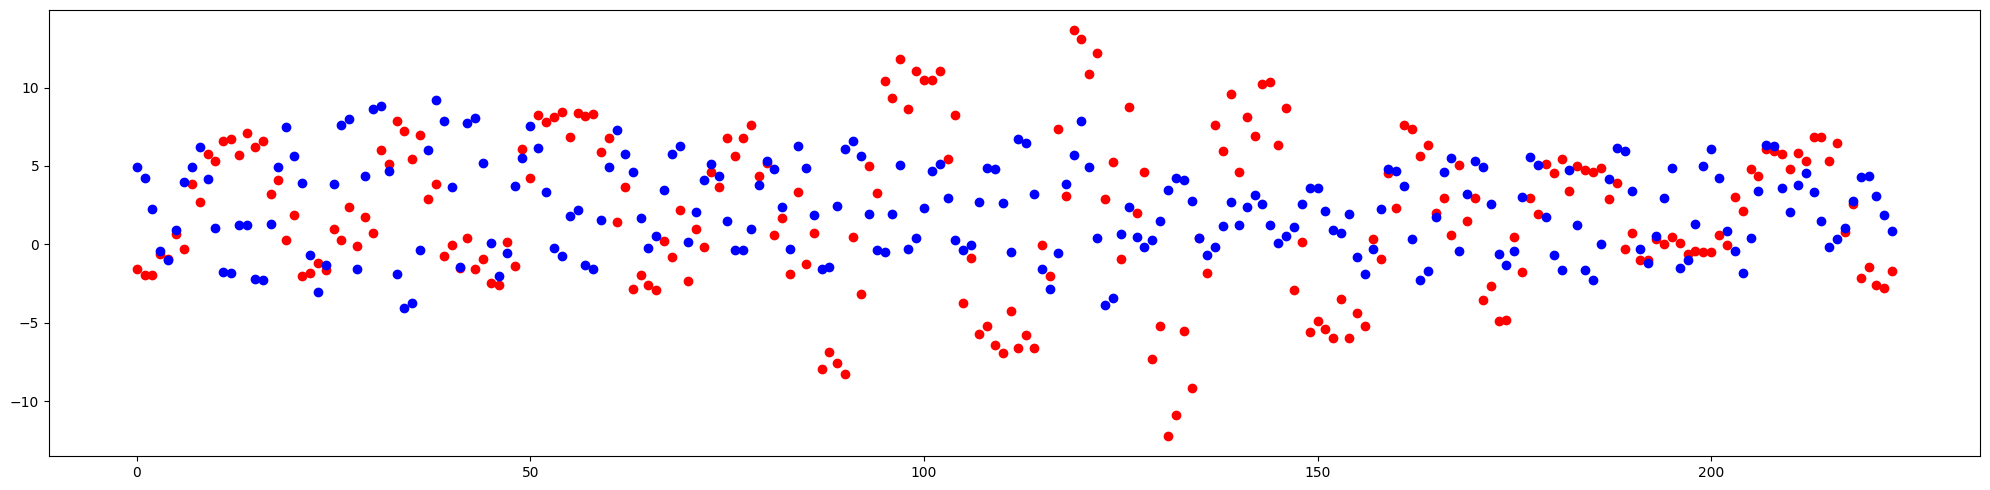

5.35
3.70


In [16]:
# Compare with model

_, bx, _, by = model.out_cs[model.monitor_index].T

plt.figure(figsize=(20, 5))
plt.scatter(range(model.monitor_count), 100*(((model.bx[model.monitor_index] - bx)/model.bx[model.monitor_index])).cpu().numpy(), color='red')
plt.scatter(range(model.monitor_count), 100*(((model.by[model.monitor_index] - by)/model.by[model.monitor_index])).cpu().numpy(), color='blue')
plt.tight_layout()
plt.show()

print(f'{100*root_mean_square((model.bx[model.monitor_index] - bx)/model.bx[model.monitor_index]).item():.2f}')
print(f'{100*root_mean_square((model.by[model.monitor_index] - by)/model.by[model.monitor_index]).item():.2f}')

In [17]:
# Set calibration errors

g_xx = 1.0 + 5.0E-2*torch.randn(model.monitor_count, dtype=dtype, device=device)
g_xy = 0.0 + 2.5E-3*torch.randn(model.monitor_count, dtype=dtype, device=device)
g_yx = 0.0 + 2.5E-3*torch.randn(model.monitor_count, dtype=dtype, device=device)
g_yy = 1.0 + 5.0E-2*torch.randn(model.monitor_count, dtype=dtype, device=device)

In [18]:
# Compute calibration matrices ((gxx, gxy), (gyx, gyy)) for each bpm (qx, px, qy, py)

bpm = torch.vmap(calibration)(g_xx, g_xy, g_yx, g_yy)

In [19]:
# Compute transformed twiss parameters

normal = model.out_normal[model.monitor_index]

n11 = normal[:, 0, 0]
n12 = normal[:, 0, 1]
n13 = normal[:, 0, 2]
n14 = normal[:, 0, 3]

n21 = normal[:, 1, 0]
n22 = normal[:, 1, 1]
n23 = normal[:, 1, 2]
n24 = normal[:, 1, 3]

n31 = normal[:, 2, 0]
n32 = normal[:, 2, 1]
n33 = normal[:, 2, 2]
n34 = normal[:, 2, 3]

n41 = normal[:, 3, 0]
n42 = normal[:, 3, 1]
n43 = normal[:, 3, 2]
n44 = normal[:, 3, 3]

advance_bpm, normal_bpm = torch.vmap(advance)(normal, bpm)

mux_bpm, muy_bpm = mod(-advance_bpm  + torch.stack([mux, muy]).T + advance_bpm.roll(-1, 0), 2*numpy.pi).T

n11_bpm = normal_bpm[:, 0, 0]
n12_bpm = normal_bpm[:, 0, 1]
n13_bpm = normal_bpm[:, 0, 2]
n14_bpm = normal_bpm[:, 0, 3]

n21_bpm = normal_bpm[:, 1, 0]
n22_bpm = normal_bpm[:, 1, 1]
n23_bpm = normal_bpm[:, 1, 2]
n24_bpm = normal_bpm[:, 1, 3]

n31_bpm = normal_bpm[:, 2, 0]
n32_bpm = normal_bpm[:, 2, 1]
n33_bpm = normal_bpm[:, 2, 2]
n34_bpm = normal_bpm[:, 2, 3]

n41_bpm = normal_bpm[:, 3, 0]
n42_bpm = normal_bpm[:, 3, 1]
n43_bpm = normal_bpm[:, 3, 2]
n44_bpm = normal_bpm[:, 3, 3]

In [20]:
# Beta beating

_, bx_bpm, _, by_bpm = torch.stack([wolski_to_cs(matrix) for matrix in normal_to_wolski(normal_bpm)]).T

print(f'{100*root_mean_square((model.bx[model.monitor_index] - bx)/model.bx[model.monitor_index]).item():.2f}')
print(f'{100*root_mean_square((model.by[model.monitor_index] - by)/model.by[model.monitor_index]).item():.2f}')
print()

print(f'{100*root_mean_square((model.bx[model.monitor_index] - bx_bpm)/model.bx[model.monitor_index]).item():.2f}')
print(f'{100*root_mean_square((model.by[model.monitor_index] - by_bpm)/model.by[model.monitor_index]).item():.2f}')
print()

5.35
3.70

10.38
10.66



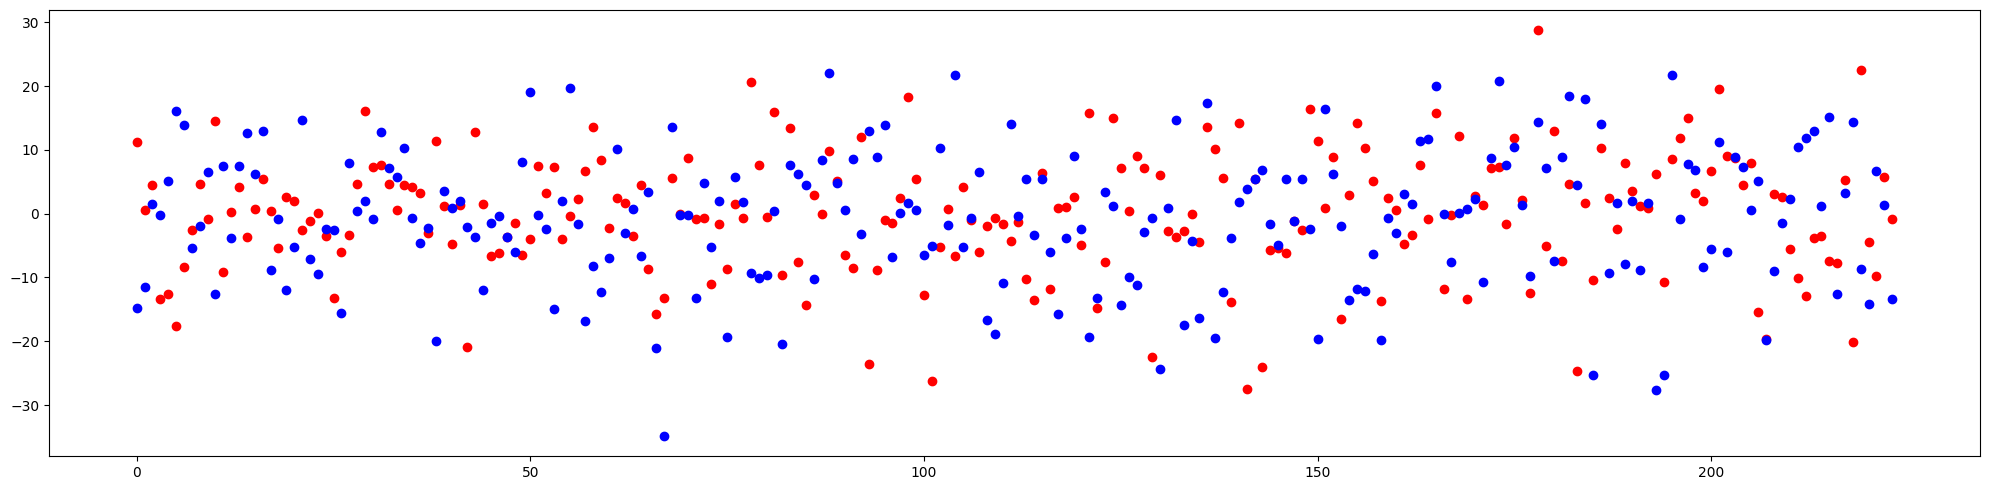

In [21]:
# Plot beta difference

plt.figure(figsize=(20, 5))
plt.scatter(range(model.monitor_count), 100*((bx - bx_bpm)/bx).cpu().numpy(), color='red')
plt.scatter(range(model.monitor_count), 100*((by - by_bpm)/by).cpu().numpy(), color='blue')
plt.tight_layout()
plt.show()

## Harmonic decomposition

In [22]:
# Generate TbT signals at monitors (beam frame)

point = torch.tensor([0.00075, 0.0, 0.000375, 0.0], dtype=dtype, device=device)
qx, px, qy, py =  model.make_trajectory(point, length, error=True, transport=True)[model.monitor_index].permute(-1, 0, 1)

print(qx.shape)
print(px.shape)
print(qy.shape)
print(py.shape)

torch.Size([224, 2048])
torch.Size([224, 2048])
torch.Size([224, 2048])
torch.Size([224, 2048])


In [23]:
# Generate TbT signals at monitors (bpm frame)

qx_bpm, px_bpm, qy_bpm, py_bpm = (bpm @ torch.stack([qx, px, qy, py]).permute(1, 0, -1)).permute(1, 0, -1)

print(qx_bpm.shape)
print(px_bpm.shape)
print(qy_bpm.shape)
print(py_bpm.shape)

torch.Size([224, 2048])
torch.Size([224, 2048])
torch.Size([224, 2048])
torch.Size([224, 2048])


In [24]:
# Compare invariants

ix, iy = torch.vmap(invariant)(normal, torch.stack([qx, px, qy, py]).permute(1, -1, 0)).swapaxes(0, 1).mean(-1)
ix_bpm, iy_bpm = torch.vmap(invariant)(normal_bpm, torch.stack([qx_bpm, px_bpm, qy_bpm, py_bpm]).permute(1, -1, 0)).swapaxes(0, 1).mean(-1)

print(torch.allclose(ix, ix_bpm))
print(torch.allclose(iy, iy_bpm))

True
True


In [25]:
# Perform harmonic decmposition of TbT data without calibration errors

In [26]:
# Set data containers

tbt_x.data = qx.clone()
tbt_x.work = qx.clone()
tbt_x.reset()

tbt_y.data = qy.clone()
tbt_y.work = qy.clone()
tbt_y.reset()

In [27]:
# Compute frequencies (horizontal and vertical)

tbt_x.window_remove_mean()
tbt_x.window_apply()
f_x('parabola')
tbt_x.reset()

tbt_y.window_remove_mean()
tbt_y.window_apply()
f_y('parabola')
tbt_y.reset()

nux, sigma_nux = 1.0 - f_x.frequency.mean(),  f_x.frequency.std()
nuy, sigma_nuy = 1.0 - f_y.frequency.mean(),  f_y.frequency.std()

In [28]:
# Compute amplitudes and phases (horizontal and vertical)

axx, _, _ = d_x.harmonic_amplitude(nux, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fxx, _, _ = d_x.harmonic_phase(nux, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
axy, _, _ = d_x.harmonic_amplitude(nuy, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fxy, _, _ = d_x.harmonic_phase(nuy, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
ayy, _, _ = d_y.harmonic_amplitude(nuy, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fyy, _, _ = d_y.harmonic_phase(nuy, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
ayx, _, _ = d_y.harmonic_amplitude(nux, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fyx, _, _ = d_y.harmonic_phase(nux, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)

In [29]:
# Check reconstruction

# qx(n) = axx cos(2 pi nux n + fxx) + axy cos(2 pi nuy n + fxy)
# qy(n) = ayy cos(2 pi nuy n + fyy) + ayx cos(2 pi nux n + fyx)

t = torch.linspace(0, length - 1, length, dtype=dtype, device=device)

print(torch.allclose(qx, axx.reshape(-1, 1)*(2*torch.pi*nux*t + fxx.reshape(-1, 1)).cos() + axy.reshape(-1, 1)*(2*torch.pi*nuy*t + fxy.reshape(-1, 1)).cos()))
print(torch.allclose(qy, ayy.reshape(-1, 1)*(2*torch.pi*nuy*t + fyy.reshape(-1, 1)).cos() + ayx.reshape(-1, 1)*(2*torch.pi*nux*t + fyx.reshape(-1, 1)).cos()))

True
True


In [30]:
# Set table

table = Table(model.monitor_name,
              nux, nuy,
              axx, ayy, fxx, fyy,
              x=qx,
              y=qy,
              dtype=dtype,
              device=device)

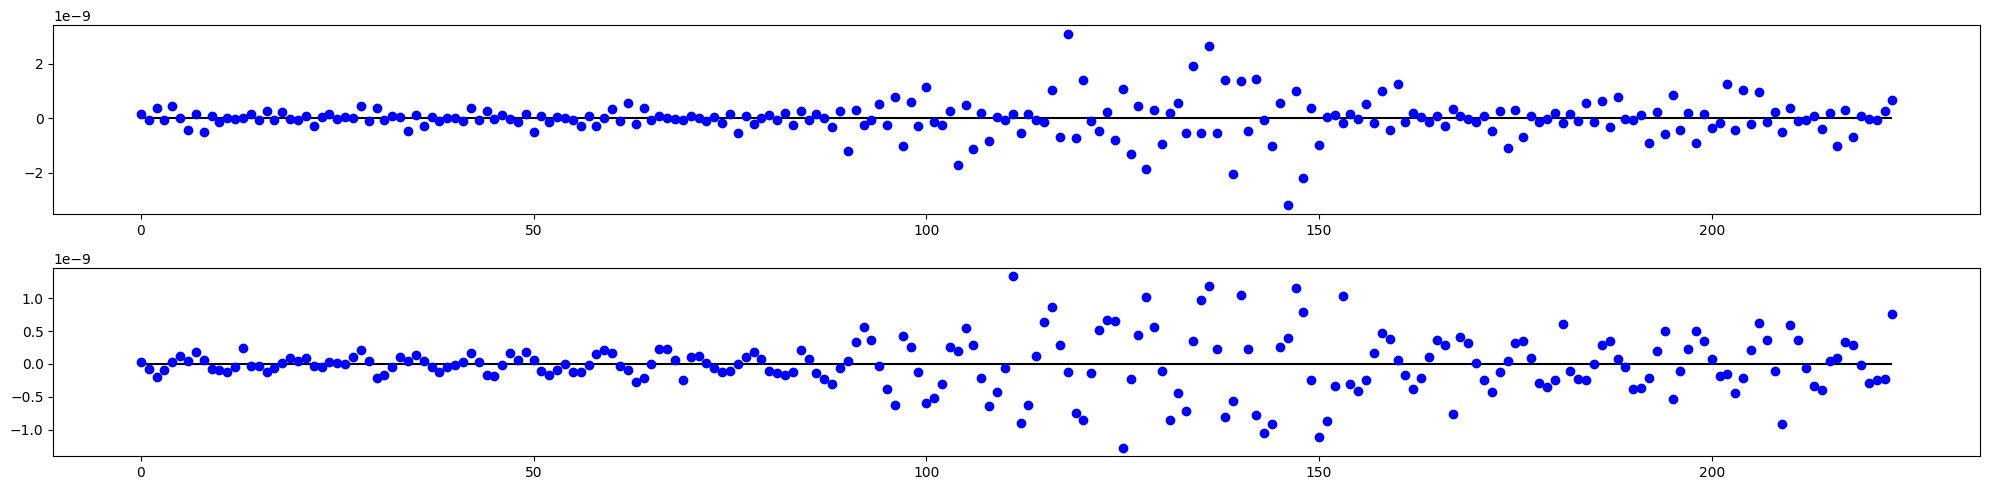

In [31]:
# Compare phase advance

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (mux - table.phase_x.cpu().numpy()), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (muy - table.phase_y.cpu().numpy()), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
plt.tight_layout()
plt.show()

In [32]:
# Perform harmonic decmposition of TbT data wit calibration errors

In [33]:
# Set data containers

tbt_x.data = qx_bpm.clone()
tbt_x.work = qx_bpm.clone()
tbt_x.reset()

tbt_y.data = qy_bpm.clone()
tbt_y.work = qy_bpm.clone()
tbt_y.reset()

In [34]:
# Compute frequencies (horizontal and vertical)

tbt_x.window_remove_mean()
tbt_x.window_apply()
f_x('parabola')
tbt_x.reset()

tbt_y.window_remove_mean()
tbt_y.window_apply()
f_y('parabola')
tbt_y.reset()

nux_bpm, sigma_nux = 1.0 - f_x.frequency.mean(),  f_x.frequency.std()
nuy_bpm, sigma_nuy = 1.0 - f_y.frequency.mean(),  f_y.frequency.std()

print(torch.allclose(nux, nux_bpm))
print(torch.allclose(nuy, nuy_bpm))

True
True


In [35]:
# Compute amplitudes and phases (horizontal and vertical)

axx_bpm, sigma_ax, _ = d_x.harmonic_amplitude(nux_bpm, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fxx_bpm, sigma_fx, _ = d_x.harmonic_phase(nux_bpm, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
axy_bpm, _, _ = d_x.harmonic_amplitude(nuy_bpm, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fxy_bpm, _, _ = d_x.harmonic_phase(nuy_bpm, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
ayy_bpm, sigma_ay, _ = d_y.harmonic_amplitude(nuy_bpm, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fyy_bpm, sigma_fy, _ = d_y.harmonic_phase(nuy_bpm, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
ayx_bpm, _, _ = d_y.harmonic_amplitude(nux_bpm, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fyx_bpm, _, _ = d_y.harmonic_phase(nux_bpm, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)

In [36]:
# Check reconstruction

# qx(n) = axx cos(2 pi nux n + fxx) + axy cos(2 pi nuy n + fxy)
# qy(n) = ayy cos(2 pi nuy n + fyy) + ayx cos(2 pi nux n + fyx)

t = torch.linspace(0, length - 1, length, dtype=dtype, device=device)

print(torch.allclose(qx_bpm, axx_bpm.reshape(-1, 1)*(2*torch.pi*nux_bpm*t + fxx_bpm.reshape(-1, 1)).cos() + axy_bpm.reshape(-1, 1)*(2*torch.pi*nuy_bpm*t + fxy_bpm.reshape(-1, 1)).cos()))
print(torch.allclose(qy_bpm, ayy_bpm.reshape(-1, 1)*(2*torch.pi*nuy_bpm*t + fyy_bpm.reshape(-1, 1)).cos() + ayx_bpm.reshape(-1, 1)*(2*torch.pi*nux_bpm*t + fyx_bpm.reshape(-1, 1)).cos()))

True
True


In [37]:
# Set table

table_bpm = Table(model.monitor_name,
                  nux_bpm, nuy_bpm,
                  axx_bpm, ayy_bpm, fxx_bpm, fyy_bpm, 
                  sigma_nux, sigma_nuy,
                  sigma_ax, sigma_ay,
                  sigma_fx, sigma_fy,
                  x=qx_bpm,
                  y=qy_bpm,
                  dtype=dtype,
                  device=device)

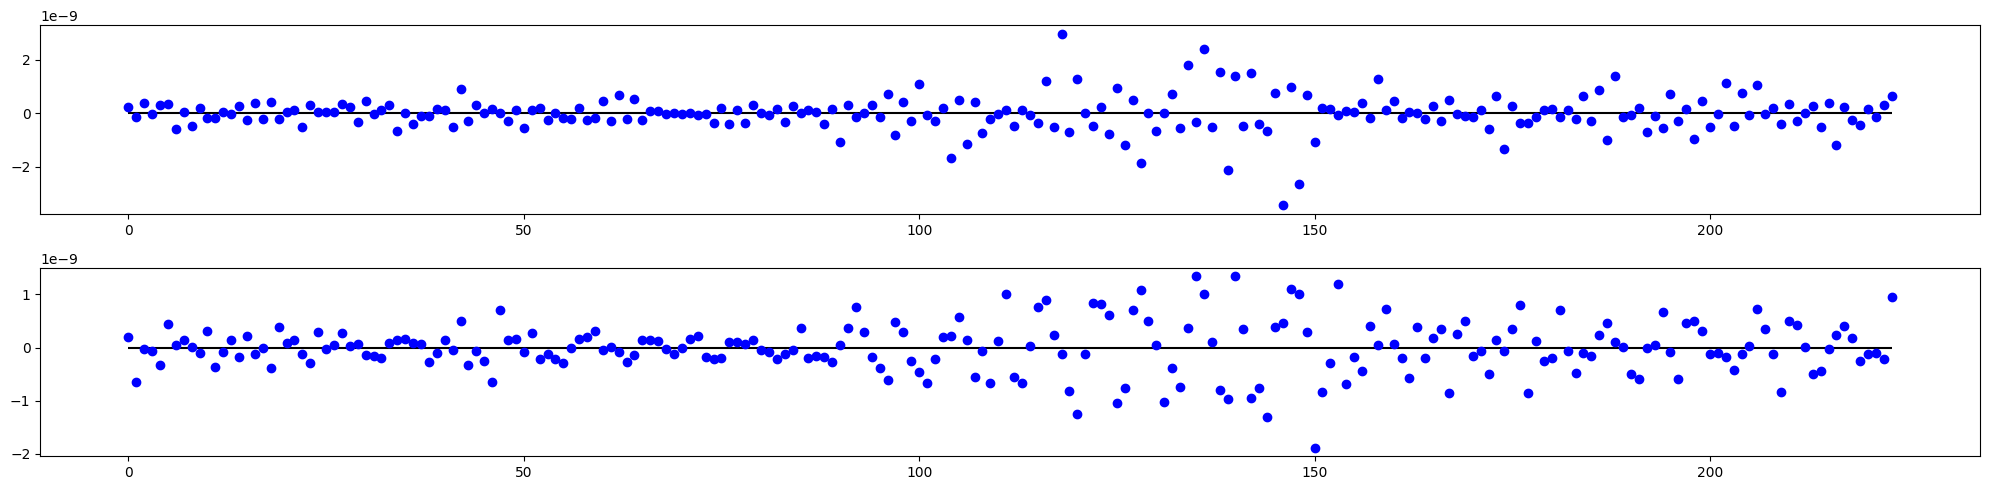

In [38]:
# Compare phase advance

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (mux_bpm - table_bpm.phase_x.cpu().numpy()), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (muy_bpm - table_bpm.phase_y.cpu().numpy()), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
plt.tight_layout()
plt.show()

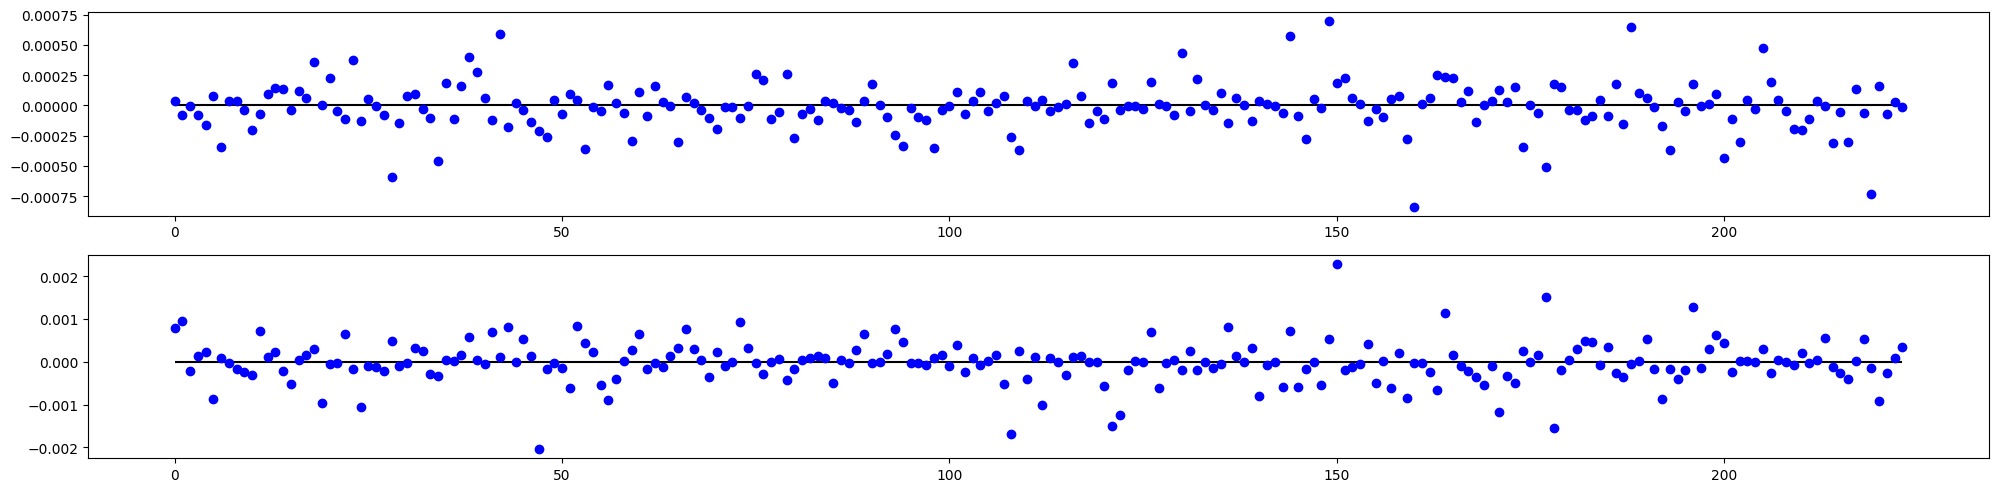

In [39]:
# Compare phases without calibration errors vs with calibration errors
# Note, without bpm rolls, phases are equal

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (fxx - fxx_bpm).cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (fyy - fyy_bpm).cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
plt.tight_layout()
plt.show()

## Twiss from amplitude & phase

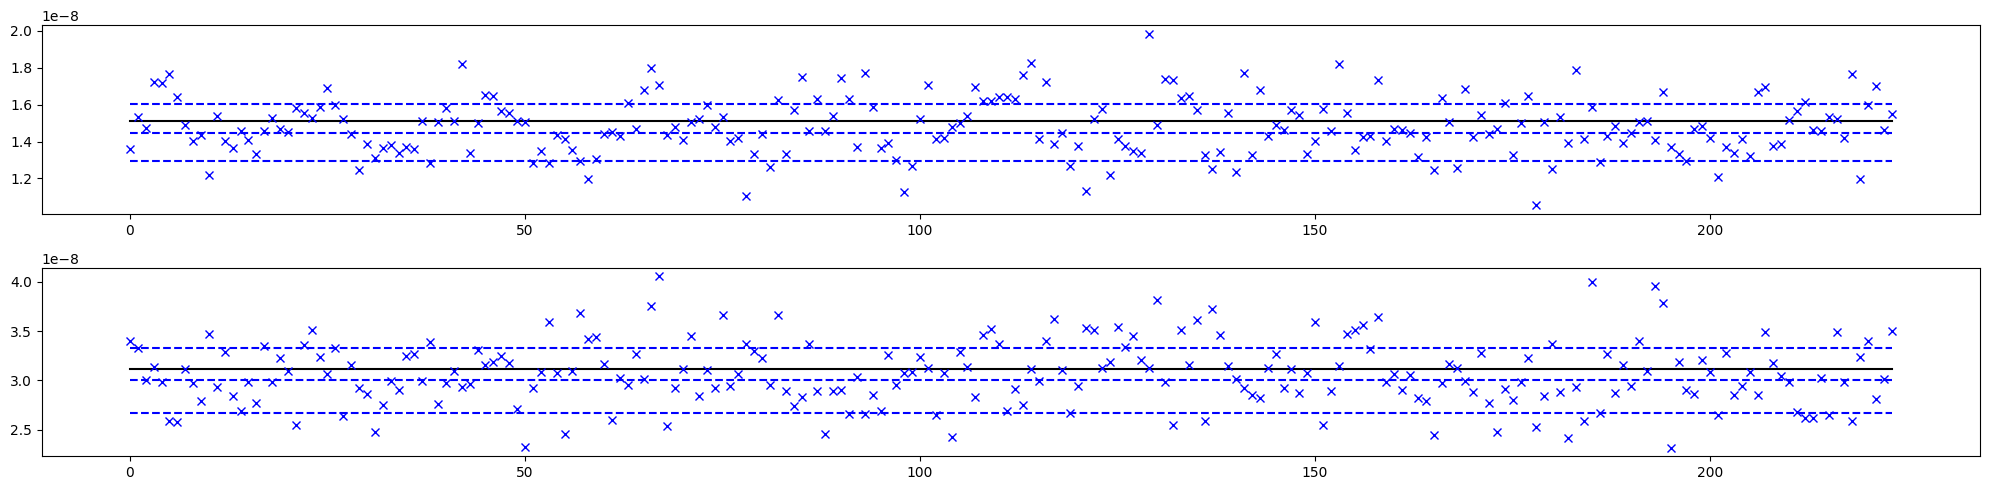

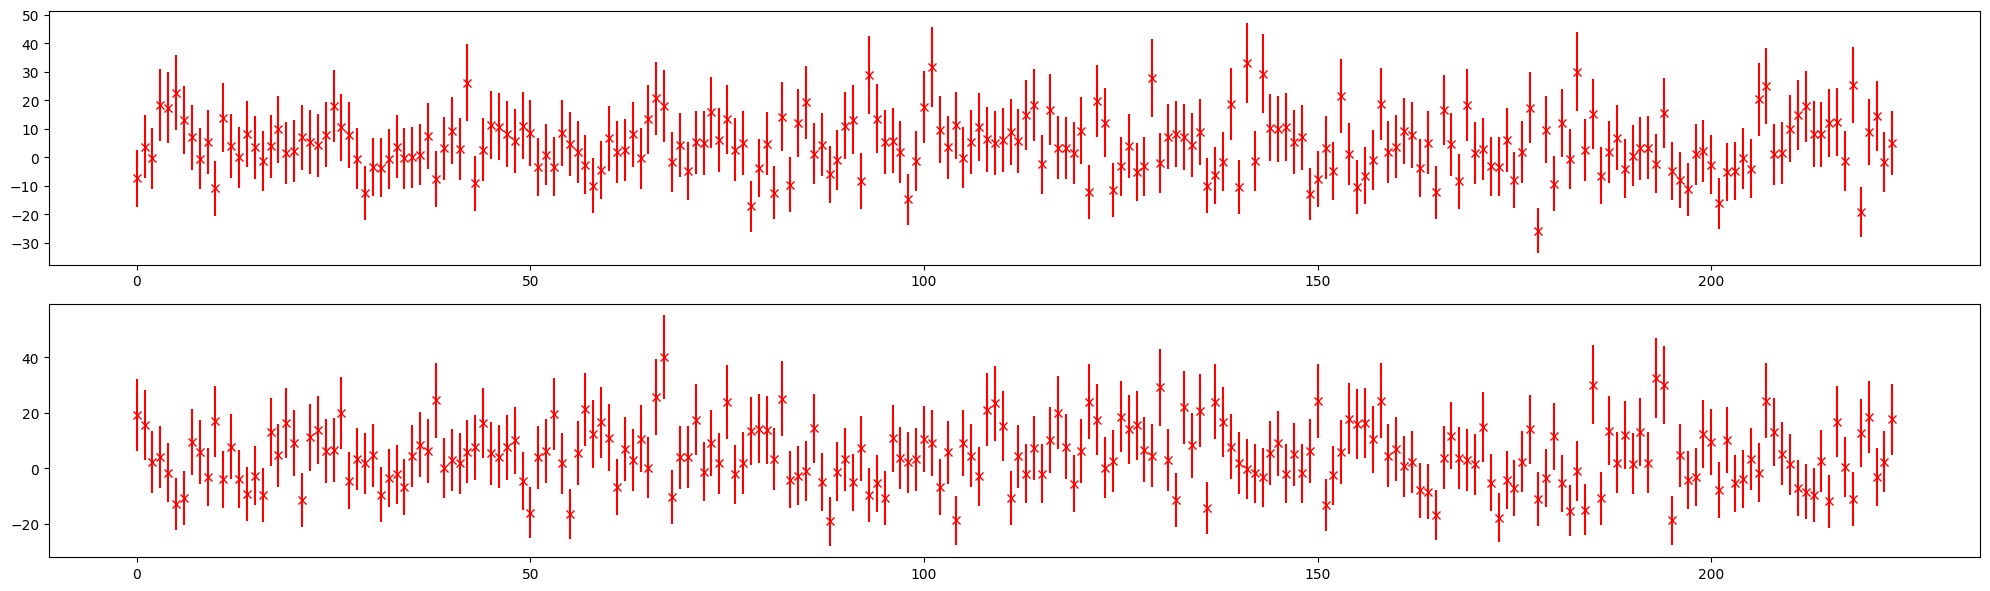

tensor(10.8248, dtype=torch.float64)
tensor(11.8844, dtype=torch.float64)



In [40]:
# Estimate twiss from amplitude (model beta functions are used to estimate invariants)

twiss = Twiss(model, table_bpm, limit=1)
twiss.get_action()
twiss.get_twiss_from_amplitude()

# Compare estimated invariants

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), ix.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jx'].cpu().numpy(), yerr=twiss.action['sigma_jx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jx'] - twiss.action['spread_jx']).cpu().numpy(), twiss.action['center_jx'].cpu().numpy(), (twiss.action['center_jx'] + twiss.action['spread_jx']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), iy.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jy'].cpu().numpy(), yerr=twiss.action['sigma_jy'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jy'] - twiss.action['spread_jy']).cpu().numpy(), twiss.action['center_jy'].cpu().numpy(), (twiss.action['center_jy'] + twiss.action['spread_jy']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
plt.tight_layout()
plt.show()

# Compare estimated twiss

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by)/by).cpu().numpy(), yerr=100/by*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx)/bx)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by)/by)))
print()

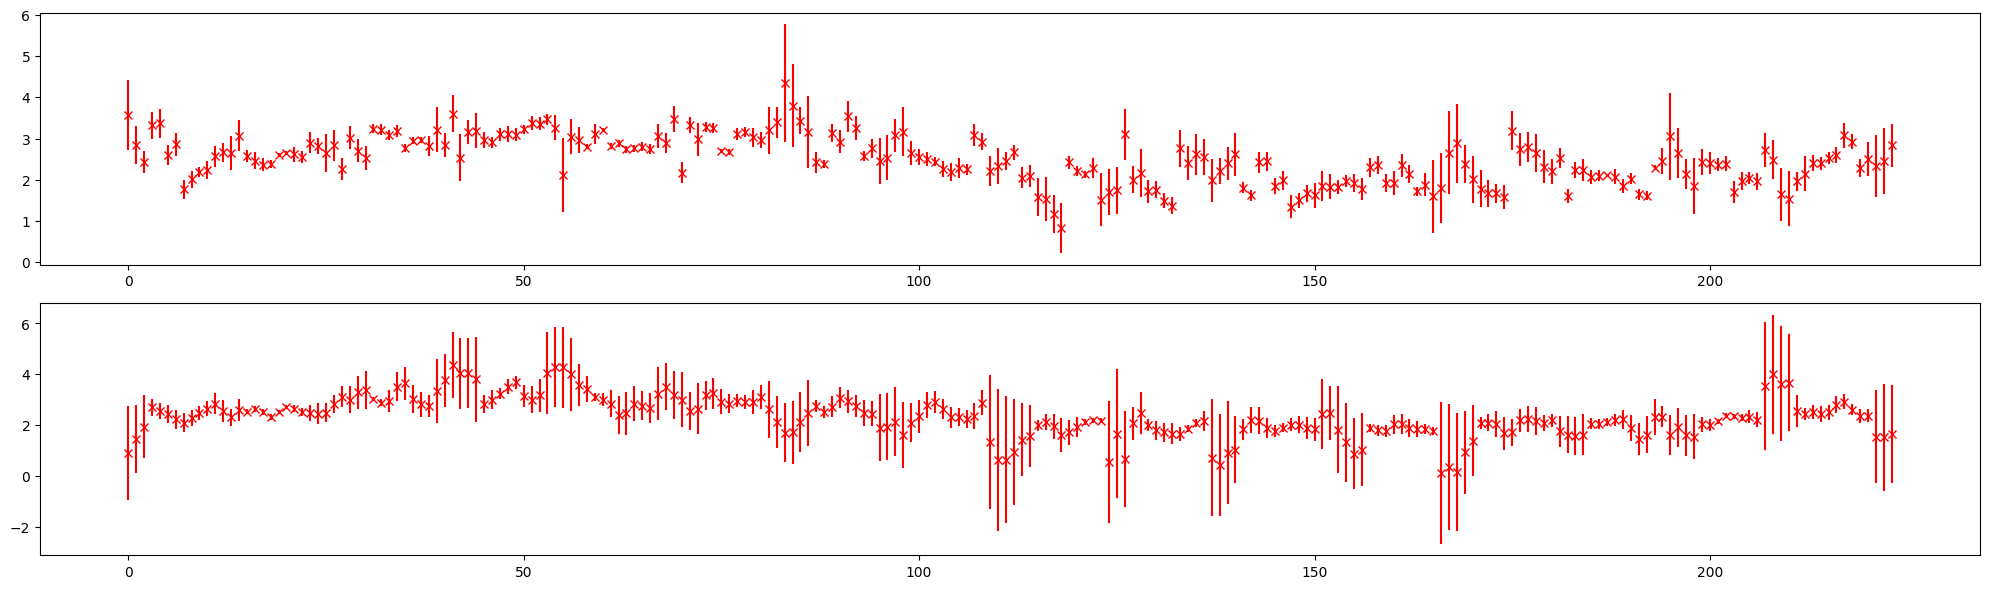

tensor(2.5559, dtype=torch.float64)
tensor(2.4604, dtype=torch.float64)



In [41]:
# Estimate twiss from phase

twiss = Twiss(model, table_bpm, limit=4)
twiss.phase_virtual()
twiss.get_twiss_from_phase()
mask_x = twiss.filter_twiss(plane='x', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
mask_y = twiss.filter_twiss(plane='y', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
_ = twiss.process_twiss(plane='x', mask=mask_x, weight=True)
_ = twiss.process_twiss(plane='y', mask=mask_y, weight=True)

# Compare estimated twiss

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.bx[model.monitor_index] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.sigma_bx[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.by[model.monitor_index] - by)/by).cpu().numpy(), yerr=100/by*twiss.sigma_by[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((twiss.bx[model.monitor_index] - bx)/bx)))
print(root_mean_square(100*((twiss.by[model.monitor_index] - by)/by)))
print()

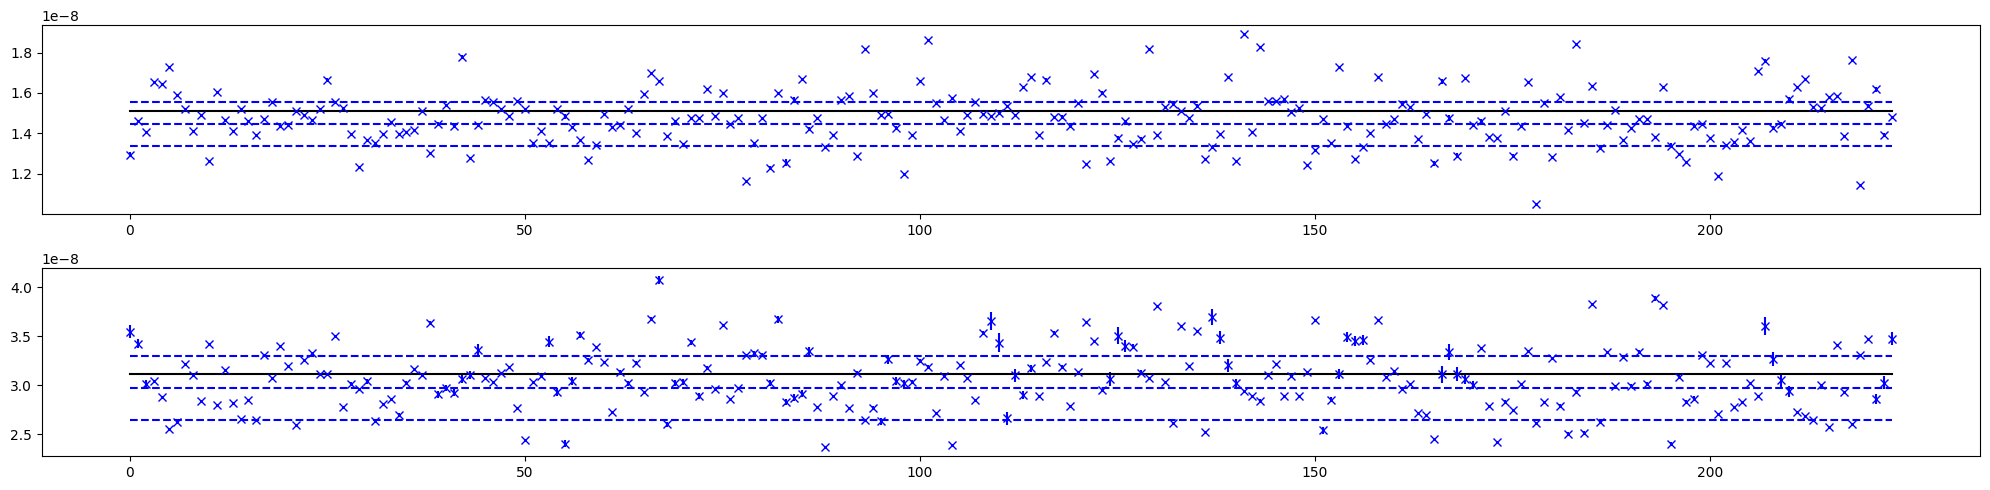

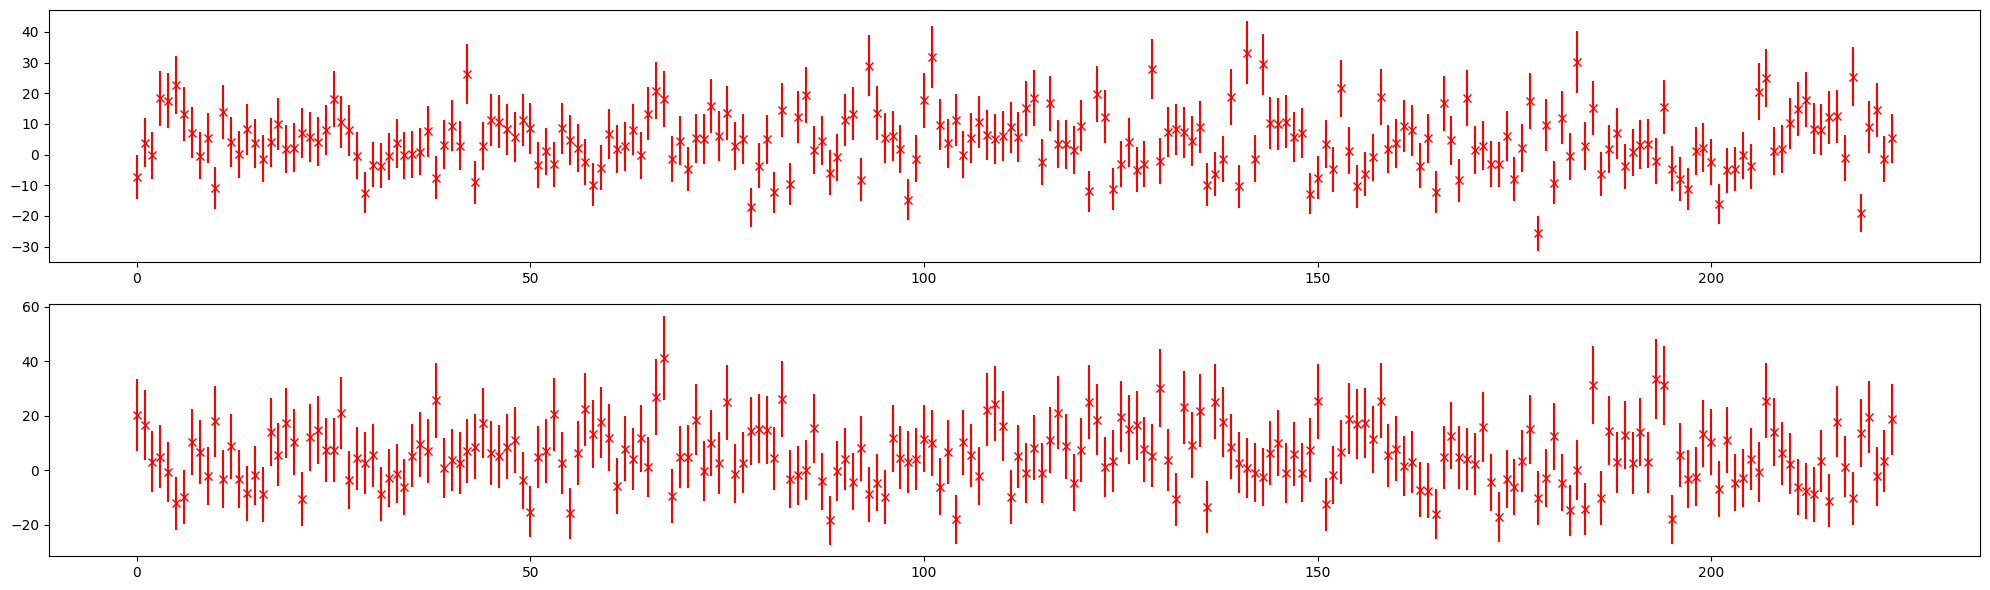

tensor(10.8725, dtype=torch.float64)
tensor(12.3708, dtype=torch.float64)



In [42]:
# Estimate twiss from amplitude (use twiss from phase for action estimation)

twiss.get_action(bx=twiss.bx[model.monitor_index], by=twiss.by[model.monitor_index], sigma_bx=twiss.sigma_bx[model.monitor_index], sigma_by=twiss.sigma_by[model.monitor_index])
twiss.get_twiss_from_amplitude()

# Compare estimated invariants

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), ix.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jx'].cpu().numpy(), yerr=twiss.action['sigma_jx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jx'] - twiss.action['spread_jx']).cpu().numpy(), twiss.action['center_jx'].cpu().numpy(), (twiss.action['center_jx'] + twiss.action['spread_jx']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), iy.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jy'].cpu().numpy(), yerr=twiss.action['sigma_jy'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jy'] - twiss.action['spread_jy']).cpu().numpy(), twiss.action['center_jy'].cpu().numpy(), (twiss.action['center_jy'] + twiss.action['spread_jy']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
plt.tight_layout()
plt.show()

# Compare estimated twiss

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by)/by).cpu().numpy(), yerr=100/by*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx)/bx)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by)/by)))
print()

## Calibration scales (phase)

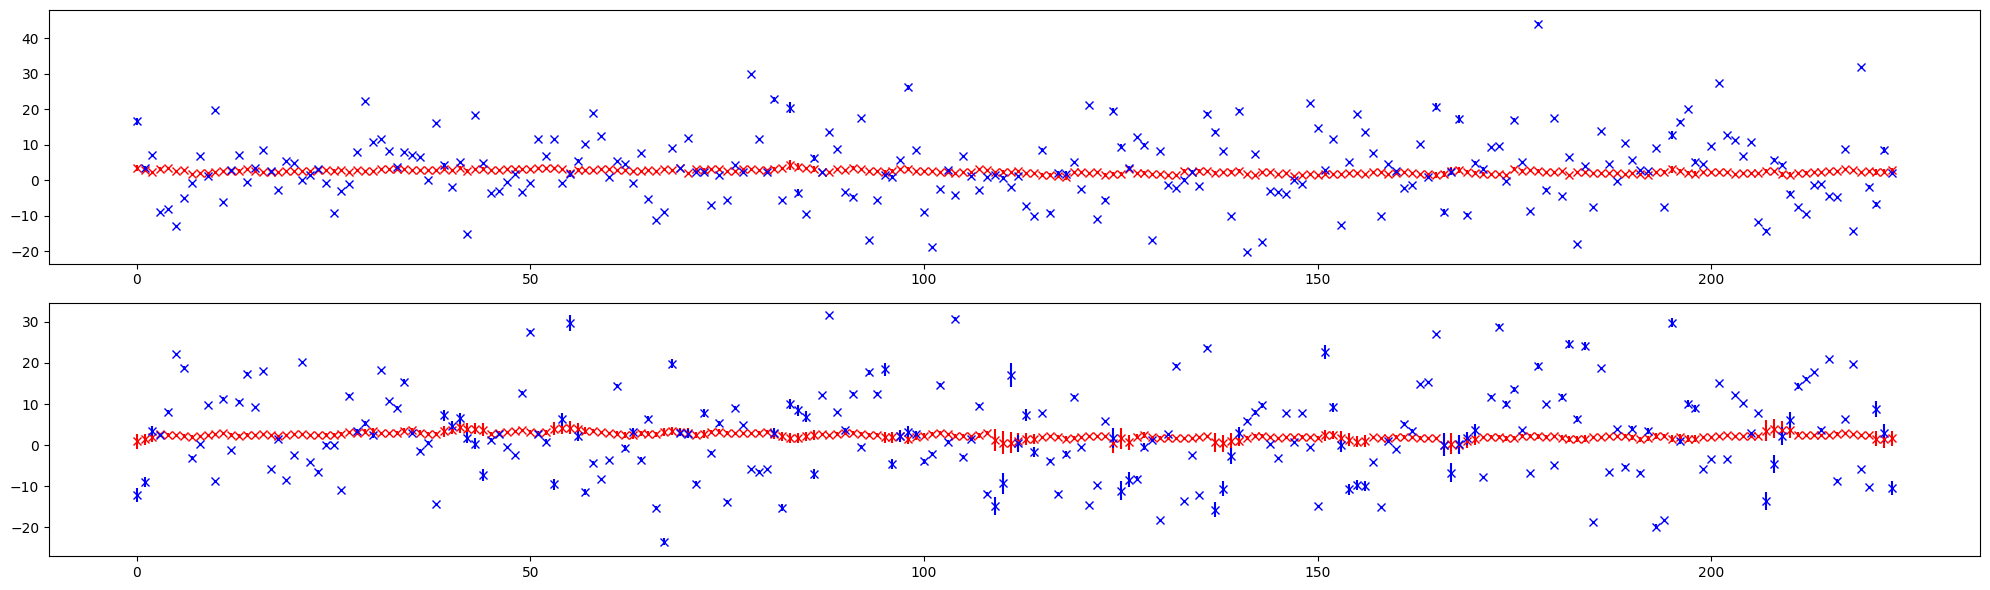

tensor(2.5559, dtype=torch.float64)
tensor(2.4604, dtype=torch.float64)

tensor(10.4127, dtype=torch.float64)
tensor(11.2128, dtype=torch.float64)



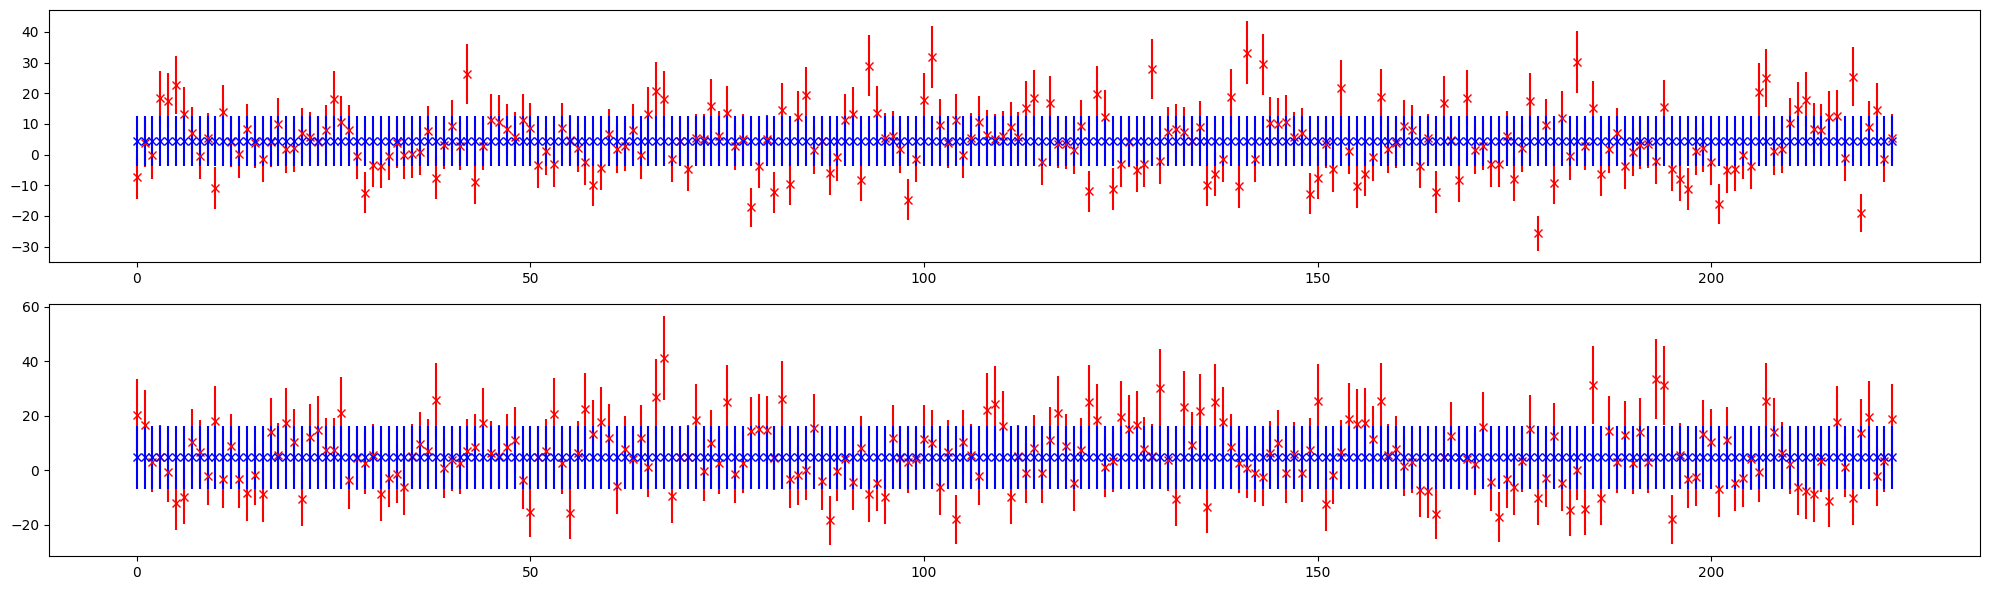

tensor(10.8725, dtype=torch.float64)
tensor(12.3708, dtype=torch.float64)

tensor(4.4306, dtype=torch.float64)
tensor(4.7564, dtype=torch.float64)



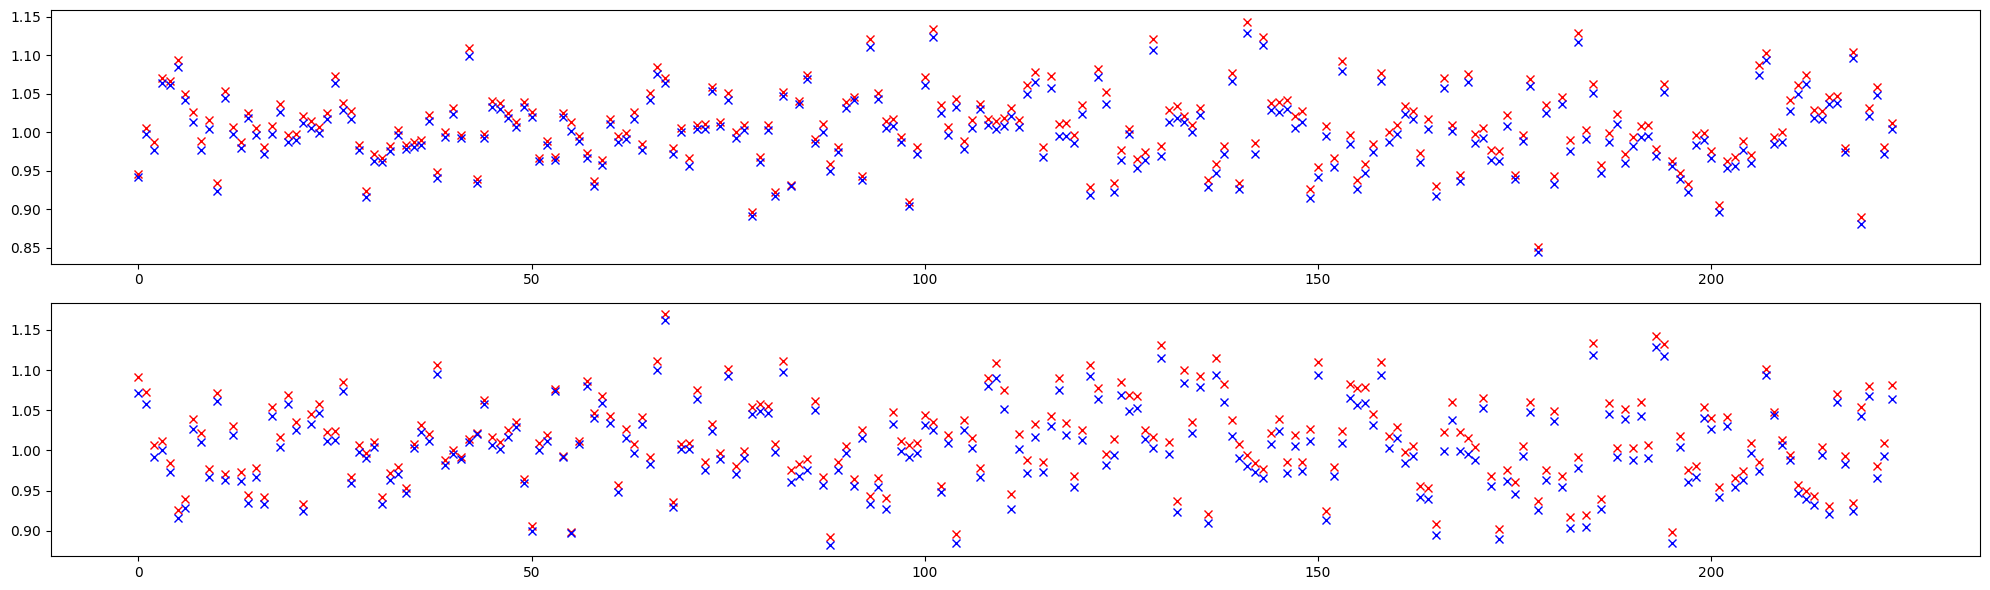

tensor(0.9814, dtype=torch.float64)
tensor(1.2470, dtype=torch.float64)



In [43]:
# Ratio (invariants from phase twiss)

twiss = Twiss(model, table_bpm, limit=4)

twiss.phase_virtual()
twiss.get_twiss_from_phase()
mask_x = twiss.filter_twiss(plane='x', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
mask_y = twiss.filter_twiss(plane='y', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
_ = twiss.process_twiss(plane='x', mask=mask_x, weight=True)
_ = twiss.process_twiss(plane='y', mask=mask_y, weight=True)

twiss.get_action(bx=twiss.bx[model.monitor_index], by=twiss.by[model.monitor_index], sigma_bx=twiss.sigma_bx[model.monitor_index], sigma_by=twiss.sigma_by[model.monitor_index])
twiss.get_twiss_from_amplitude()

# Twiss (phase)

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.bx[model.monitor_index] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.sigma_bx[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.bx[model.monitor_index] - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*twiss.sigma_bx[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.by[model.monitor_index] - by)/by).cpu().numpy(), yerr=100/by*twiss.sigma_by[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.by[model.monitor_index] - by_bpm)/by_bpm).cpu().numpy(), yerr=100/by_bpm*twiss.sigma_by[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()
print(root_mean_square(100*((twiss.bx[model.monitor_index] - bx)/bx)))
print(root_mean_square(100*((twiss.by[model.monitor_index] - by)/by)))
print()
print(root_mean_square(100*((twiss.bx[model.monitor_index] - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((twiss.by[model.monitor_index] - by_bpm)/by_bpm)))
print()

# Twiss (amplitude)

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by)/by).cpu().numpy(), yerr=100/by*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by_bpm)/by_bpm).cpu().numpy(), yerr=100/by_bpm*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()
print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx)/bx)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by)/by)))
print()
print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by_bpm)/by_bpm)))
print()

# Ratio

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['bx']/twiss.bx[model.monitor_index]).sqrt().cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), g_xx.cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['by']/twiss.by[model.monitor_index]).sqrt().cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), g_yy.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

gxx_phase = (twiss.data_amplitude['bx']/twiss.bx[model.monitor_index]).sqrt()
gyy_phase = (twiss.data_amplitude['by']/twiss.by[model.monitor_index]).sqrt()

print(root_mean_square(100*(((twiss.data_amplitude['bx']/twiss.bx[model.monitor_index]).sqrt() - g_xx)/g_xx)))
print(root_mean_square(100*(((twiss.data_amplitude['by']/twiss.by[model.monitor_index]).sqrt() - g_yy)/g_yy)))
print()

## Invariants (scaled TbT)

In [44]:
# Computed full set of coupled Twiss parameters and invariants
# Note, TbT data is rescaled using estimated gxx and gyy with fixed invariants

In [45]:
%%time

# Estimate twiss from invariant fit

count = 8

data = twiss.get_twiss_from_data(1,                # -- first turn
                                 256,              # -- total number of turns, orbits are computed for (start, start + total)
                                 parametric_normal,# -- normalization
                                 model.matrix,     # -- transport matrix generator
                                 twiss=None,       # -- initial twiss for each location or None (use model values)
                                 method='lstsq',   # -- momenta computation method
                                 limit=2,          # -- range limit or direction/shift
                                 product=True,     # -- flag to use product objective
                                 jacobian=False,   # -- flag to use objective jacobian
                                 count=count,      # -- number of samples
                                 fraction=0.75,    # -- sample length fraction
                                 ix=None,          # -- ix invariant value
                                 iy=None,          # -- iy invariant value  (both should present for fixed fit)
                                 n_jobs=6,         # -- number of parallel jobs (loop over samples)
                                 verbose=False)    # -- verbose flag

CPU times: user 8min 22s, sys: 1min 41s, total: 10min 3s
Wall time: 12min 14s


In [46]:
# Process fitted invariants

ix_out = data[:, 0, 0]
iy_out = data[:, 0, 1]

sigma_ix = data[:, 1, 0]
sigma_iy = data[:, 1, 1]

invariant = twiss.get_invariant(ix_out, iy_out, sigma_ix, sigma_iy)

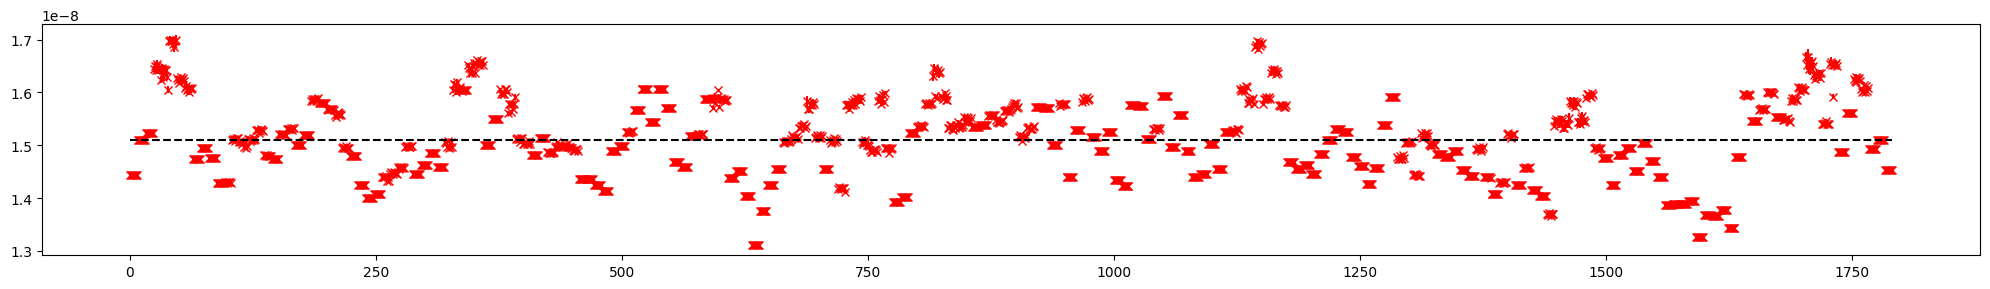

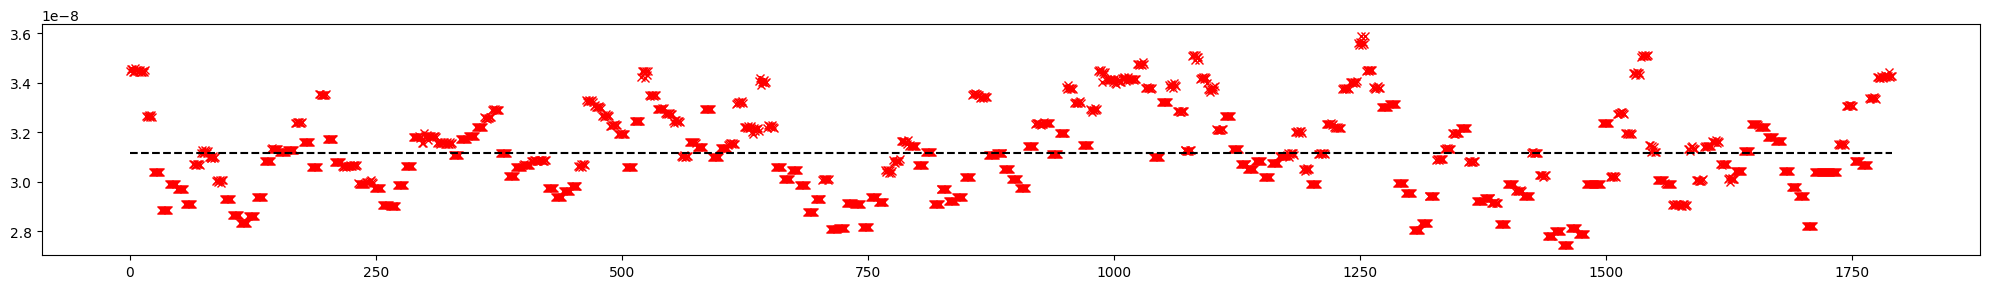

In [47]:
# Plot invariants for each sample in each signal

plt.figure(figsize=(20, 3))
plt.errorbar(range(count*model.monitor_count), ix_out.flatten().cpu().numpy(), yerr=sigma_ix.flatten().cpu().numpy(), fmt=' ', color='red', marker='x', zorder=0)
plt.hlines(ix.mean(), 0, count*model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(count*model.monitor_count), iy_out.flatten().cpu().numpy(), yerr=sigma_iy.flatten().cpu().numpy(), fmt=' ', color='red', marker='x', zorder=0)
plt.hlines(iy.mean(), 0, count*model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.tight_layout()
plt.show()

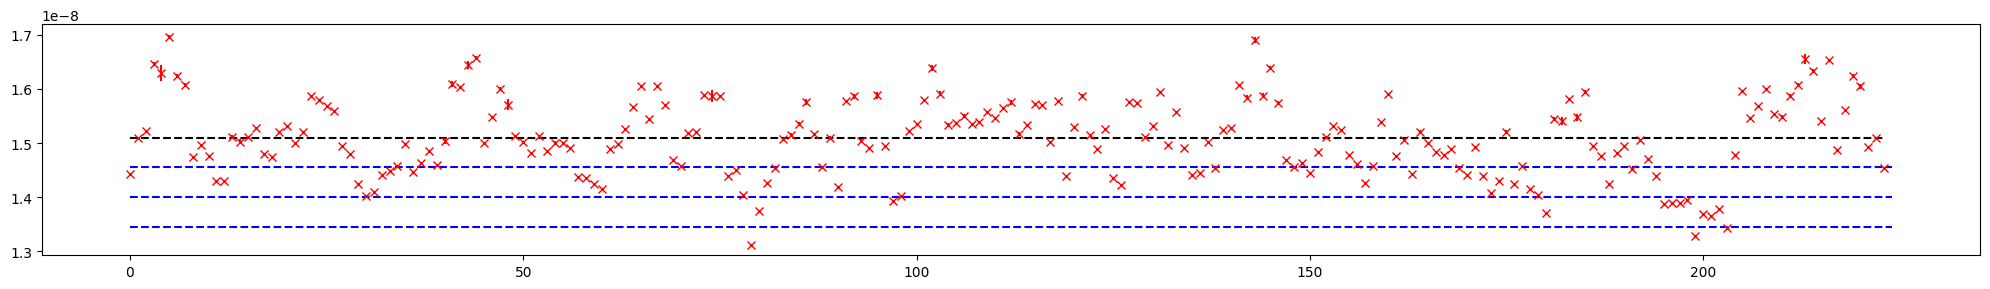

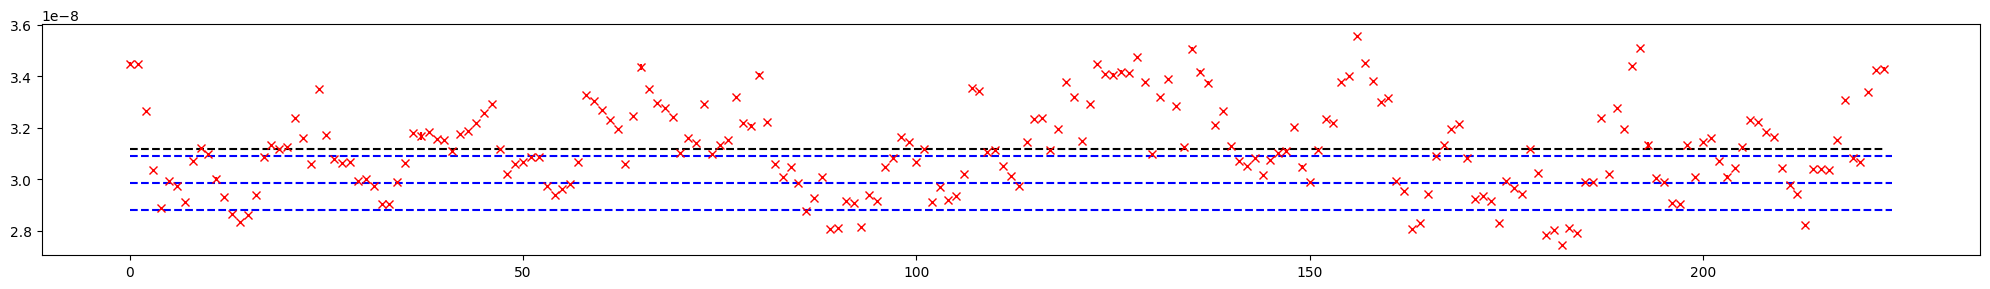

tensor(1.5100e-08, dtype=torch.float64)
tensor(1.4460e-08, dtype=torch.float64)
tensor(1.3997e-08, dtype=torch.float64)
tensor(1.5081e-08, dtype=torch.float64)

tensor(3.1155e-08, dtype=torch.float64)
tensor(2.9741e-08, dtype=torch.float64)
tensor(2.9843e-08, dtype=torch.float64)
tensor(3.1181e-08, dtype=torch.float64)



In [48]:
# Plot invariants for each monitor

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), invariant['ix_center'].flatten().cpu().numpy(), yerr=invariant['ix_spread'].flatten().cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(ix.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([invariant['ix_value'] - invariant['ix_error'], invariant['ix_value'], invariant['ix_value'] + invariant['ix_error']], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), invariant['iy_center'].flatten().cpu().numpy(), yerr=invariant['iy_spread'].flatten().cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(iy.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([invariant['iy_value'] - invariant['iy_error'], invariant['iy_value'], invariant['iy_value'] + invariant['iy_error']], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

print(ix.mean())
print(twiss.action['center_jx'])
print(invariant['ix_value'])
print(ix_out.mean())
print()

print(iy.mean())
print(twiss.action['center_jy'])
print(invariant['iy_value'])
print(iy_out.mean())
print()

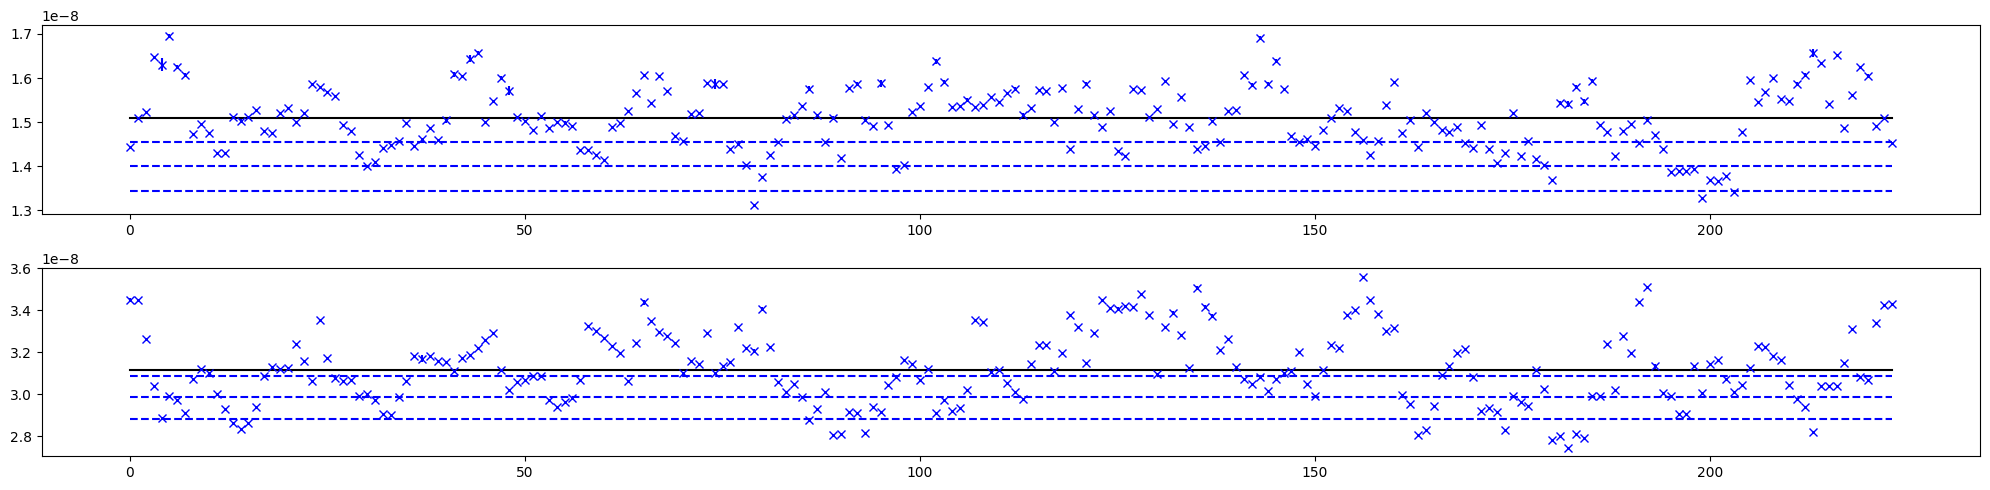

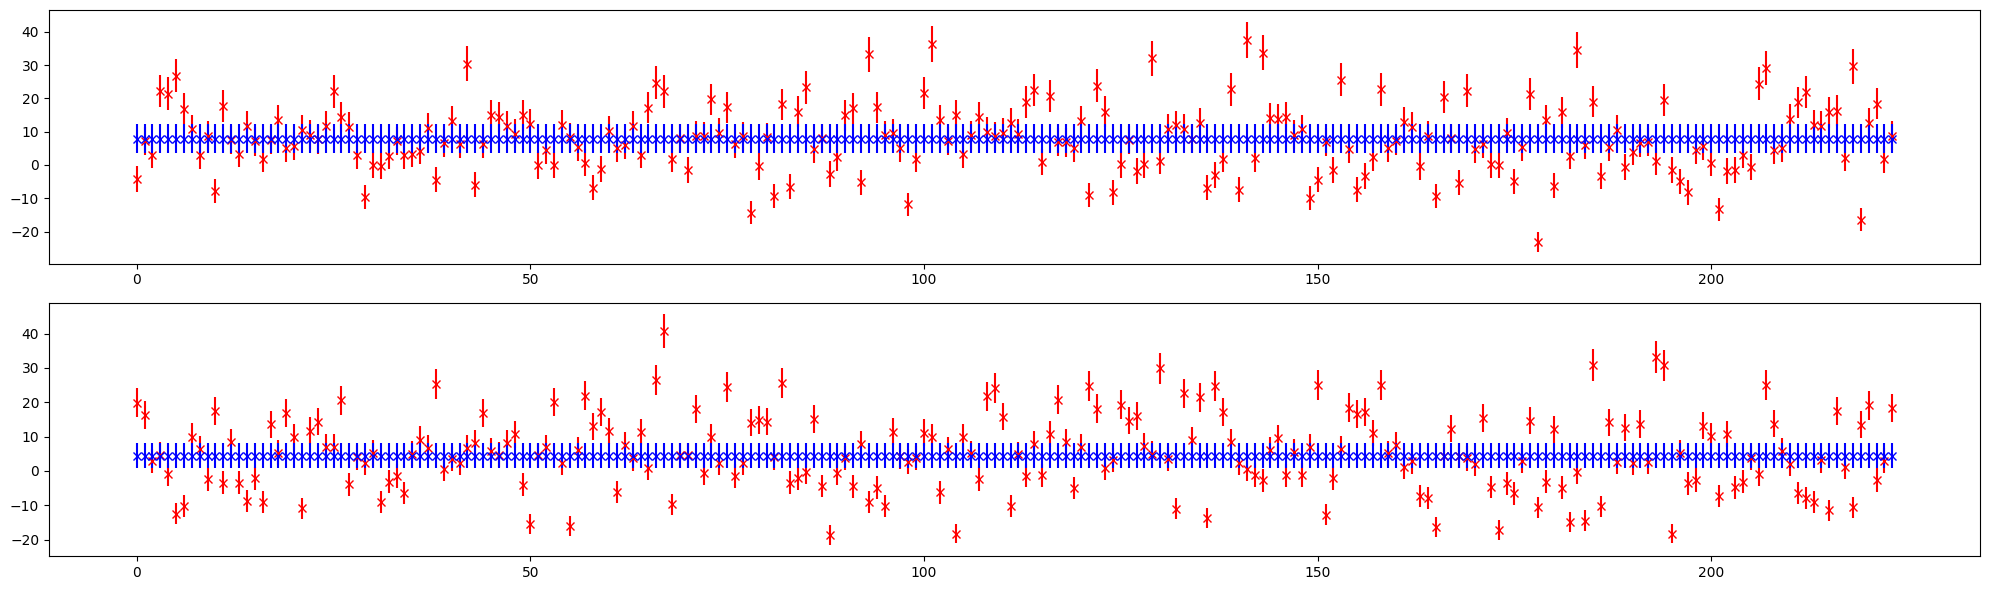

tensor(12.9616, dtype=torch.float64)
tensor(12.1796, dtype=torch.float64)

tensor(7.8799, dtype=torch.float64)
tensor(4.3974, dtype=torch.float64)



In [49]:
# Estimate twiss from amplitude (use fitted invariant)

twiss.get_action(jx=invariant['ix_center'], jy=invariant['iy_center'], sigma_jx=invariant['ix_spread'], sigma_jy=invariant['iy_spread'])
twiss.get_twiss_from_amplitude()

# Compare estimated invariants

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), ix.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jx'].cpu().numpy(), yerr=twiss.action['sigma_jx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jx'] - twiss.action['spread_jx']).cpu().numpy(), twiss.action['center_jx'].cpu().numpy(), (twiss.action['center_jx'] + twiss.action['spread_jx']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), iy.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jy'].cpu().numpy(), yerr=twiss.action['sigma_jy'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jy'] - twiss.action['spread_jy']).cpu().numpy(), twiss.action['center_jy'].cpu().numpy(), (twiss.action['center_jy'] + twiss.action['spread_jy']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
plt.tight_layout()
plt.show()

# Compare estimated twiss

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by)/by).cpu().numpy(), yerr=100/by*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by_bpm)/by_bpm).cpu().numpy(), yerr=100/by_bpm*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx)/bx)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by)/by)))
print()

print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by_bpm)/by_bpm)))
print()

In [50]:
value_n11 = data[:, 0, 2]
error_n11 = data[:, 1, 2]

value_n33 = data[:, 0, 3]
error_n33 = data[:, 1, 3]

value_n21 = data[:, 0, 4]
error_n21 = data[:, 1, 4]

value_n43 = data[:, 0, 5]
error_n43 = data[:, 1, 5]

value_n13 = data[:, 0, 6]
error_n13 = data[:, 1, 6]

value_n31 = data[:, 0, 7]
error_n31 = data[:, 1, 7]

value_n14 = data[:, 0, 8]
error_n14 = data[:, 1, 8]

value_n41 = data[:, 0, 9]
error_n41 = data[:, 1, 9]

value_n11, error_n11 = twiss.process(value_n11, error_n11)
value_n33, error_n33 = twiss.process(value_n33, error_n33)
value_n21, error_n21 = twiss.process(value_n21, error_n21)
value_n43, error_n43 = twiss.process(value_n43, error_n43)
value_n13, error_n13 = twiss.process(value_n13, error_n13)
value_n31, error_n31 = twiss.process(value_n31, error_n31)
value_n14, error_n14 = twiss.process(value_n14, error_n14)
value_n41, error_n41 = twiss.process(value_n41, error_n41)

value = torch.stack([value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41]).T
error = torch.stack([error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41]).T

cs_value, cs_error = [], []

for value_loc, error_loc in zip(value, error):
    table = value_loc.reshape(-1, 1) + error_loc.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax, value_bx, value_ay, value_by = cs_value.T
error_ax, error_bx, error_ay, error_by = cs_error.T

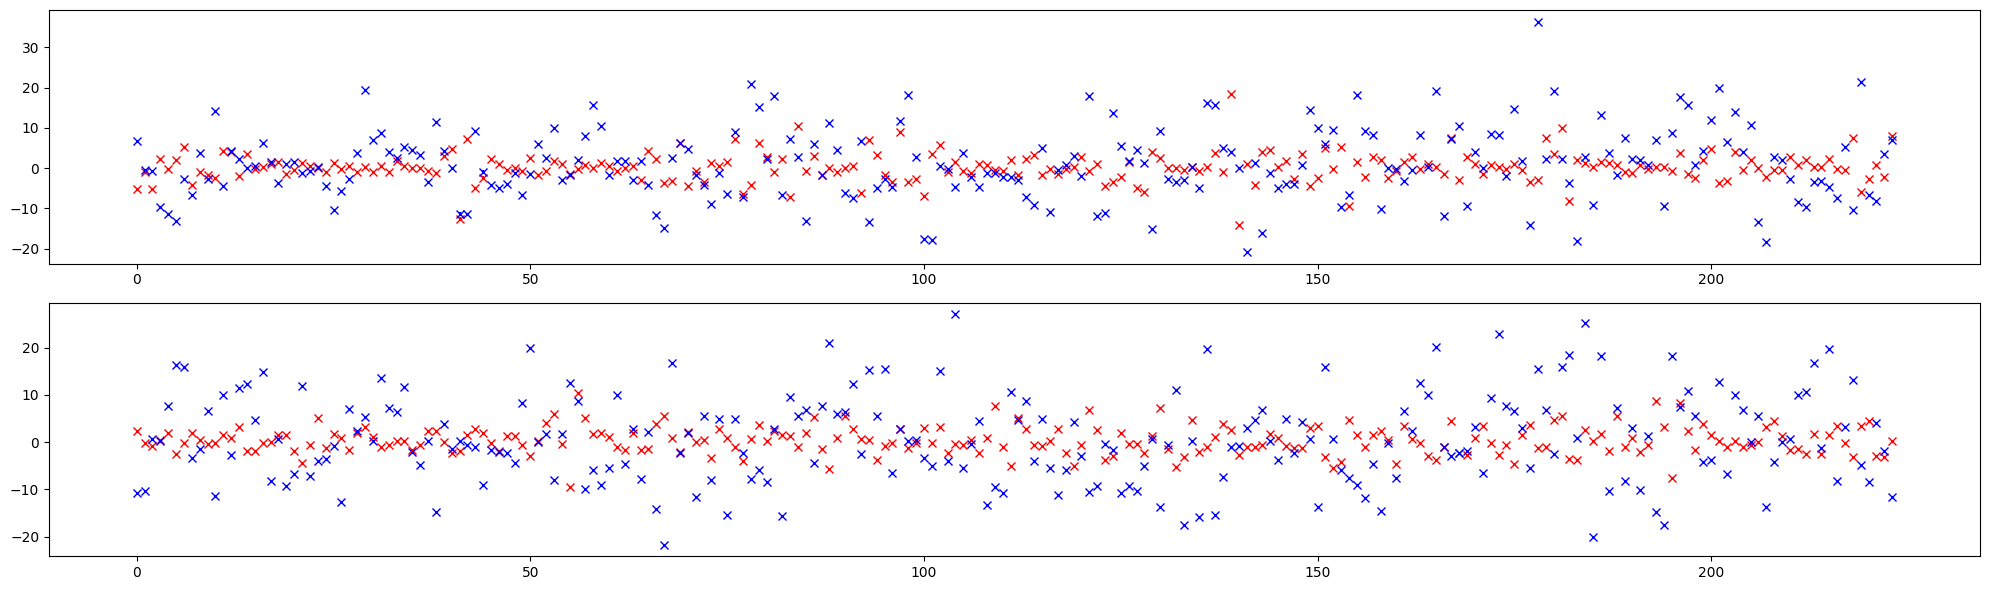

tensor(3.6007, dtype=torch.float64)
tensor(2.9238, dtype=torch.float64)

tensor(8.8403, dtype=torch.float64)
tensor(9.4574, dtype=torch.float64)



In [51]:
# Compare beta function values

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((value_bx - bx)/bx).cpu().numpy(), yerr=100/bx*error_bx.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((value_bx - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*error_bx.cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((value_by - by)/by).cpu().numpy(), yerr=100/by*error_by.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((value_by - by_bpm)/by_bpm).cpu().numpy(), yerr=100/by_bpm*error_by.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((value_bx - bx)/bx)))
print(root_mean_square(100*((value_by - by)/by)))
print()

print(root_mean_square(100*((value_bx - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((value_by - by_bpm)/by_bpm)))
print()

# Note, the results seem to be closer to beam frame beta functions
# This might be due to the fact that several bpms are used for momenta estimation (calibratins are mixed)

In [52]:
# Compare estimated normalization matrix elements

tensor(0.0615, dtype=torch.float64)
tensor(0.1299, dtype=torch.float64)

tensor(0.0300, dtype=torch.float64)
tensor(0.0883, dtype=torch.float64)

tensor(0.0312, dtype=torch.float64)
tensor(0.0763, dtype=torch.float64)

tensor(0.0281, dtype=torch.float64)
tensor(0.0618, dtype=torch.float64)

tensor(0.0143, dtype=torch.float64)
tensor(0.0185, dtype=torch.float64)

tensor(0.0105, dtype=torch.float64)
tensor(0.0150, dtype=torch.float64)

tensor(0.0143, dtype=torch.float64)
tensor(0.0191, dtype=torch.float64)

tensor(0.0064, dtype=torch.float64)
tensor(0.0108, dtype=torch.float64)



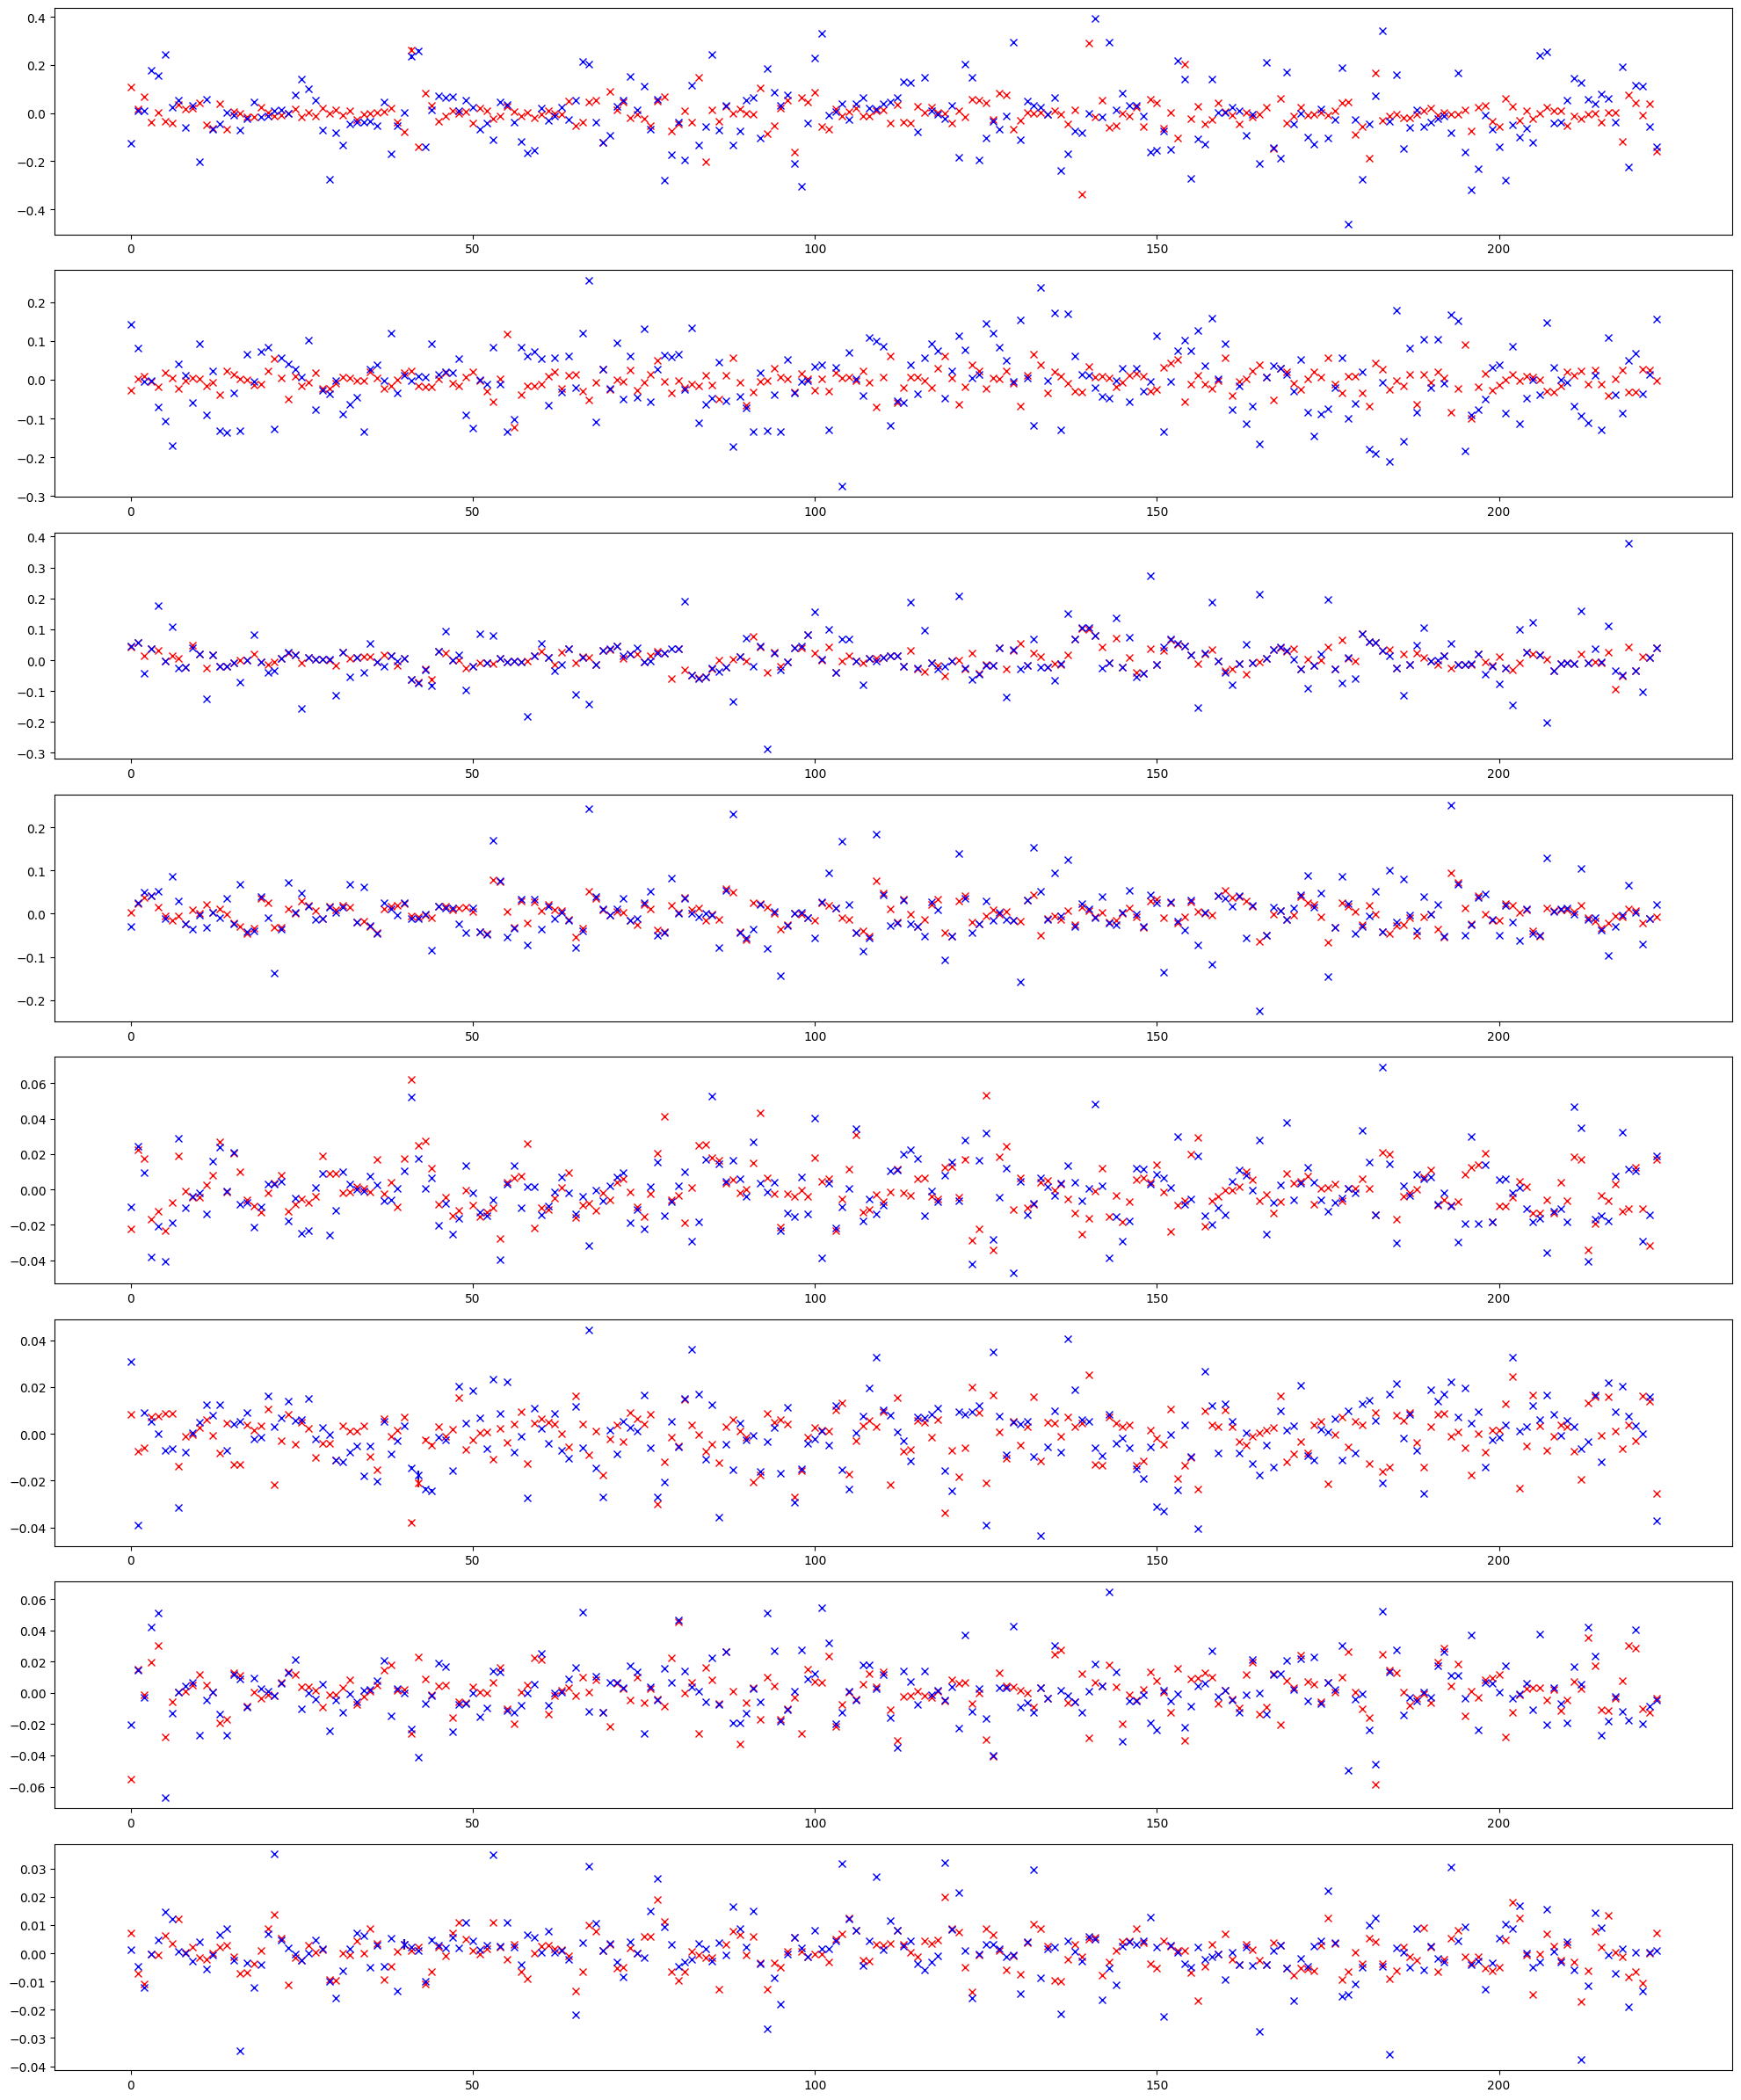

In [53]:
plt.figure(figsize=(20, 3*8))

ax = plt.subplot(811)
ax.errorbar(range(model.monitor_count), (n11 - value_n11).cpu().numpy(), yerr=error_n11.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n11_bpm - value_n11).cpu().numpy(), yerr=error_n11.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n11 - value_n11))
print(root_mean_square(n11_bpm - value_n11))
print()

ax = plt.subplot(812)
ax.errorbar(range(model.monitor_count), (n33 - value_n33).cpu().numpy(), yerr=error_n33.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n33_bpm - value_n33).cpu().numpy(), yerr=error_n33.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n33 - value_n33))
print(root_mean_square(n33_bpm - value_n33))
print()

ax = plt.subplot(813)
ax.errorbar(range(model.monitor_count), (n21 - value_n21).cpu().numpy(), yerr=error_n21.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n21_bpm - value_n21).cpu().numpy(), yerr=error_n21.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n21 - value_n21))
print(root_mean_square(n21_bpm - value_n21))
print()

ax = plt.subplot(814)
ax.errorbar(range(model.monitor_count), (n43 - value_n43).cpu().numpy(), yerr=error_n43.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n43_bpm - value_n43).cpu().numpy(), yerr=error_n43.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n43 - value_n43))
print(root_mean_square(n43_bpm - value_n43))
print()

ax = plt.subplot(815)
ax.errorbar(range(model.monitor_count), (n13 - value_n13).cpu().numpy(), yerr=error_n13.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n13_bpm - value_n13).cpu().numpy(), yerr=error_n13.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n13 - value_n13))
print(root_mean_square(n13_bpm - value_n13))
print()

ax = plt.subplot(816)
ax.errorbar(range(model.monitor_count), (n31 - value_n31).cpu().numpy(), yerr=error_n31.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n31_bpm - value_n31).cpu().numpy(), yerr=error_n31.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n31 - value_n31))
print(root_mean_square(n31_bpm - value_n31))
print()

ax = plt.subplot(817)
ax.errorbar(range(model.monitor_count), (n14 - value_n14).cpu().numpy(), yerr=error_n14.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n14_bpm - value_n14).cpu().numpy(), yerr=error_n14.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n14 - value_n14))
print(root_mean_square(n14_bpm - value_n14))
print()

ax = plt.subplot(818)
ax.errorbar(range(model.monitor_count), (n41 - value_n41).cpu().numpy(), yerr=error_n41.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n41_bpm - value_n41).cpu().numpy(), yerr=error_n41.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n41 - value_n41))
print(root_mean_square(n41_bpm - value_n41))
print()

plt.tight_layout()
plt.show()

In [54]:
# Estimate momenta at each monitor location

orbit = []
for location in range(model.monitor_count):
    orbit.append(twiss.get_momenta_lstsq(1, 256, location, 2, model.matrix))
orbit = torch.stack(orbit)
print(orbit.shape)

torch.Size([224, 4, 256])


In [55]:
# Use measured twiss to estimate invariants

s11, s33, s21, s43, s13, s31, s14, s41 = value.T
e11, e33, e21, e43, e13, e31, e14, e41 = error.T

BAG_IX = []
BAG_IY = []

for location in range(model.monitor_count):
    
    BAG_IX_MONITOR = []
    BAG_IY_MONITOR = []
    
    for _ in range(128):
        
        m11 = s11[location] + e11[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m33 = s33[location] + e33[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m21 = s21[location] + e21[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m43 = s43[location] + e43[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m13 = s13[location] + e13[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m31 = s31[location] + e31[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m14 = s14[location] + e14[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m41 = s41[location] + e41[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        
        normal = parametric_normal(m11, m33, m21, m43, m13, m31, m14, m41)
        
        QX, PX, QY, PY = normal.inverse() @ orbit[location]
        IX, IY = 0.5*(QX**2 + PX**2), 0.5*(QY**2 + PY**2)
        
        BAG_IX_MONITOR.append(IX)
        BAG_IY_MONITOR.append(IY)
        
    BAG_IX.append(BAG_IX_MONITOR)
    BAG_IY.append(BAG_IY_MONITOR)

BAG_IX = torch.stack([torch.stack(IX) for IX in BAG_IX]).reshape(model.monitor_count, -1)
BAG_IY = torch.stack([torch.stack(IY) for IY in BAG_IY]).reshape(model.monitor_count, -1)

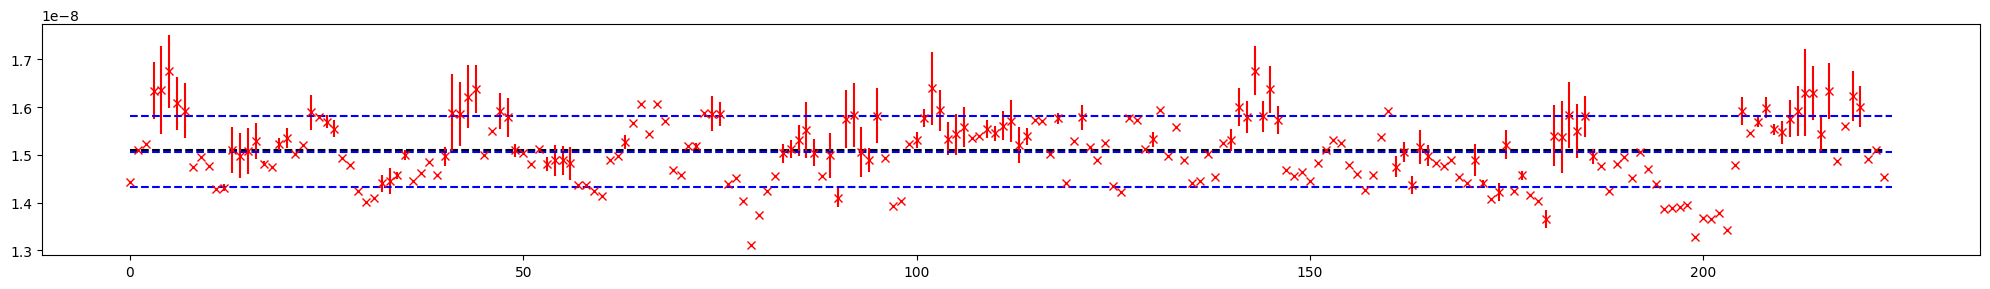

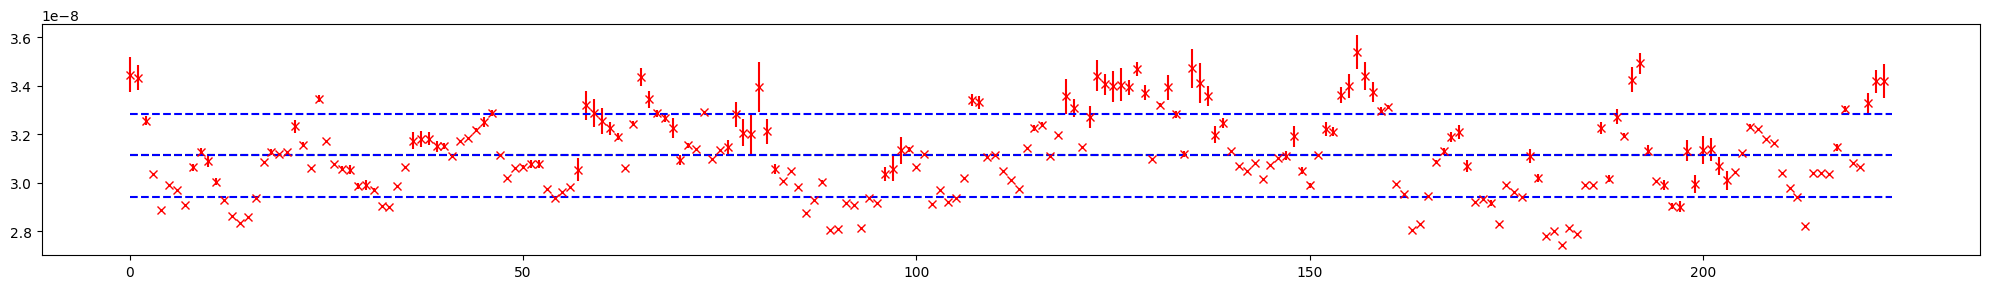

tensor(1.5100e-08, dtype=torch.float64)
tensor(1.3997e-08, dtype=torch.float64)
tensor(1.3997e-08, dtype=torch.float64)
tensor(1.5081e-08, dtype=torch.float64)
tensor(1.5063e-08, dtype=torch.float64)

tensor(3.1155e-08, dtype=torch.float64)
tensor(2.9843e-08, dtype=torch.float64)
tensor(2.9843e-08, dtype=torch.float64)
tensor(3.1181e-08, dtype=torch.float64)
tensor(3.1144e-08, dtype=torch.float64)



In [56]:
# Plot invariants for each monitor

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), BAG_IX.mean(-1).flatten().cpu().numpy(), yerr=BAG_IX.std(-1).cpu().numpy(), fmt=' ', color='red', marker='x')

plt.hlines(ix.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([BAG_IX.mean() - BAG_IX.std(), BAG_IX.mean(), BAG_IX.mean() + BAG_IX.std()], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), BAG_IY.mean(-1).flatten().cpu().numpy(), yerr=BAG_IY.std(-1).cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(iy.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([BAG_IY.mean() - BAG_IY.std(), BAG_IY.mean(), BAG_IY.mean() + BAG_IY.std()], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

print(ix.mean())
print(twiss.action['center_jx'])
print(invariant['ix_value'])
print(ix_out.mean())
print(BAG_IX.mean())
print()

print(iy.mean())
print(twiss.action['center_jy'])
print(invariant['iy_value'])
print(iy_out.mean())
print(BAG_IY.mean())
print()

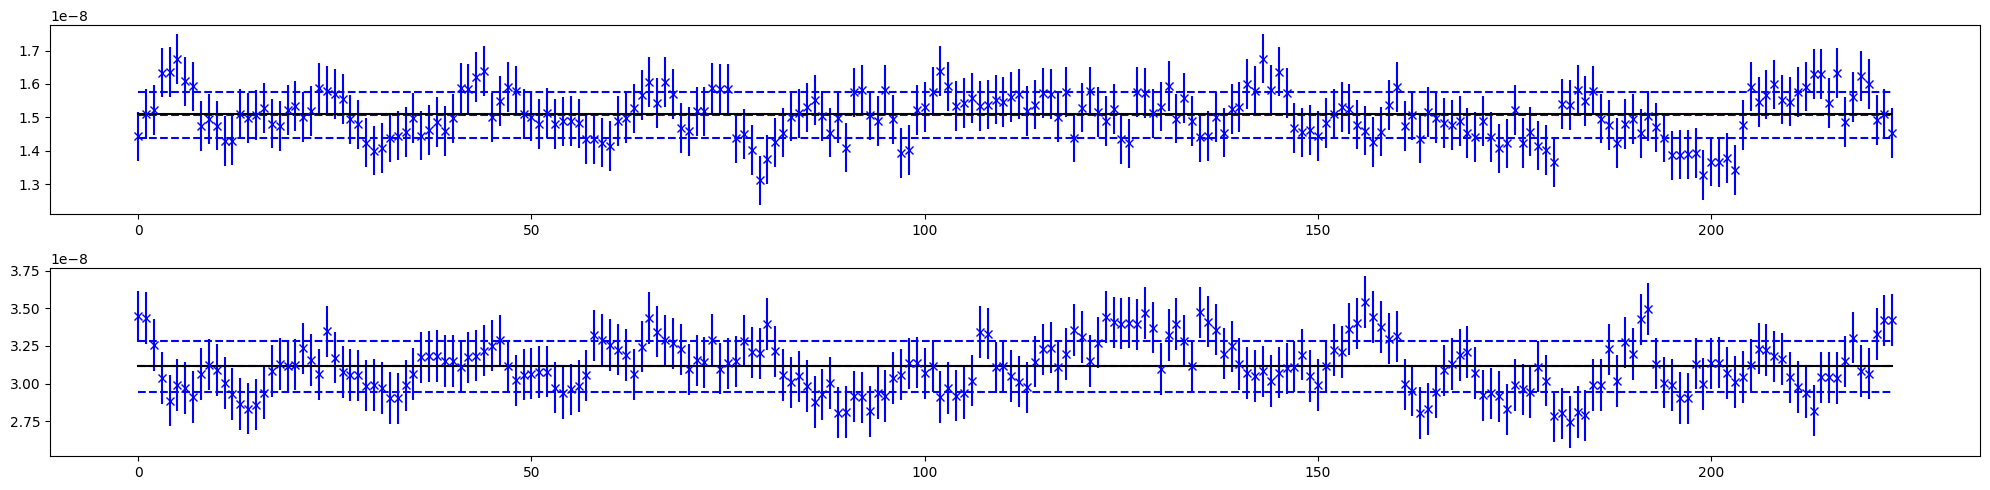

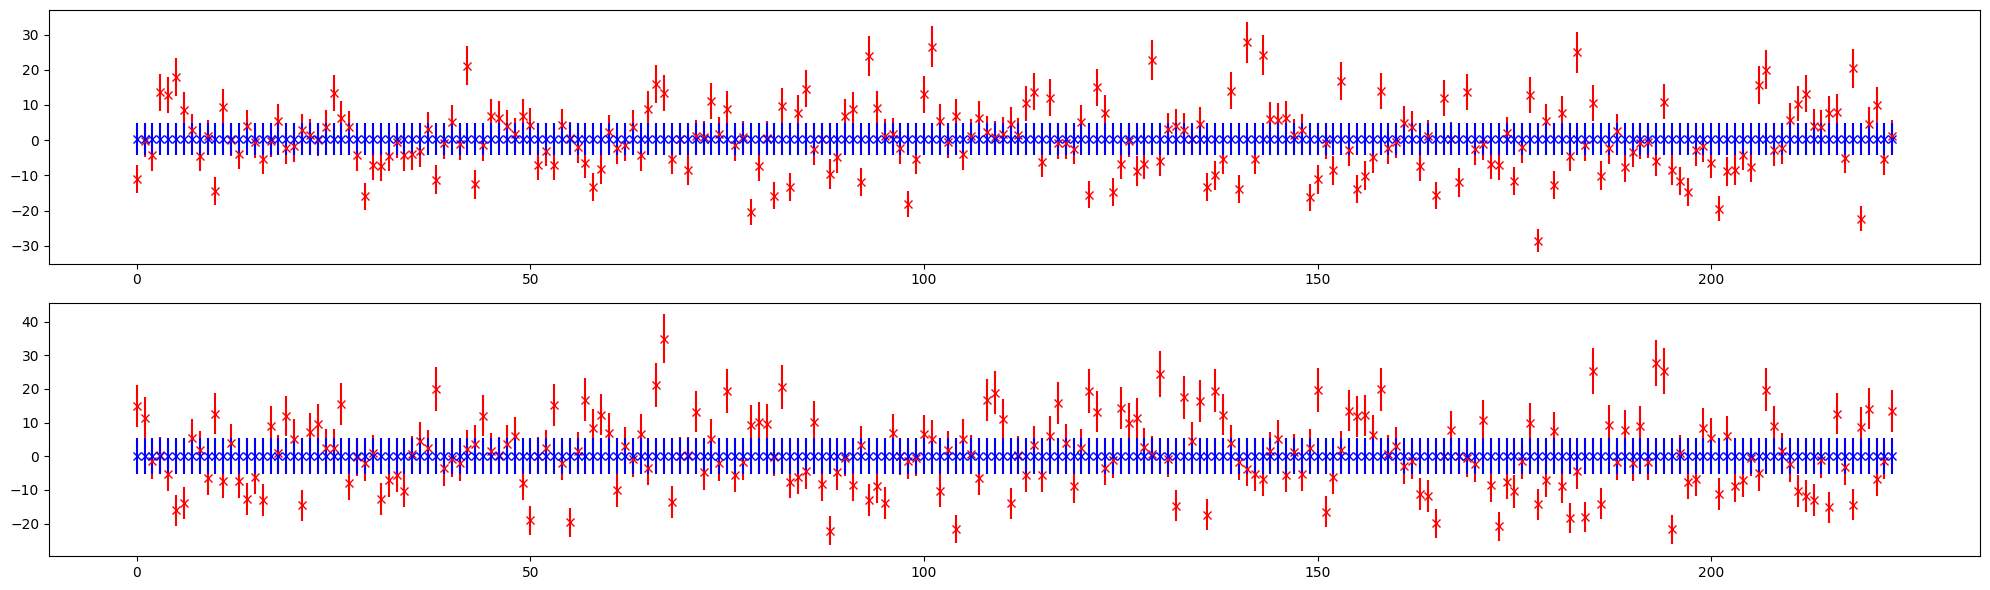

tensor(9.4925, dtype=torch.float64)
tensor(10.6037, dtype=torch.float64)

tensor(0.2489, dtype=torch.float64)
tensor(0.0357, dtype=torch.float64)



In [57]:
# Estimate twiss from amplitude (use invariants from coupled twiss)

twiss.get_action(jx=BAG_IX.mean(-1), jy=BAG_IY.mean(-1), sigma_jx=BAG_IX.std(), sigma_jy=BAG_IY.std())
twiss.get_twiss_from_amplitude()

# Compare estimated invariants

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), ix.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jx'].cpu().numpy(), yerr=twiss.action['sigma_jx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jx'] - twiss.action['spread_jx']).cpu().numpy(), twiss.action['center_jx'].cpu().numpy(), (twiss.action['center_jx'] + twiss.action['spread_jx']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), iy.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jy'].cpu().numpy(), yerr=twiss.action['sigma_jy'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jy'] - twiss.action['spread_jy']).cpu().numpy(), twiss.action['center_jy'].cpu().numpy(), (twiss.action['center_jy'] + twiss.action['spread_jy']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
plt.tight_layout()
plt.show()

# Compare estimated twiss

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by)/by).cpu().numpy(), yerr=100/by*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by_bpm)/by_bpm).cpu().numpy(), yerr=100/by_bpm*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx)/bx)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by)/by)))
print()

print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by_bpm)/by_bpm)))
print()

In [58]:
# Rescale TbT using estimated gxx and gyy from ratio

twiss.table.x = qx_bpm/gxx_phase.reshape(-1, 1)
twiss.table.y = qy_bpm/gyy_phase.reshape(-1, 1)

In [59]:
# Note, after this rescaling gxx and gyy can be reestimated and used to in a new fit

In [60]:
%%time

# Estimate twiss from invariant fit (fixed invariants)

count = 8

data = twiss.get_twiss_from_data(1,                # -- first turn
                                 256,              # -- total number of turns, orbits are computed for (start, start + total)
                                 parametric_normal,# -- normalization
                                 model.matrix,     # -- transport matrix generator
                                 twiss=None,       # -- initial twiss for each location or None (use model values)
                                 method='lstsq',   # -- momenta computation method
                                 limit=2,          # -- range limit or direction/shift
                                 product=True,     # -- flag to use product objective
                                 jacobian=False,   # -- flag to use objective jacobian
                                 count=count,      # -- number of samples
                                 fraction=0.75,    # -- sample length fraction
                                 ix=ix_out.mean(), # -- ix invariant value
                                 iy=iy_out.mean(), # -- iy invariant value  (both should present for fixed fit)
                                 n_jobs=4,         # -- number of parallel jobs (loop over samples)
                                 verbose=False)    # -- verbose flag

CPU times: user 8min 44s, sys: 1min 26s, total: 10min 10s
Wall time: 12min 13s


In [61]:
# Process twiss

value_n11 = data[:, 0, 0]
error_n11 = data[:, 1, 0]

value_n33 = data[:, 0, 1]
error_n33 = data[:, 1, 1]

value_n21 = data[:, 0, 2]
error_n21 = data[:, 1, 2]

value_n43 = data[:, 0, 3]
error_n43 = data[:, 1, 3]

value_n13 = data[:, 0, 4]
error_n13 = data[:, 1, 4]

value_n31 = data[:, 0, 5]
error_n31 = data[:, 1, 5]

value_n14 = data[:, 0, 6]
error_n14 = data[:, 1, 6]

value_n41 = data[:, 0, 7]
error_n41 = data[:, 1, 7]

value_n11, error_n11 = twiss.process(value_n11, error_n11)
value_n33, error_n33 = twiss.process(value_n33, error_n33)
value_n21, error_n21 = twiss.process(value_n21, error_n21)
value_n43, error_n43 = twiss.process(value_n43, error_n43)
value_n13, error_n13 = twiss.process(value_n13, error_n13)
value_n31, error_n31 = twiss.process(value_n31, error_n31)
value_n14, error_n14 = twiss.process(value_n14, error_n14)
value_n41, error_n41 = twiss.process(value_n41, error_n41)

value = torch.stack([value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41]).T
error = torch.stack([error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41]).T

cs_value, cs_error = [], []

for value_loc, error_loc in zip(value, error):
    table = value_loc.reshape(-1, 1) + error_loc.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax, value_bx, value_ay, value_by = cs_value.T
error_ax, error_bx, error_ay, error_by = cs_error.T

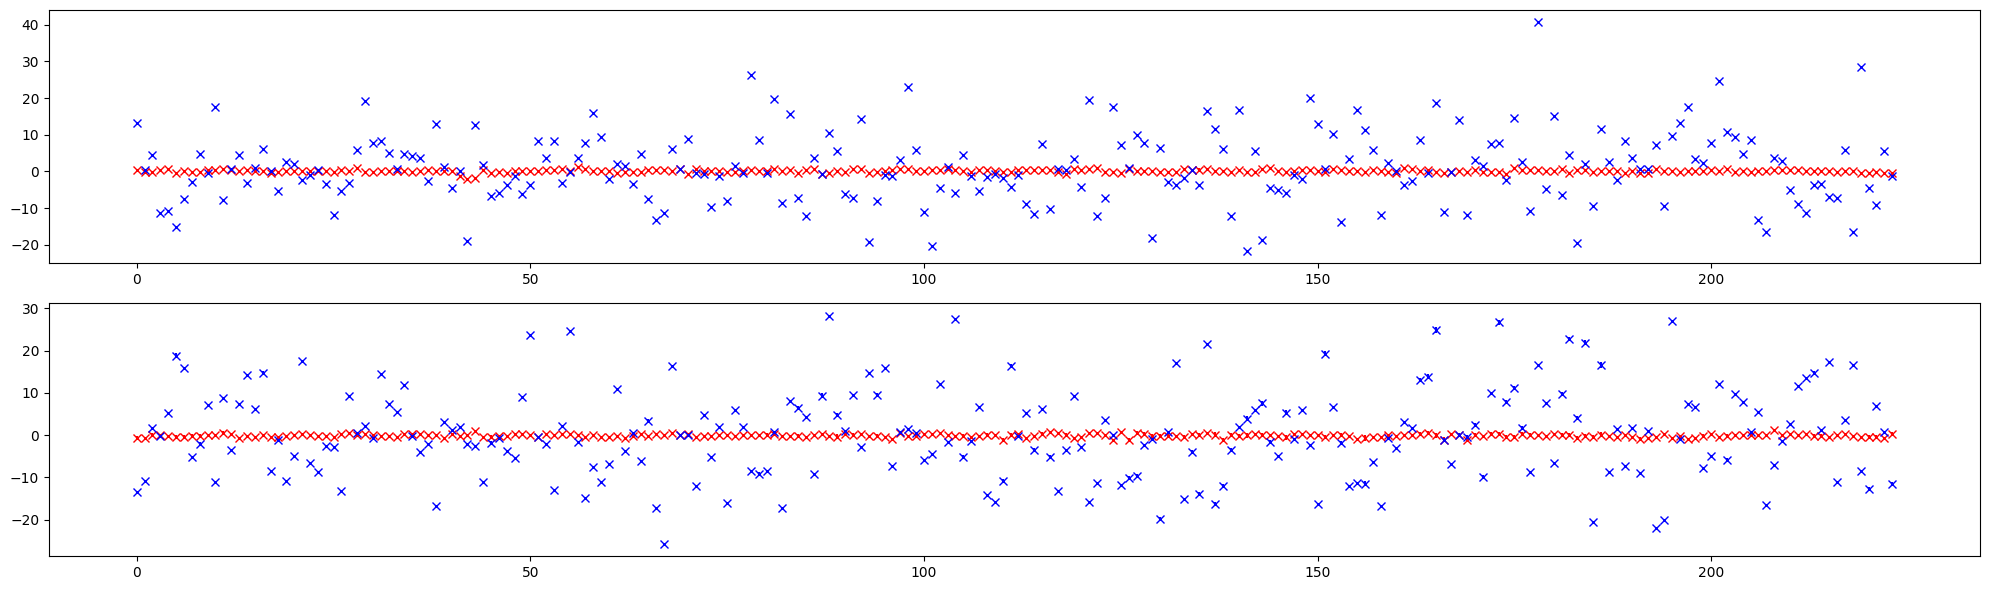

tensor(0.4053, dtype=torch.float64)
tensor(0.3918, dtype=torch.float64)

tensor(9.6921, dtype=torch.float64)
tensor(10.5886, dtype=torch.float64)



In [62]:
# Compare beta function values

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((value_bx - bx)/bx).cpu().numpy(), yerr=100/bx*error_bx.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((value_bx - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*error_bx.cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((value_by - by)/by).cpu().numpy(), yerr=100/by*error_by.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((value_by - by_bpm)/by_bpm).cpu().numpy(), yerr=100/by_bpm*error_by.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((value_bx - bx)/bx)))
print(root_mean_square(100*((value_by - by)/by)))
print()

print(root_mean_square(100*((value_bx - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((value_by - by_bpm)/by_bpm)))
print()

tensor(0.0066, dtype=torch.float64)
tensor(0.1463, dtype=torch.float64)

tensor(0.0035, dtype=torch.float64)
tensor(0.0992, dtype=torch.float64)

tensor(0.0027, dtype=torch.float64)
tensor(0.0676, dtype=torch.float64)

tensor(0.0035, dtype=torch.float64)
tensor(0.0493, dtype=torch.float64)

tensor(0.0151, dtype=torch.float64)
tensor(0.0215, dtype=torch.float64)

tensor(0.0117, dtype=torch.float64)
tensor(0.0189, dtype=torch.float64)

tensor(0.0195, dtype=torch.float64)
tensor(0.0257, dtype=torch.float64)

tensor(0.0068, dtype=torch.float64)
tensor(0.0110, dtype=torch.float64)



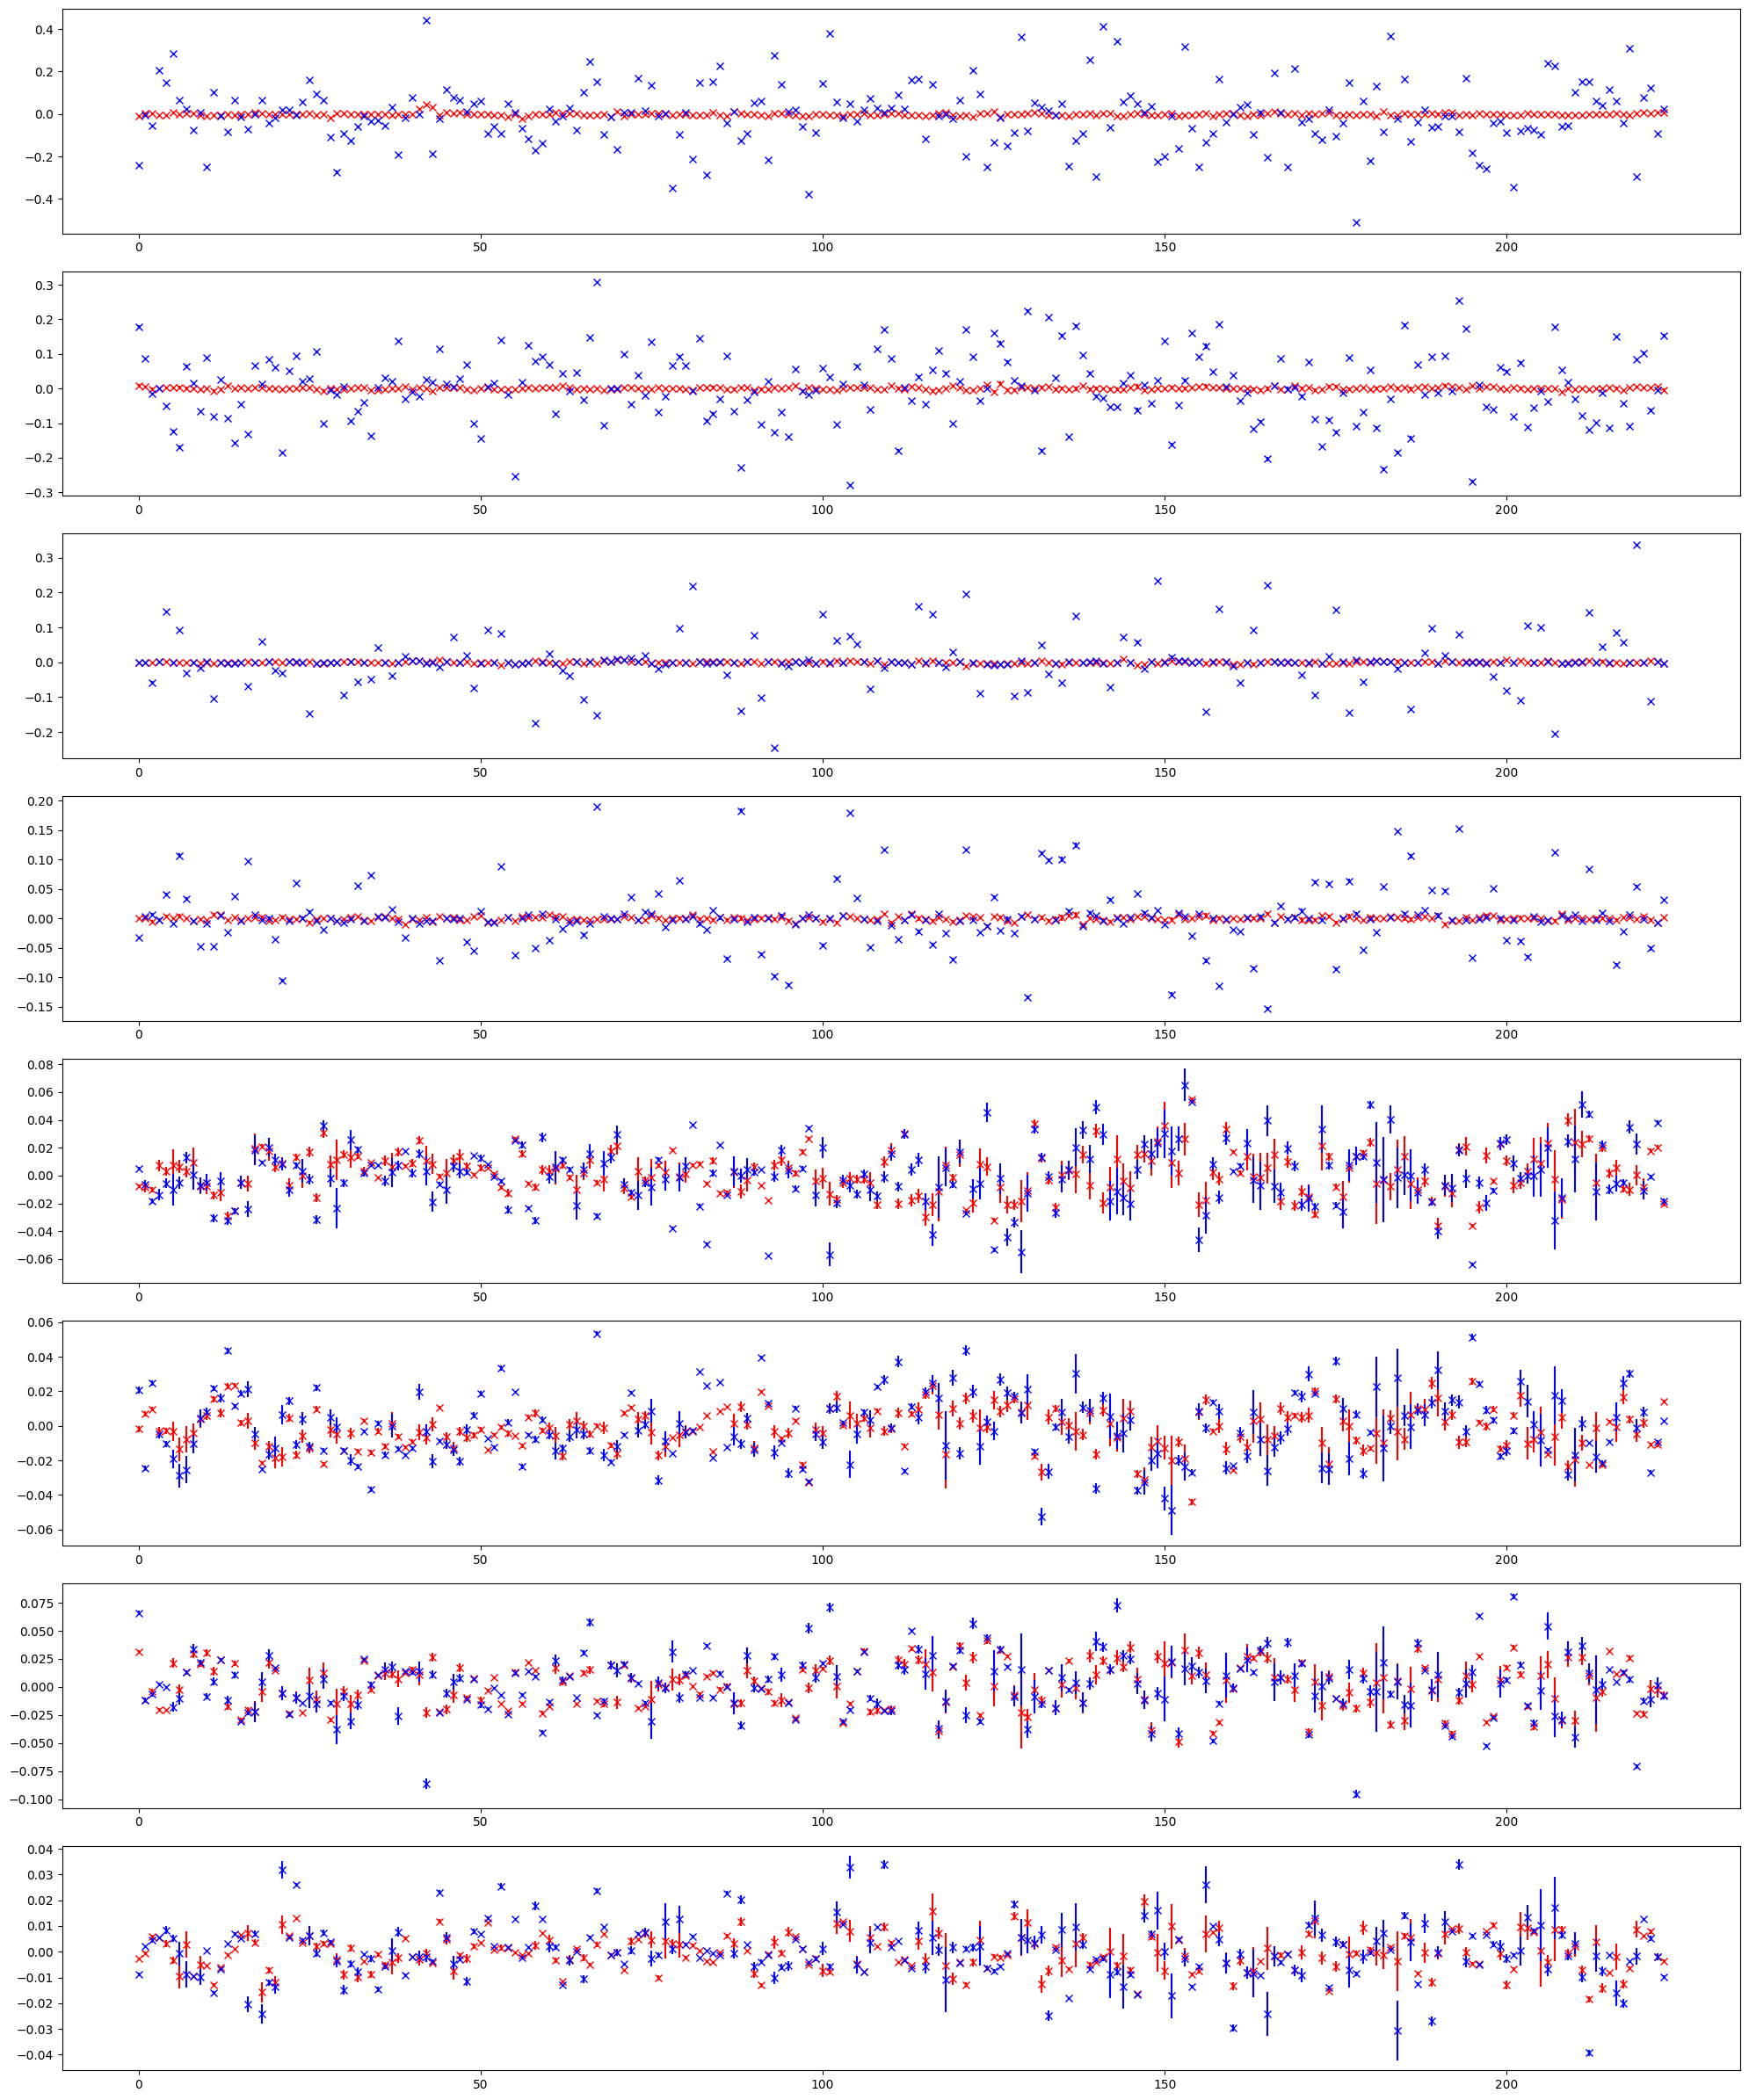

In [63]:
# Compare estimated normalization matrix elements

plt.figure(figsize=(20, 3*8))

ax = plt.subplot(811)
ax.errorbar(range(model.monitor_count), (n11 - value_n11).cpu().numpy(), yerr=error_n11.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n11_bpm - value_n11).cpu().numpy(), yerr=error_n11.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n11 - value_n11))
print(root_mean_square(n11_bpm - value_n11))
print()

ax = plt.subplot(812)
ax.errorbar(range(model.monitor_count), (n33 - value_n33).cpu().numpy(), yerr=error_n33.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n33_bpm - value_n33).cpu().numpy(), yerr=error_n33.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n33 - value_n33))
print(root_mean_square(n33_bpm - value_n33))
print()

ax = plt.subplot(813)
ax.errorbar(range(model.monitor_count), (n21 - value_n21).cpu().numpy(), yerr=error_n21.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n21_bpm - value_n21).cpu().numpy(), yerr=error_n21.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n21 - value_n21))
print(root_mean_square(n21_bpm - value_n21))
print()

ax = plt.subplot(814)
ax.errorbar(range(model.monitor_count), (n43 - value_n43).cpu().numpy(), yerr=error_n43.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n43_bpm - value_n43).cpu().numpy(), yerr=error_n43.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n43 - value_n43))
print(root_mean_square(n43_bpm - value_n43))
print()

ax = plt.subplot(815)
ax.errorbar(range(model.monitor_count), (n13 - value_n13).cpu().numpy(), yerr=error_n13.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n13_bpm - value_n13).cpu().numpy(), yerr=error_n13.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n13 - value_n13))
print(root_mean_square(n13_bpm - value_n13))
print()

ax = plt.subplot(816)
ax.errorbar(range(model.monitor_count), (n31 - value_n31).cpu().numpy(), yerr=error_n31.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n31_bpm - value_n31).cpu().numpy(), yerr=error_n31.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n31 - value_n31))
print(root_mean_square(n31_bpm - value_n31))
print()

ax = plt.subplot(817)
ax.errorbar(range(model.monitor_count), (n14 - value_n14).cpu().numpy(), yerr=error_n14.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n14_bpm - value_n14).cpu().numpy(), yerr=error_n14.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n14 - value_n14))
print(root_mean_square(n14_bpm - value_n14))
print()

ax = plt.subplot(818)
ax.errorbar(range(model.monitor_count), (n41 - value_n41).cpu().numpy(), yerr=error_n41.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n41_bpm - value_n41).cpu().numpy(), yerr=error_n41.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n41 - value_n41))
print(root_mean_square(n41_bpm - value_n41))
print()

plt.tight_layout()
plt.show()

In [64]:
# Set all normalization matrix elements

value_normal = torch.stack([parametric_normal(w11, w33, w21, w43, w13, w31, w14, w41) for w11, w33, w21, w43, w13, w31, w14, w41 in zip(value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41)])

value_n11 = value_normal[:, 0, 0]
value_n12 = value_normal[:, 0, 1]
value_n13 = value_normal[:, 0, 2]
value_n14 = value_normal[:, 0, 3]

value_n21 = value_normal[:, 1, 0]
value_n22 = value_normal[:, 1, 1]
value_n23 = value_normal[:, 1, 2]
value_n24 = value_normal[:, 1, 3]

value_n31 = value_normal[:, 2, 0]
value_n32 = value_normal[:, 2, 1]
value_n33 = value_normal[:, 2, 2]
value_n34 = value_normal[:, 2, 3]

value_n41 = value_normal[:, 3, 0]
value_n42 = value_normal[:, 3, 1]
value_n43 = value_normal[:, 3, 2]
value_n44 = value_normal[:, 3, 3]

## Calibration scales (fitted invariant)

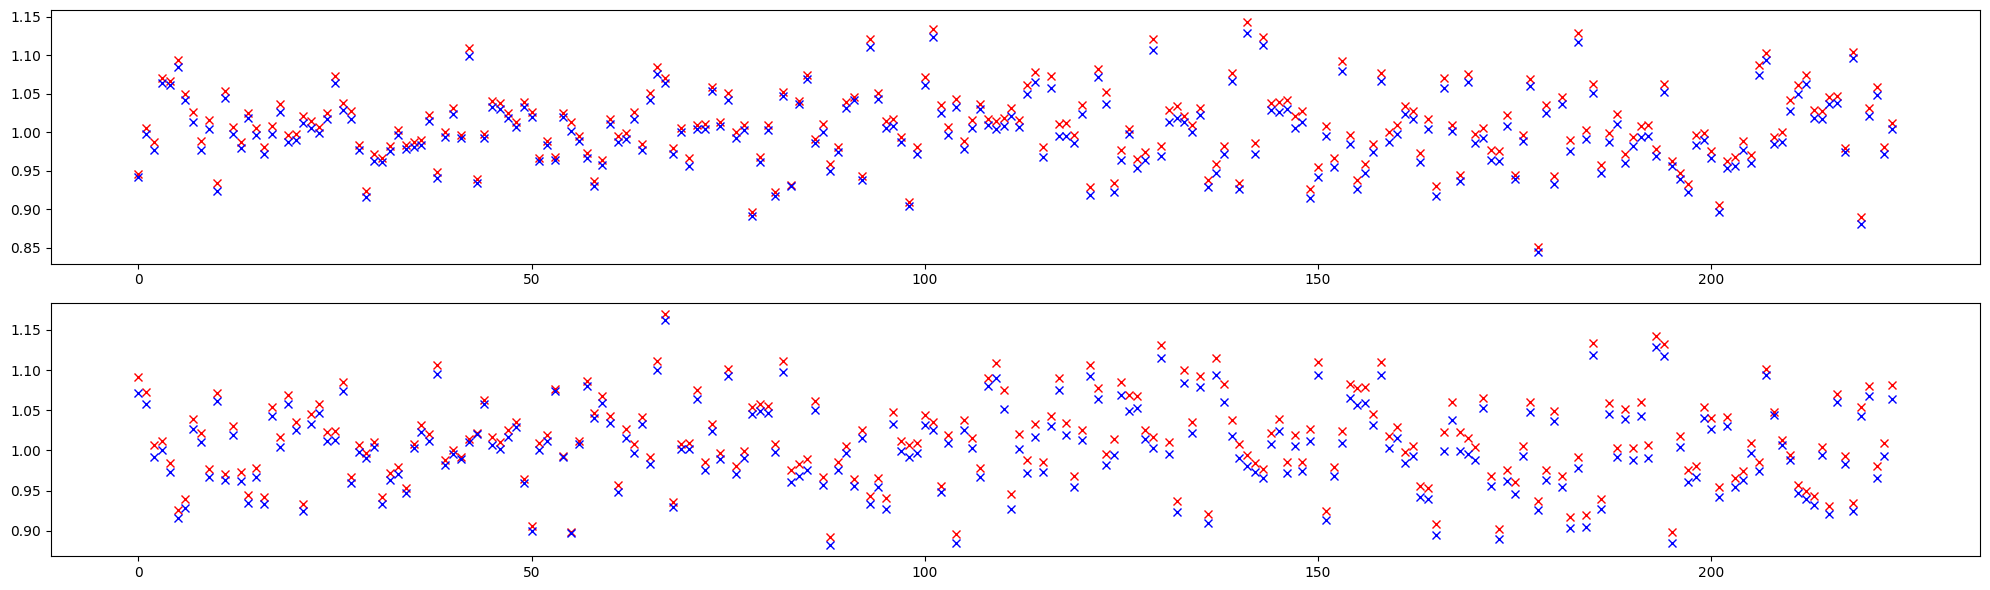

tensor(0.9814, dtype=torch.float64)
tensor(1.2470, dtype=torch.float64)



In [65]:
# Ratio (invariants from phase twiss)

twiss = Twiss(model, table_bpm, limit=4)

twiss.phase_virtual()
twiss.get_twiss_from_phase()
mask_x = twiss.filter_twiss(plane='x', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
mask_y = twiss.filter_twiss(plane='y', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
_ = twiss.process_twiss(plane='x', mask=mask_x, weight=True)
_ = twiss.process_twiss(plane='y', mask=mask_y, weight=True)

twiss.get_action(bx=twiss.bx[model.monitor_index], by=twiss.by[model.monitor_index], sigma_bx=twiss.sigma_bx[model.monitor_index], sigma_by=twiss.sigma_by[model.monitor_index])
twiss.get_twiss_from_amplitude()

# Ratio

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['bx']/twiss.bx[model.monitor_index]).sqrt().cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), g_xx.cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['by']/twiss.by[model.monitor_index]).sqrt().cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), g_yy.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

gxx_phase = (twiss.data_amplitude['bx']/twiss.bx[model.monitor_index]).sqrt()
gyy_phase = (twiss.data_amplitude['by']/twiss.by[model.monitor_index]).sqrt()

print(root_mean_square(100*(((twiss.data_amplitude['bx']/twiss.bx[model.monitor_index]).sqrt() - g_xx)/g_xx)))
print(root_mean_square(100*(((twiss.data_amplitude['by']/twiss.by[model.monitor_index]).sqrt() - g_yy)/g_yy)))
print()

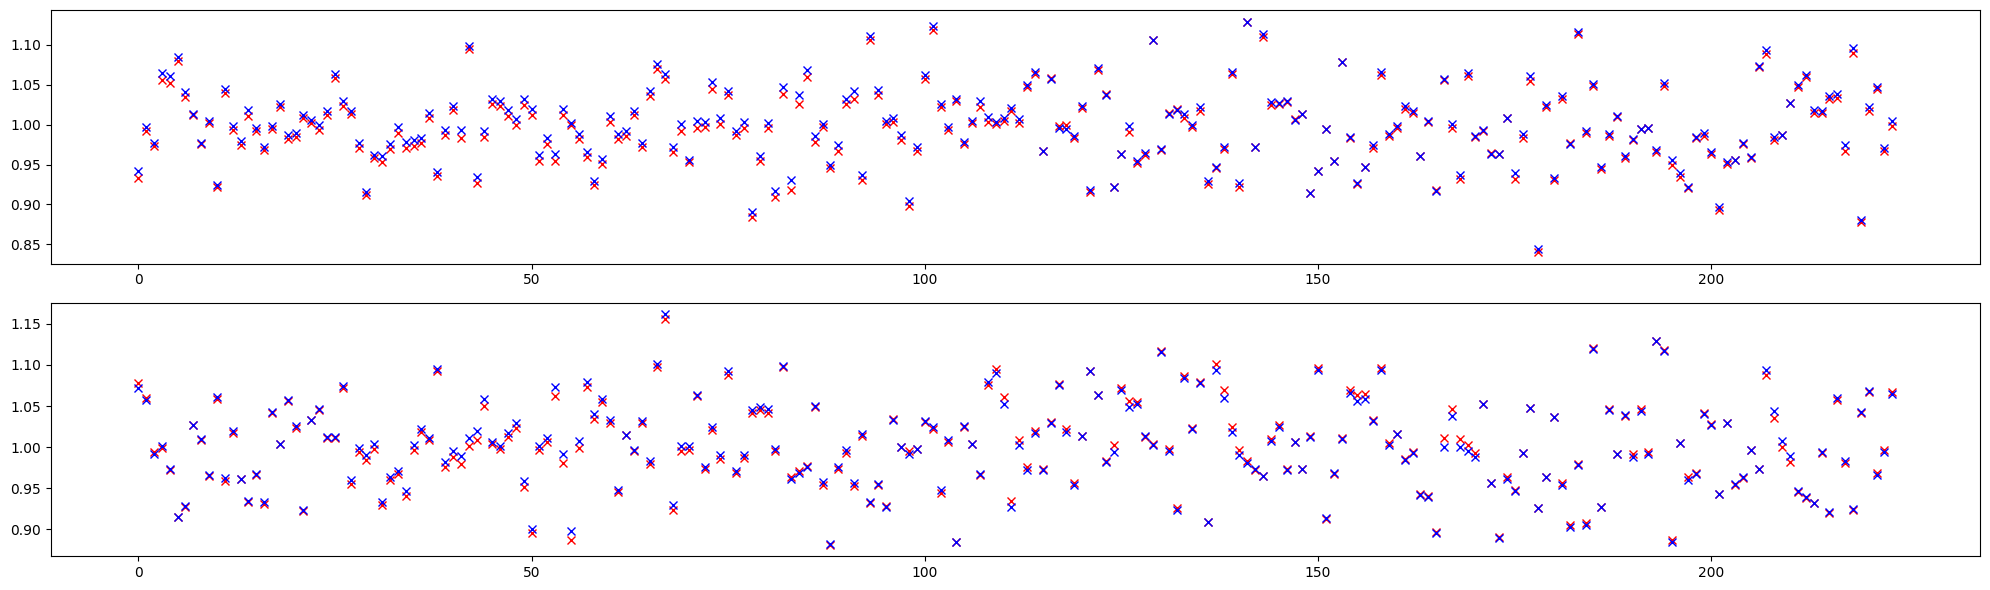

tensor(0.4860, dtype=torch.float64)
tensor(0.3915, dtype=torch.float64)



In [66]:
# Ratio (fitted invariants)

twiss = Twiss(model, table_bpm, limit=4)

twiss.phase_virtual()
twiss.get_twiss_from_phase()
mask_x = twiss.filter_twiss(plane='x', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
mask_y = twiss.filter_twiss(plane='y', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
_ = twiss.process_twiss(plane='x', mask=mask_x, weight=True)
_ = twiss.process_twiss(plane='y', mask=mask_y, weight=True)

twiss.get_action(jx=BAG_IX.mean(-1), jy=BAG_IY.mean(-1), sigma_jx=BAG_IX.std(-1), sigma_jy=BAG_IY.std(-1))
twiss.get_twiss_from_amplitude()

# Ratio

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['bx']/twiss.bx[model.monitor_index]).sqrt().cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), g_xx.cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['by']/twiss.by[model.monitor_index]).sqrt().cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), g_yy.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

gxx_fit = (twiss.data_amplitude['bx']/twiss.bx[model.monitor_index]).sqrt()
gyy_fit = (twiss.data_amplitude['by']/twiss.by[model.monitor_index]).sqrt()

print(root_mean_square(100*(((twiss.data_amplitude['bx']/twiss.bx[model.monitor_index]).sqrt() - g_xx)/g_xx)))
print(root_mean_square(100*(((twiss.data_amplitude['by']/twiss.by[model.monitor_index]).sqrt() - g_yy)/g_yy)))
print()

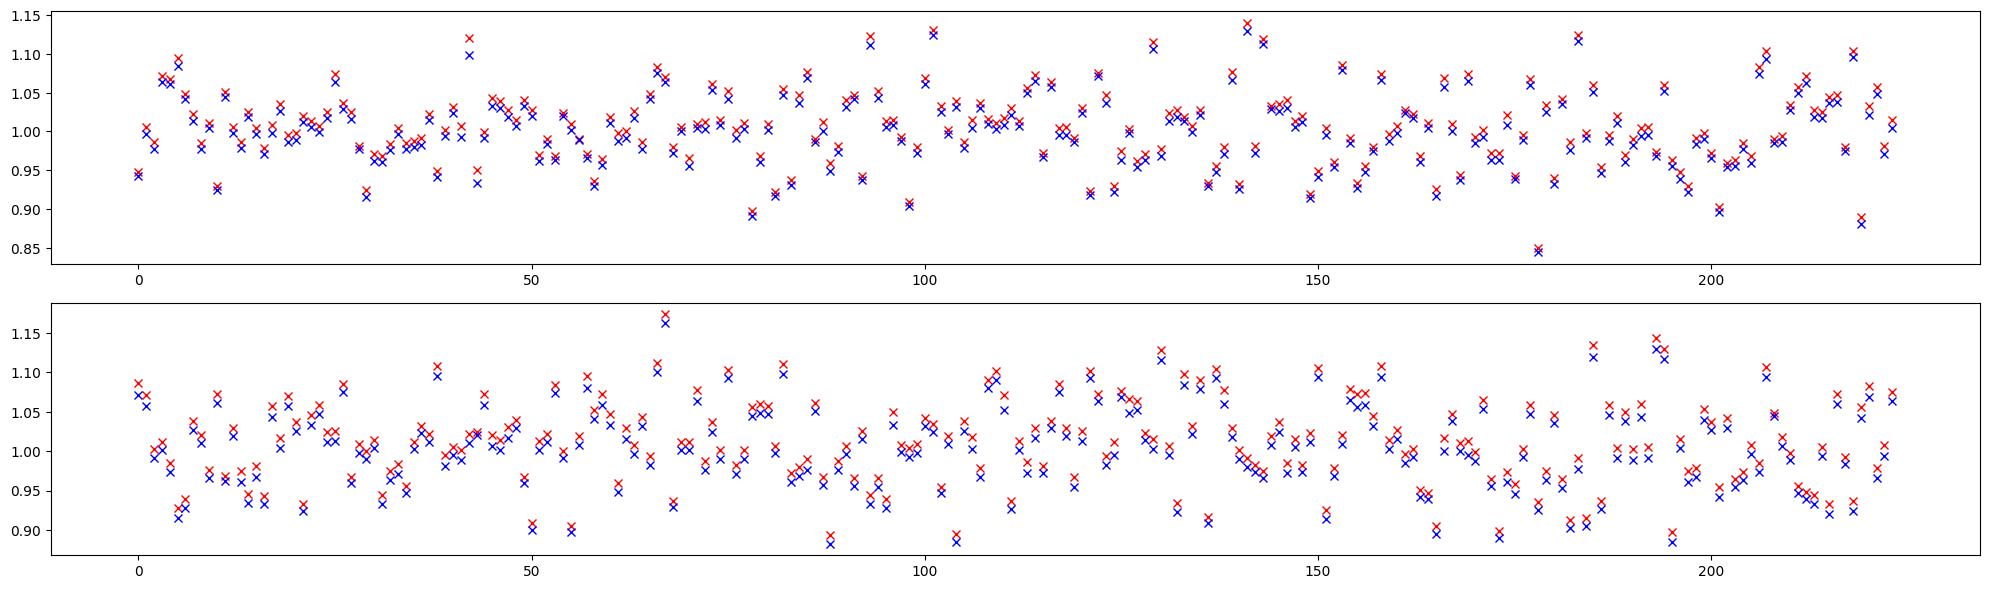

tensor(0.8073, dtype=torch.float64)
tensor(1.1594, dtype=torch.float64)



In [67]:
# Ratio (fitted invariants & twiss from scaled TbT)

twiss = Twiss(model, table_bpm, limit=4)

twiss.phase_virtual()
twiss.get_twiss_from_phase()
mask_x = twiss.filter_twiss(plane='x', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
mask_y = twiss.filter_twiss(plane='y', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
_ = twiss.process_twiss(plane='x', mask=mask_x, weight=True)
_ = twiss.process_twiss(plane='y', mask=mask_y, weight=True)

twiss.get_action(jx=BAG_IX.mean(-1), jy=BAG_IY.mean(-1), sigma_jx=BAG_IX.std(-1), sigma_jy=BAG_IY.std(-1))
twiss.get_twiss_from_amplitude()

# Ratio

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['bx']/value_bx).sqrt().cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), g_xx.cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['by']/value_by).sqrt().cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), g_yy.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

gxx_fit = (twiss.data_amplitude['bx']/value_bx).sqrt()
gyy_fit = (twiss.data_amplitude['by']/value_by).sqrt()

print(root_mean_square(100*(((twiss.data_amplitude['bx']/value_bx).sqrt() - g_xx)/g_xx)))
print(root_mean_square(100*(((twiss.data_amplitude['by']/value_by).sqrt() - g_yy)/g_yy)))
print()

## Compute normalization matrix elements

In [68]:
# Check amplitudes (exact values)

print(root_mean_square(axx**2 - 2*ix*n11**2))
print(root_mean_square(axy**2 - 2*iy*(n13**2 + n14**2)))
print(root_mean_square(ayx**2 - 2*ix*(n31**2 + n32**2)))
print(root_mean_square(ayy**2 - 2*iy*n33**2))
print()

print(root_mean_square(axx_bpm**2 - 2*ix*n11_bpm**2))
print(root_mean_square(axy_bpm**2 - 2*iy*(n13_bpm**2 + n14_bpm**2)))
print(root_mean_square(ayx_bpm**2 - 2*ix*(n31_bpm**2 + n32_bpm**2)))
print(root_mean_square(ayy_bpm**2 - 2*iy*n33_bpm**2))
print()

tensor(8.7057e-15, dtype=torch.float64)
tensor(8.7069e-15, dtype=torch.float64)
tensor(3.5272e-15, dtype=torch.float64)
tensor(3.5294e-15, dtype=torch.float64)

tensor(8.7086e-15, dtype=torch.float64)
tensor(8.7097e-15, dtype=torch.float64)
tensor(3.5154e-15, dtype=torch.float64)
tensor(3.5176e-15, dtype=torch.float64)



In [69]:
# Check phases (exact values)

print(root_mean_square(fxy - torch.atan2((fyy.sin() * n13 + fyy.cos() * n14), (fyy.cos() * n13 - fyy.sin() * n14))))
print(root_mean_square(fyx - torch.atan2((fxx.sin() * n31 + fxx.cos() * n32), (fxx.cos() * n31 - fxx.sin() * n32))))
print()

print(root_mean_square(fxy_bpm - torch.atan2((fyy_bpm.sin() * n13_bpm + fyy_bpm.cos() * n14_bpm), (fyy_bpm.cos() * n13_bpm - fyy_bpm.sin() * n14_bpm))))
print(root_mean_square(fyx_bpm - torch.atan2((fxx_bpm.sin() * n31_bpm + fxx_bpm.cos() * n32_bpm), (fxx_bpm.cos() * n31_bpm - fxx_bpm.sin() * n32_bpm))))
print()

tensor(8.3043e-08, dtype=torch.float64)
tensor(1.6959e-07, dtype=torch.float64)

tensor(8.3186e-08, dtype=torch.float64)
tensor(1.6972e-07, dtype=torch.float64)



In [70]:
# Check normalization matrix elements (exact values)

print(root_mean_square(n11**2 - axx**2/(2*ix)))
print(root_mean_square(n33**2 - ayy**2/(2*iy)))
print(root_mean_square((n13**2 + n14**2) - axy**2/(2*iy)))
print(root_mean_square((n31**2 + n32**2) - ayx**2/(2*ix)))
print(root_mean_square(n13 - axy/ayy*(fxy - fyy).cos()*n33))
print(root_mean_square(n14 - axy/ayy*(fxy - fyy).sin()*n33))
print(root_mean_square(n31 - ayx/axx*(fyx - fxx).cos()*n11))
print(root_mean_square(n32 - ayx/axx*(fyx - fxx).sin()*n11))
print()

print(root_mean_square(n11_bpm**2 - axx_bpm**2/(2*ix)))
print(root_mean_square(n33_bpm**2 - ayy_bpm**2/(2*iy)))
print(root_mean_square((n13_bpm**2 + n14_bpm**2) - axy_bpm**2/(2*iy)))
print(root_mean_square((n31_bpm**2 + n32_bpm**2) - ayx_bpm**2/(2*ix)))
print(root_mean_square(n13_bpm - axy_bpm/ayy_bpm*(fxy_bpm - fyy_bpm).cos()*n33_bpm))
print(root_mean_square(n14_bpm - axy_bpm/ayy_bpm*(fxy_bpm - fyy_bpm).sin()*n33_bpm))
print(root_mean_square(n31_bpm - ayx_bpm/axx_bpm*(fyx_bpm - fxx_bpm).cos()*n11_bpm))
print(root_mean_square(n32_bpm - ayx_bpm/axx_bpm*(fyx_bpm - fxx_bpm).sin()*n11_bpm))
print()

tensor(2.8826e-07, dtype=torch.float64)
tensor(5.6642e-08, dtype=torch.float64)
tensor(1.3973e-07, dtype=torch.float64)
tensor(1.1679e-07, dtype=torch.float64)
tensor(1.0268e-07, dtype=torch.float64)
tensor(1.0086e-07, dtype=torch.float64)
tensor(1.3781e-07, dtype=torch.float64)
tensor(1.3151e-07, dtype=torch.float64)

tensor(2.8835e-07, dtype=torch.float64)
tensor(5.6452e-08, dtype=torch.float64)
tensor(1.3978e-07, dtype=torch.float64)
tensor(1.1640e-07, dtype=torch.float64)
tensor(1.0295e-07, dtype=torch.float64)
tensor(1.0049e-07, dtype=torch.float64)
tensor(1.3753e-07, dtype=torch.float64)
tensor(1.3185e-07, dtype=torch.float64)



In [71]:
# Set  estimated invariants

ix_fit = ix_out.mean()
iy_fit = iy_out.mean()

twiss.phase_virtual()
twiss.get_twiss_from_phase()
mask_x = twiss.filter_twiss(plane='x', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
mask_y = twiss.filter_twiss(plane='y', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
_ = twiss.process_twiss(plane='x', mask=mask_x, weight=True)
_ = twiss.process_twiss(plane='y', mask=mask_y, weight=True)

twiss.get_action(jx=BAG_IX.mean(-1), jy=BAG_IY.mean(-1), sigma_jx=BAG_IX.std(-1), sigma_jy=BAG_IY.std(-1))
twiss.get_twiss_from_amplitude()

print(ix.mean())
print(ix_fit)
print()

print(iy.mean())
print(iy_fit.mean())
print()

tensor(1.5100e-08, dtype=torch.float64)
tensor(1.5081e-08, dtype=torch.float64)

tensor(3.1155e-08, dtype=torch.float64)
tensor(3.1181e-08, dtype=torch.float64)



tensor(0.1457, dtype=torch.float64)
tensor(0.0019, dtype=torch.float64)

tensor(0.0066, dtype=torch.float64)
tensor(0.0224, dtype=torch.float64)
tensor(0.1471, dtype=torch.float64)



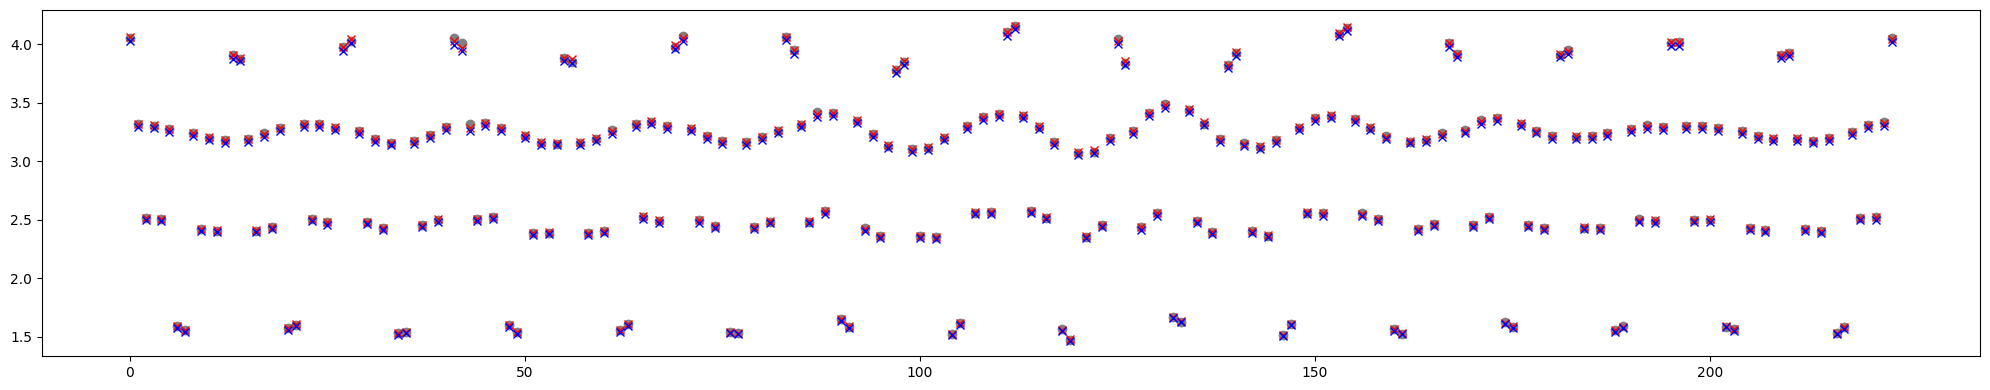

In [72]:
# n11 (bpm)

n11_estimate = axx_bpm/(2*ix_fit).sqrt()

print(root_mean_square(n11 - n11_estimate))
print(root_mean_square(n11_bpm - n11_estimate))
print()

# n11 (beam)

n11_estimate = n11_estimate/gxx_fit

print(root_mean_square(n11 - value_n11))
print(root_mean_square(n11 - n11_estimate))
print(root_mean_square(n11_bpm - n11_estimate))
print()

plt.figure(figsize=(20, 4))
plt.errorbar(range(model.monitor_count), n11.cpu().numpy(), fmt=' ', marker='o', color='grey')
plt.errorbar(range(model.monitor_count), value_n11.cpu().numpy(), fmt=' ', marker='x', color='red')
plt.errorbar(range(model.monitor_count), n11_estimate.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

tensor(0.0991, dtype=torch.float64)
tensor(0.0008, dtype=torch.float64)

tensor(0.0035, dtype=torch.float64)
tensor(0.0224, dtype=torch.float64)
tensor(0.1012, dtype=torch.float64)



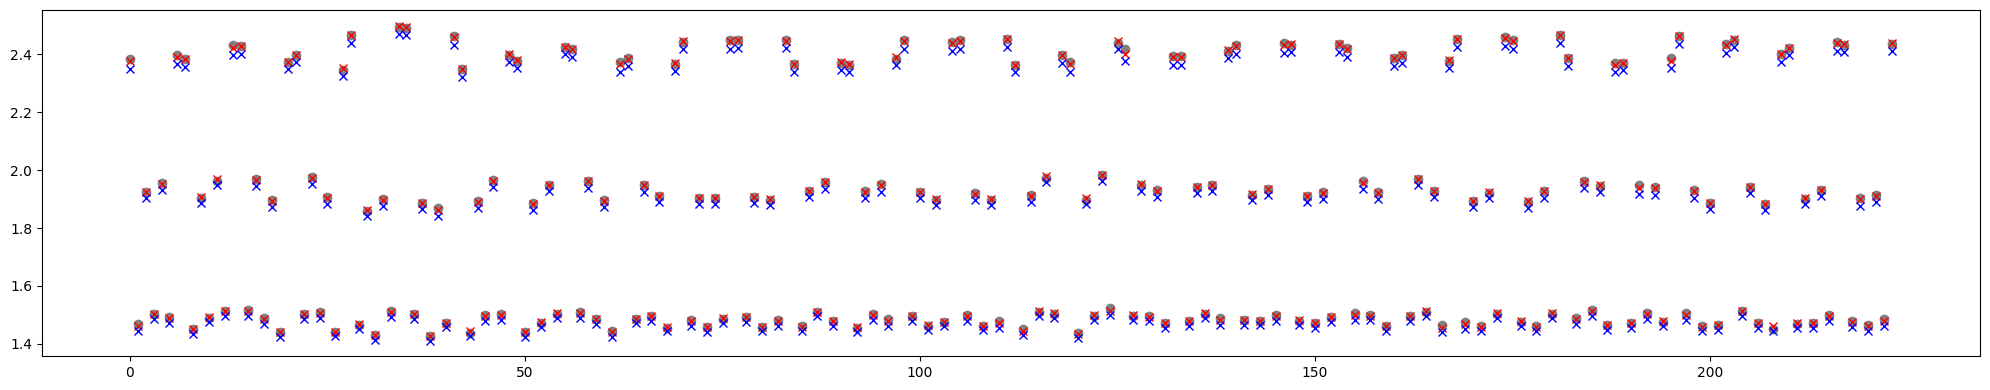

In [73]:
# n33 (bpm)

n33_estimate = ayy_bpm/(2*iy_fit).sqrt()

print(root_mean_square(n33 - n33_estimate))
print(root_mean_square(n33_bpm - n33_estimate))
print()

# n33 (beam)

n33_estimate = n33_estimate/gyy_fit

print(root_mean_square(n33 - value_n33))
print(root_mean_square(n33 - n33_estimate))
print(root_mean_square(n33_bpm - n33_estimate))
print()

plt.figure(figsize=(20, 4))
plt.errorbar(range(model.monitor_count), n33.cpu().numpy(), fmt=' ', marker='o', color='gray')
plt.errorbar(range(model.monitor_count), value_n33.cpu().numpy(), fmt=' ', marker='x', color='red')
plt.errorbar(range(model.monitor_count), n33_estimate.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

In [74]:
# Elemets n11 and n33 in bpm frame can be accuratly estimated using amplitudes and invariants
# This requires iid calibrations

# In beam frame these elements can be estimated using phase, estimated scales or from scaled fit
# Using estimated scales and scaled fit seems to be more accurate
# Note, scales can be reestimated using scaled fit

In [75]:
# Off-plane beta functions

# axy**2 = 2 * iy * (n13**2 + n14**2)
# ayx**2 = 2 * ix * (n31**2 + n32**2)

tensor(0.0224, dtype=torch.float64)
tensor(0.0002, dtype=torch.float64)

tensor(0.0167, dtype=torch.float64)
tensor(0.0054, dtype=torch.float64)
tensor(0.0227, dtype=torch.float64)



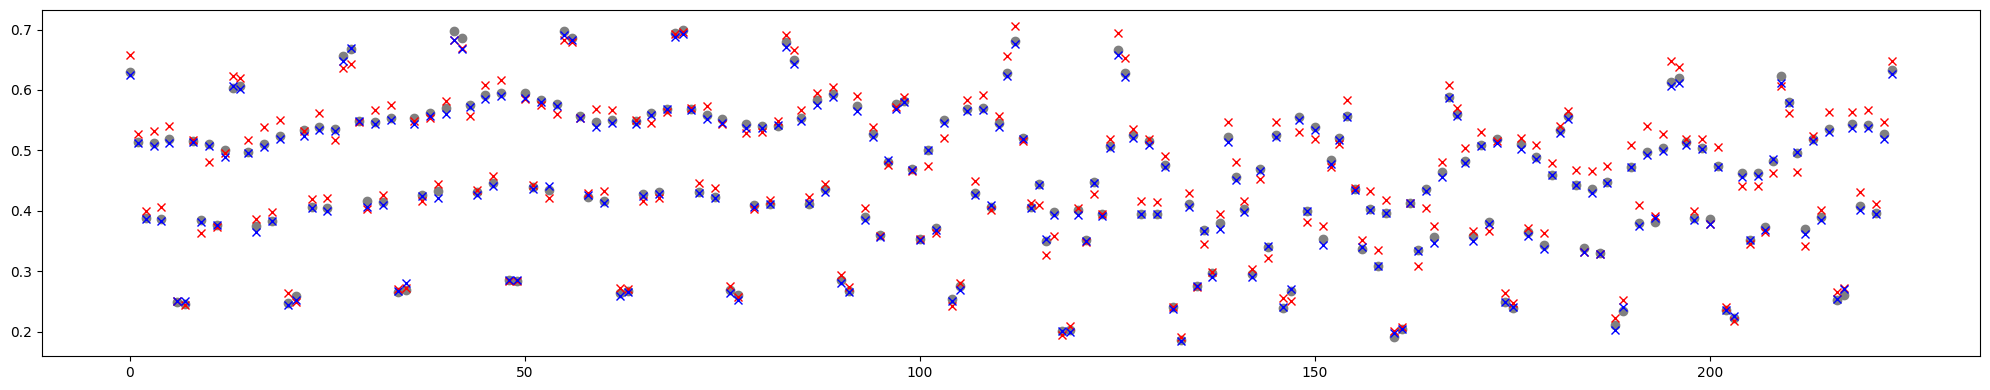

In [76]:
# beta_xy = (n13**2 + n14**2).sqrt() (bpm)

beta_xy = axy_bpm/(2*iy_fit).sqrt()

print(root_mean_square((n13**2 + n14**2).sqrt() - beta_xy))
print(root_mean_square((n13_bpm**2 + n14_bpm**2).sqrt() - beta_xy))
print()

# beta_xy (beam)

beta_xy = beta_xy/gxx_fit

print(root_mean_square((n13**2 + n14**2).sqrt() - (value_n13**2 + value_n14**2).sqrt()))
print(root_mean_square((n13**2 + n14**2).sqrt() - beta_xy))
print(root_mean_square((n13_bpm**2 + n14_bpm**2).sqrt() - beta_xy))
print()

plt.figure(figsize=(20, 4))
plt.errorbar(range(model.monitor_count), (n13**2 + n14**2).sqrt().cpu().numpy(), fmt=' ', marker='o', color='grey')
plt.errorbar(range(model.monitor_count), (value_n13**2 + value_n14**2).sqrt().cpu().numpy(), fmt=' ', marker='x', color='red')
plt.errorbar(range(model.monitor_count), beta_xy.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

tensor(0.0163, dtype=torch.float64)
tensor(0.0002, dtype=torch.float64)

tensor(0.0117, dtype=torch.float64)
tensor(0.0064, dtype=torch.float64)
tensor(0.0156, dtype=torch.float64)



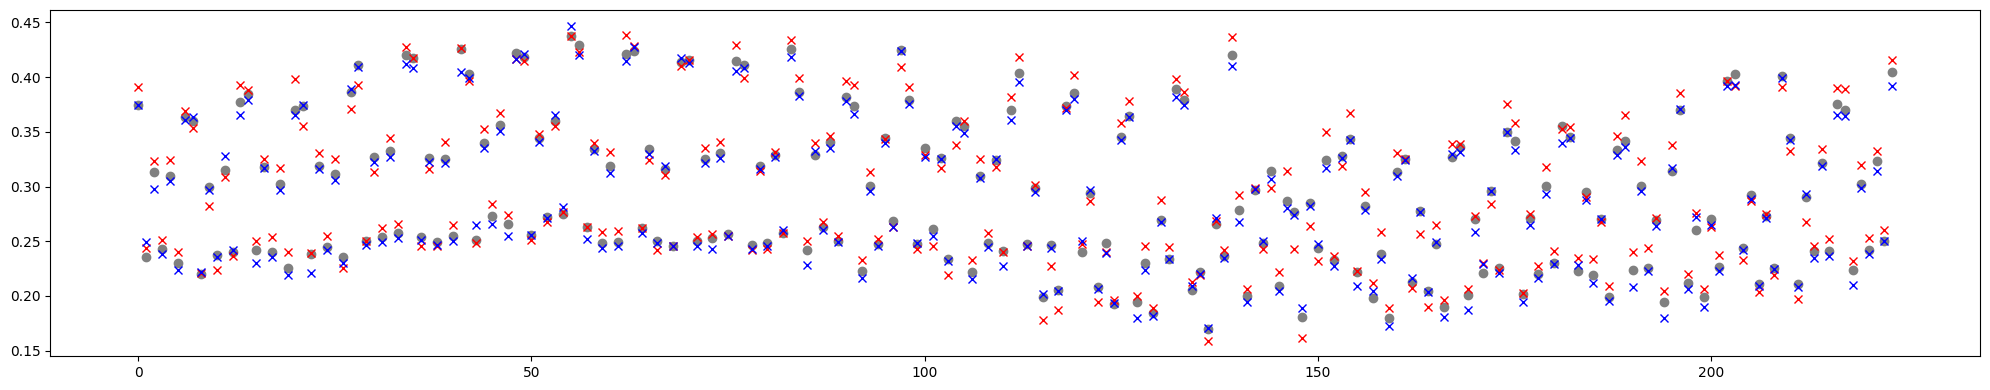

In [77]:
# beta_yx = (n31**2 + n32**2).sqrt() (bpm)

beta_yx = ayx_bpm/(2*ix_fit).sqrt()

print(root_mean_square((n31**2 + n32**2).sqrt() - beta_yx))
print(root_mean_square((n31_bpm**2 + n32_bpm**2).sqrt() - beta_yx))
print()

# beta_yx (beam)

beta_yx = beta_yx/gyy_fit

print(root_mean_square((n31**2 + n32**2).sqrt() - (value_n31**2 + value_n32**2).sqrt()))
print(root_mean_square((n31**2 + n32**2).sqrt() - beta_yx))
print(root_mean_square((n31_bpm**2 + n32_bpm**2).sqrt() - beta_yx))
print()

plt.figure(figsize=(20, 4))
plt.errorbar(range(model.monitor_count), (n31**2 + n32**2).sqrt().cpu().numpy(), fmt=' ', marker='o', color='grey')
plt.errorbar(range(model.monitor_count), (value_n31**2 + value_n32**2).sqrt().cpu().numpy(), fmt=' ', marker='x', color='red')
plt.errorbar(range(model.monitor_count), beta_yx.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

tensor(0.0155, dtype=torch.float64)
tensor(0.0001, dtype=torch.float64)

tensor(0.0151, dtype=torch.float64)
tensor(0.0057, dtype=torch.float64)
tensor(0.0154, dtype=torch.float64)



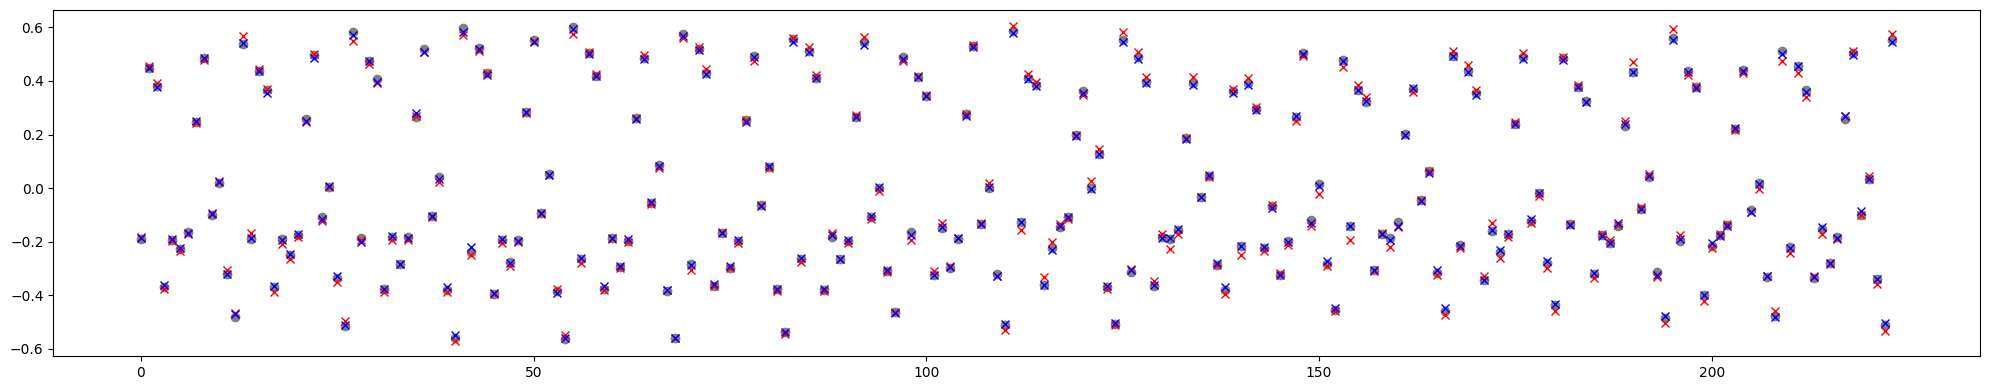

In [78]:
# n13 (bpm)

n13_estimate = axy_bpm/ayy_bpm*(fxy_bpm - fyy_bpm).cos()*(ayy_bpm/(2*iy_fit).sqrt())

print(root_mean_square(n13 - n13_estimate))
print(root_mean_square(n13_bpm - n13_estimate))
print()

# n13 (beam)

n13_estimate = n13_estimate/gxx_fit

print(root_mean_square(n13 - value_n13))
print(root_mean_square(n13 - n13_estimate))
print(root_mean_square(n13_bpm - n13_estimate))
print()

plt.figure(figsize=(20, 4))
plt.errorbar(range(model.monitor_count), n13.cpu().numpy(), fmt=' ', marker='o', color='gray')
plt.errorbar(range(model.monitor_count), value_n13.cpu().numpy(), fmt=' ', marker='x', color='red')
plt.errorbar(range(model.monitor_count), n13_estimate.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

tensor(0.0164, dtype=torch.float64)
tensor(0.0001, dtype=torch.float64)

tensor(0.0195, dtype=torch.float64)
tensor(0.0028, dtype=torch.float64)
tensor(0.0167, dtype=torch.float64)



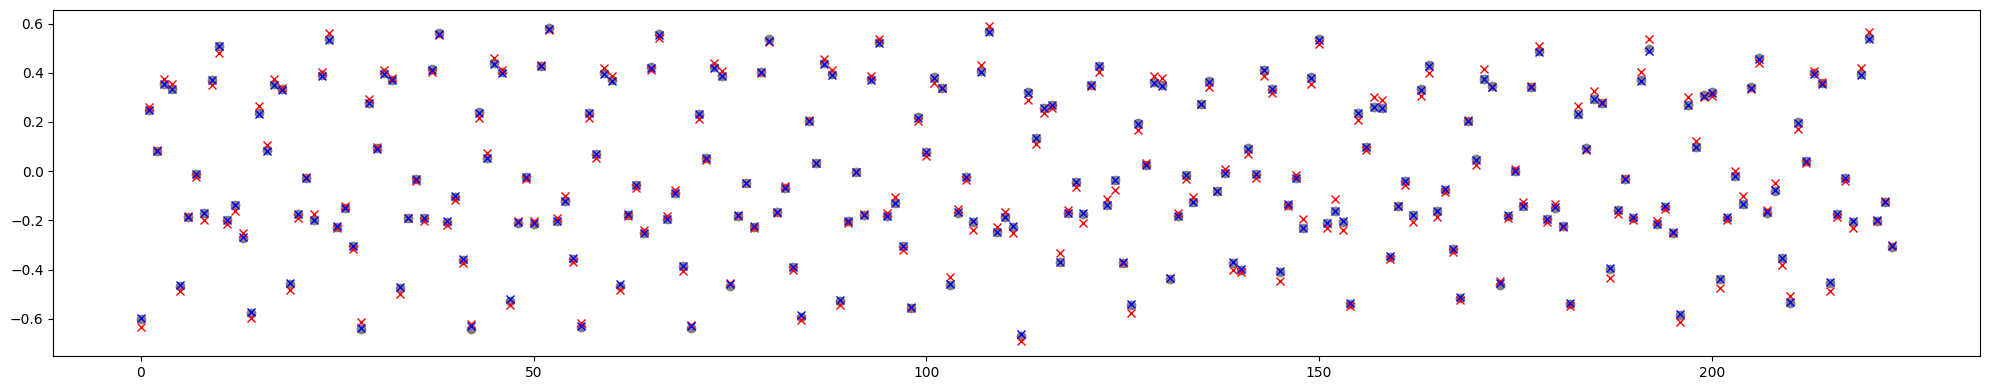

In [79]:
# n14 (bpm)

n14_estimate = axy_bpm/ayy_bpm*(fxy_bpm - fyy_bpm).sin()*(ayy_bpm/(2*iy_fit).sqrt())

print(root_mean_square(n14 - n14_estimate))
print(root_mean_square(n14_bpm - n14_estimate))
print()

# n14 (beam)

n14_estimate = n14_estimate/gxx_fit

print(root_mean_square(n14 - value_n14))
print(root_mean_square(n14 - n14_estimate))
print(root_mean_square(n14_bpm - n14_estimate))
print()

plt.figure(figsize=(20, 4))
plt.errorbar(range(model.monitor_count), n14.cpu().numpy(), fmt=' ', marker='o', color='gray')
plt.errorbar(range(model.monitor_count), value_n14.cpu().numpy(), fmt=' ', marker='x', color='red')
plt.errorbar(range(model.monitor_count), n14_estimate.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

tensor(0.0138, dtype=torch.float64)
tensor(0.0001, dtype=torch.float64)

tensor(0.0117, dtype=torch.float64)
tensor(0.0082, dtype=torch.float64)
tensor(0.0115, dtype=torch.float64)



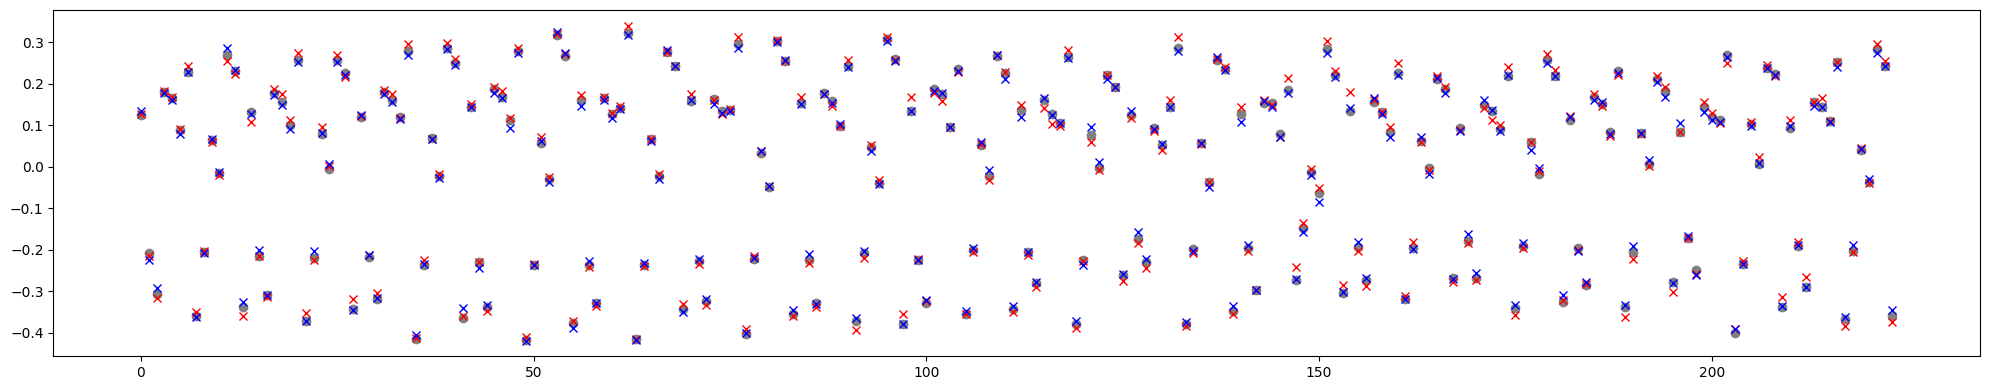

In [80]:
# n31 (bpm)

n31_estimate = ayx_bpm/axx_bpm*(fyx_bpm - fxx_bpm).cos()*(axx_bpm/(2*ix_fit).sqrt())

print(root_mean_square(n31 - n31_estimate))
print(root_mean_square(n31_bpm - n31_estimate))
print()

# n31 (beam)

n31_estimate = n31_estimate/gyy_fit

print(root_mean_square(n31 - value_n31))
print(root_mean_square(n31 - n31_estimate))
print(root_mean_square(n31_bpm - n31_estimate))
print()

plt.figure(figsize=(20, 4))
plt.errorbar(range(model.monitor_count), n31.cpu().numpy(), fmt=' ', marker='o', color='gray')
plt.errorbar(range(model.monitor_count), value_n31.cpu().numpy(), fmt=' ', marker='x', color='red')
plt.errorbar(range(model.monitor_count), n31_estimate.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

tensor(0.0103, dtype=torch.float64)
tensor(0.0001, dtype=torch.float64)

tensor(0.0123, dtype=torch.float64)
tensor(0.0022, dtype=torch.float64)
tensor(0.0106, dtype=torch.float64)



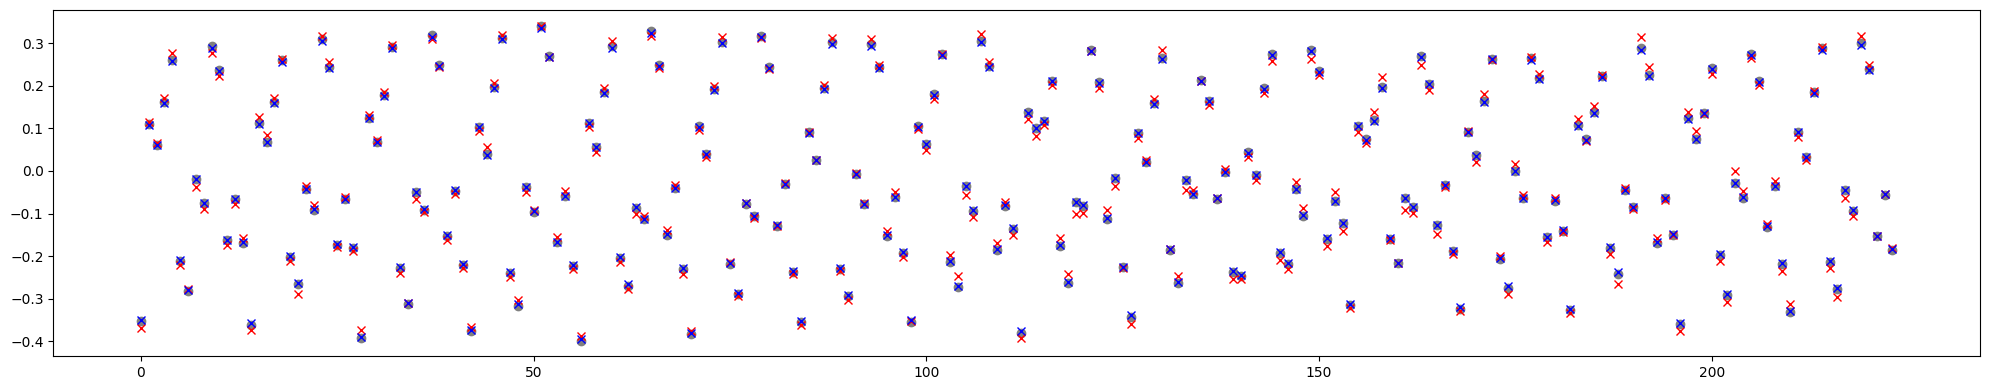

In [81]:
# n32 (bpm)

n32_estimate = ayx_bpm/axx_bpm*(fyx_bpm - fxx_bpm).sin()*(axx_bpm/(2*ix_fit).sqrt())

print(root_mean_square(n32 - n32_estimate))
print(root_mean_square(n32_bpm - n32_estimate))
print()

# n32 (beam)

n32_estimate = n32_estimate/gyy_fit

print(root_mean_square(n32 - value_n32))
print(root_mean_square(n32 - n32_estimate))
print(root_mean_square(n32_bpm - n32_estimate))
print()

plt.figure(figsize=(20, 4))
plt.errorbar(range(model.monitor_count), n32.cpu().numpy(), fmt=' ', marker='o', color='gray')
plt.errorbar(range(model.monitor_count), value_n32.cpu().numpy(), fmt=' ', marker='x', color='red')
plt.errorbar(range(model.monitor_count), n32_estimate.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

In [82]:
# Summary
# -- gxx and gyy from ratio can be used in rescaled fit (can be iteratively recompute)
# -- n11, n33, n13, n14, n31 and n32 can be estimated with good accuracy in bpm frame
# -- n11 and n33 from scaled fit are good approximations of beam frame parameters
# -- n11, n33, n14 and n32 in beam can be approximated with good accuracy using corresponding bpm frame pareameters and estiated scales

## Transport matrix elements

In [83]:
# Given more accurate estimations of a subset of normalizaton matrix elements
# It is possible to compute m12, m14, m31 and m34 from these elements and measured phase advances
# Note, these elements 'weight' contribution of coordinates into coordinates

# m12 = muxij.sin()*ni11*nj11+muyij.cos()*(-ni14*nj13+ni13*nj14)+muyij.sin()*(ni13*nj13+ni14*nj14)
# m14 = muxij.sin()*ni31*nj11-muxij.cos()*ni32*nj11+muyij.sin()*ni33*nj13+muyij.cos()*ni33*nj14
# m32 = muxij.sin()*ni11*nj31+muxij.cos()*ni11*nj32+muyij.sin()*ni13*nj33-muyij.cos()*ni14*nj33
# m34 = muxij.cos()*(-ni32*nj31+ni31*nj32)+muxij.sin()*(ni31*nj31+ni32*nj32)+muyij.sin()*ni33*nj33

# Here, these elements are computed using 'improved' procedure and fit
# Results are compared with exact values

In [84]:
# Compute exact transport matrices

normal = model.out_normal[model.monitor_index]
advance_bpm, normal_bpm = torch.vmap(advance)(normal, bpm)
matrix = normal.roll(-1, 0) @ torch.vmap(rotation)(mux, muy) @ normal.inverse()

In [85]:
# Compute estimated transport matrix elements

def compute(muxij, muyij, ni11, ni33, ni13, ni14, ni31, ni32, nj11, nj33, nj13, nj14, nj31, nj32):
    m12 = muxij.sin()*ni11*nj11+muyij.cos()*(-ni14*nj13+ni13*nj14)+muyij.sin()*(ni13*nj13+ni14*nj14)
    m14 = muxij.sin()*ni31*nj11-muxij.cos()*ni32*nj11+muyij.sin()*ni33*nj13+muyij.cos()*ni33*nj14
    m32 = muxij.sin()*ni11*nj31+muxij.cos()*ni11*nj32+muyij.sin()*ni13*nj33-muyij.cos()*ni14*nj33
    m34 = muxij.cos()*(-ni32*nj31+ni31*nj32)+muxij.sin()*(ni31*nj31+ni32*nj32)+muyij.sin()*ni33*nj33 
    return torch.stack([m12, m14, m32, m34])

muxij = table_bpm.phase_x
muyij = table_bpm.phase_y

# Fit (rescaled)

m12_fit, m14_fit, m32_fit, m34_fit = torch.vmap(compute)(table_bpm.phase_x, table_bpm.phase_y, value_n11, value_n33, value_n13, value_n14, value_n31, value_n32, value_n11.roll(-1), value_n33.roll(-1), value_n13.roll(-1), value_n14.roll(-1), value_n31.roll(-1), value_n32.roll(-1)).T

# Improved estimate

m12_estimate, m14_estimate, m32_estimate, m34_estimate = torch.vmap(compute)(table_bpm.phase_x, table_bpm.phase_y, n11_estimate, n33_estimate, n13_estimate, n14_estimate, n31_estimate, n32_estimate, n11_estimate.roll(-1), n33_estimate.roll(-1), n13_estimate.roll(-1), n14_estimate.roll(-1), n31_estimate.roll(-1), n32_estimate.roll(-1)).T

tensor(0.0138, dtype=torch.float64)
tensor(0.0440, dtype=torch.float64)



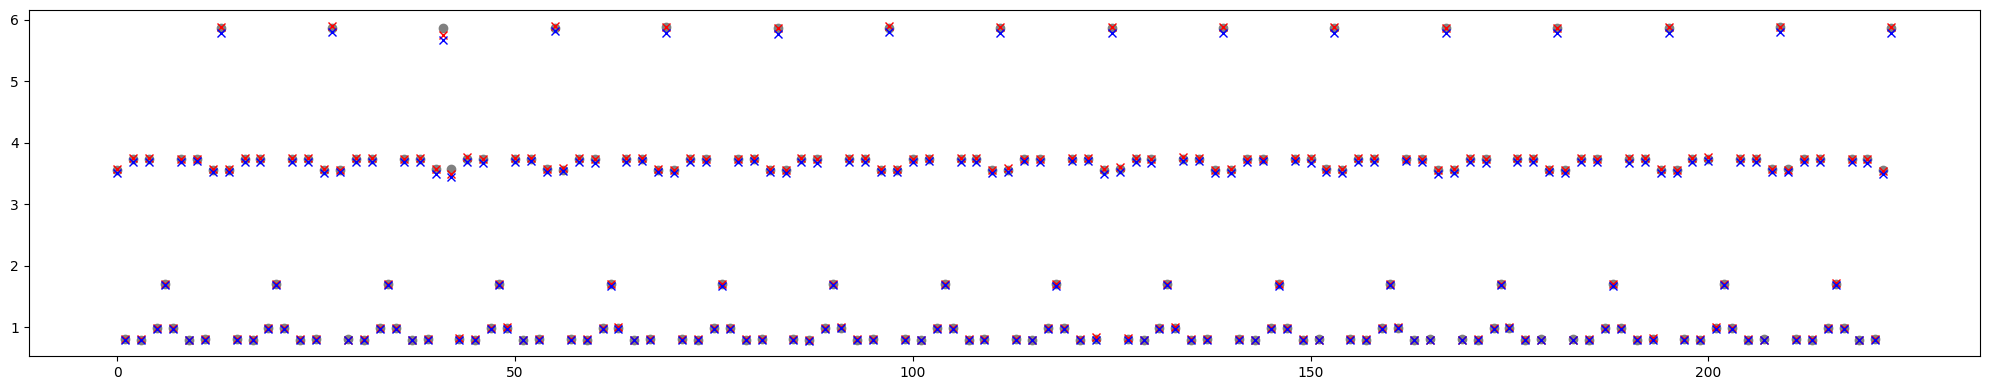

In [86]:
# m12

print(root_mean_square(matrix[:, 0, 1] - m12_fit))
print(root_mean_square(matrix[:, 0, 1] - m12_estimate))
print()

plt.figure(figsize=(20, 4))
plt.errorbar(range(model.monitor_count), matrix[:, 0, 1].cpu().numpy(), fmt=' ', marker='o', color='gray')
plt.errorbar(range(model.monitor_count), m12_fit.cpu().numpy(), fmt=' ', marker='x', color='red')
plt.errorbar(range(model.monitor_count), m12_estimate.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

tensor(0.0336, dtype=torch.float64)
tensor(0.0096, dtype=torch.float64)



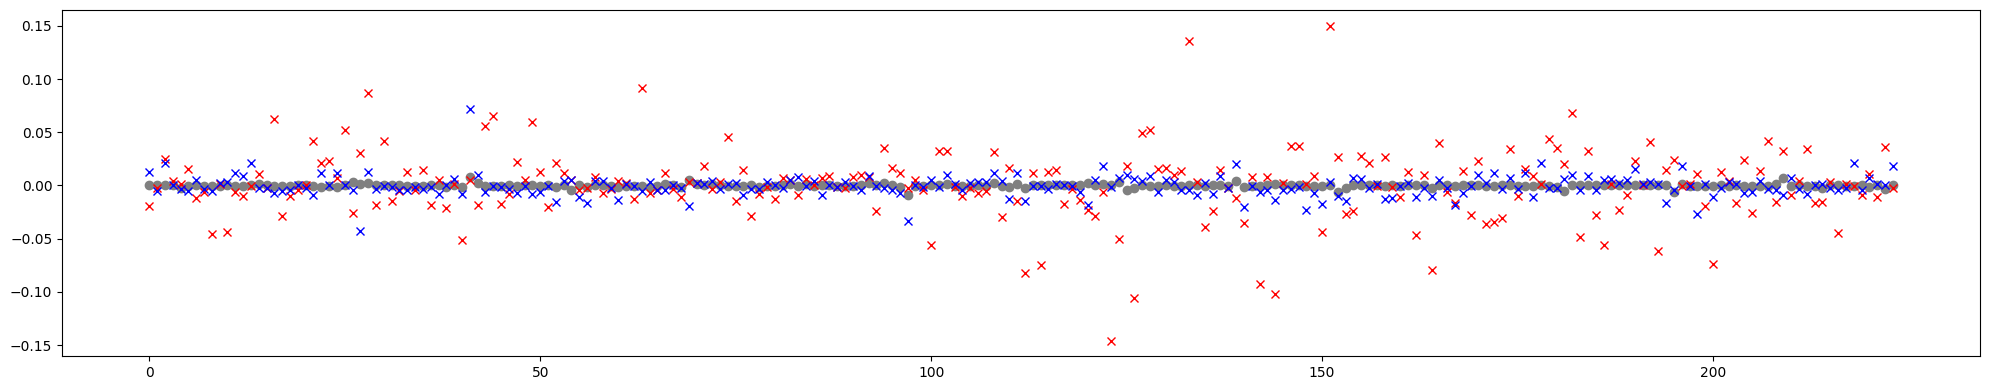

In [87]:
# m14

print(root_mean_square(matrix[:, 0, 3] - m14_fit))
print(root_mean_square(matrix[:, 0, 3] - m14_estimate))
print()

plt.figure(figsize=(20, 4))
plt.errorbar(range(model.monitor_count), matrix[:, 0, 3].cpu().numpy(), fmt=' ', marker='o', color='gray')
plt.errorbar(range(model.monitor_count), m14_fit.cpu().numpy(), fmt=' ', marker='x', color='red')
plt.errorbar(range(model.monitor_count), m14_estimate.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

tensor(0.0319, dtype=torch.float64)
tensor(0.0092, dtype=torch.float64)



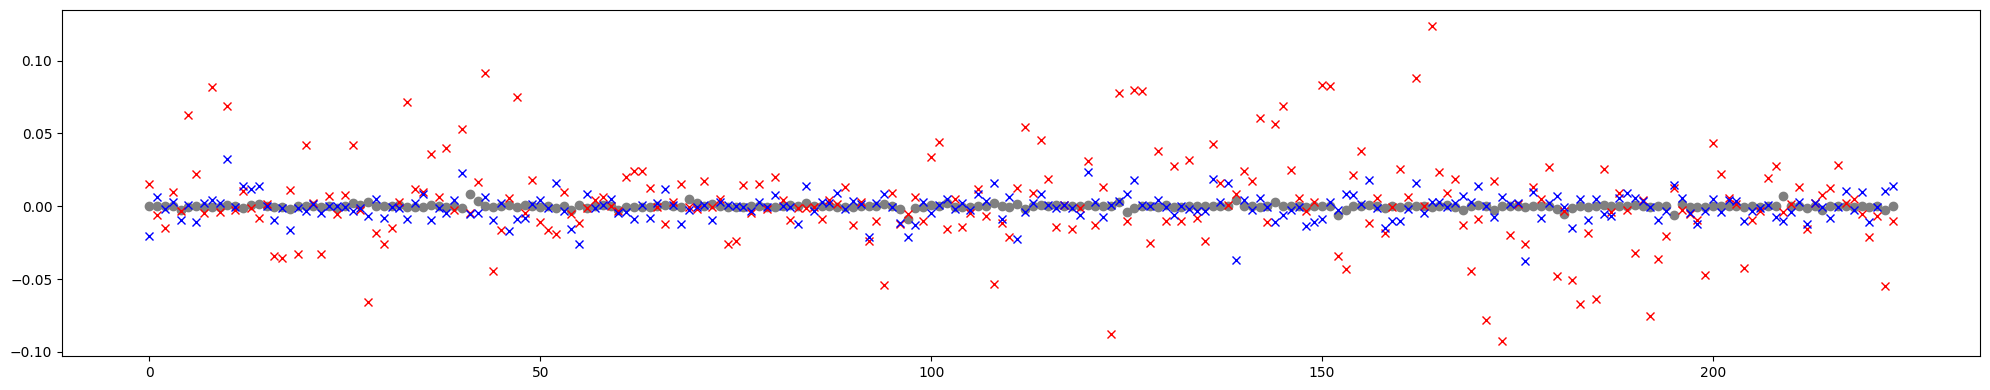

In [88]:
# m32

print(root_mean_square(matrix[:, 2, 1] - m32_fit))
print(root_mean_square(matrix[:, 2, 1] - m32_estimate))
print()

plt.figure(figsize=(20, 4))
plt.errorbar(range(model.monitor_count), matrix[:, 2, 1].cpu().numpy(), fmt=' ', marker='o', color='gray')
plt.errorbar(range(model.monitor_count), m32_fit.cpu().numpy(), fmt=' ', marker='x', color='red')
plt.errorbar(range(model.monitor_count), m32_estimate.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

tensor(0.0046, dtype=torch.float64)
tensor(0.0472, dtype=torch.float64)



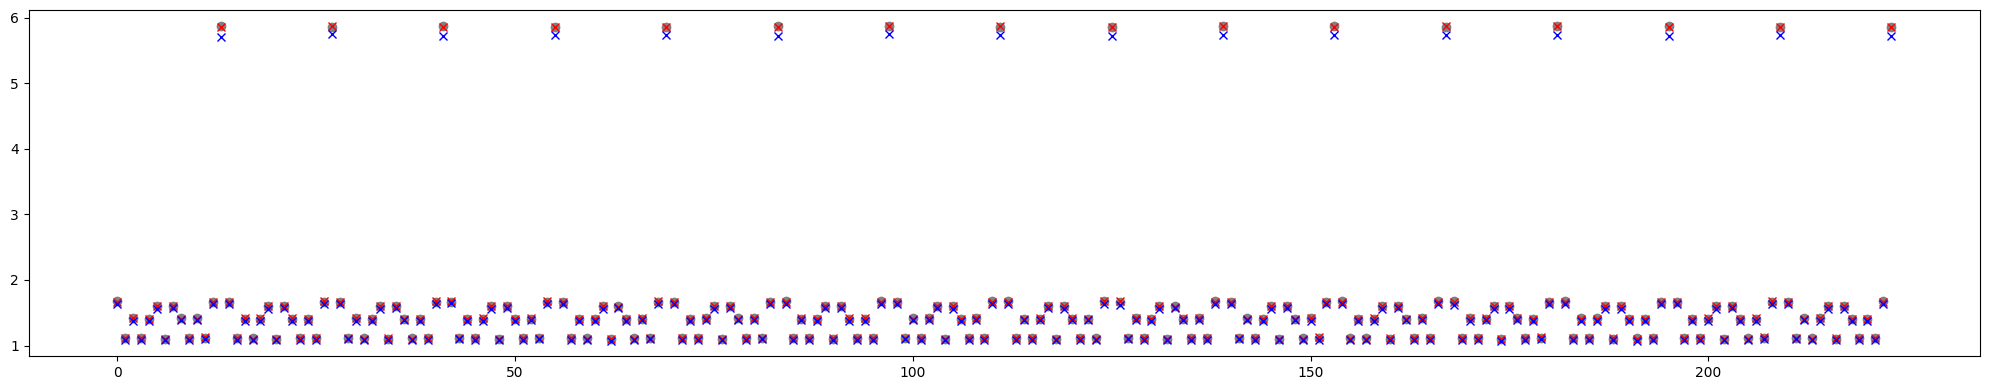

In [89]:
# m34

print(root_mean_square(matrix[:, 2, 3] - m34_fit))
print(root_mean_square(matrix[:, 2, 3] - m34_estimate))
print()

plt.figure(figsize=(20, 4))
plt.errorbar(range(model.monitor_count), matrix[:, 2, 3].cpu().numpy(), fmt=' ', marker='o', color='gray')
plt.errorbar(range(model.monitor_count), m34_fit.cpu().numpy(), fmt=' ', marker='x', color='red')
plt.errorbar(range(model.monitor_count), m34_estimate.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

## Refit

In [90]:
# Rescale TbT using estimated gxx and gyy from ratio

twiss.table.x = qx_bpm/gxx_fit.reshape(-1, 1)
twiss.table.y = qy_bpm/gyy_fit.reshape(-1, 1)

In [91]:
%%time

# Estimate twiss from invariant fit (fixed invariants)

count = 8

data = twiss.get_twiss_from_data(1,                # -- first turn
                                 256,              # -- total number of turns, orbits are computed for (start, start + total)
                                 parametric_normal,# -- normalization
                                 model.matrix,     # -- transport matrix generator
                                 twiss=None,       # -- initial twiss for each location or None (use model values)
                                 method='lstsq',   # -- momenta computation method
                                 limit=2,          # -- range limit or direction/shift
                                 product=True,     # -- flag to use product objective
                                 jacobian=False,   # -- flag to use objective jacobian
                                 count=count,      # -- number of samples
                                 fraction=0.75,    # -- sample length fraction
                                 ix=ix_out.mean(), # -- ix invariant value
                                 iy=iy_out.mean(), # -- iy invariant value  (both should present for fixed fit)
                                 n_jobs=4,         # -- number of parallel jobs (loop over samples)
                                 verbose=False)    # -- verbose flag

CPU times: user 8min 38s, sys: 1min 24s, total: 10min 2s
Wall time: 12min


In [92]:
# Process twiss

value_n11 = data[:, 0, 0]
error_n11 = data[:, 1, 0]

value_n33 = data[:, 0, 1]
error_n33 = data[:, 1, 1]

value_n21 = data[:, 0, 2]
error_n21 = data[:, 1, 2]

value_n43 = data[:, 0, 3]
error_n43 = data[:, 1, 3]

value_n13 = data[:, 0, 4]
error_n13 = data[:, 1, 4]

value_n31 = data[:, 0, 5]
error_n31 = data[:, 1, 5]

value_n14 = data[:, 0, 6]
error_n14 = data[:, 1, 6]

value_n41 = data[:, 0, 7]
error_n41 = data[:, 1, 7]

value_n11, error_n11 = twiss.process(value_n11, error_n11)
value_n33, error_n33 = twiss.process(value_n33, error_n33)
value_n21, error_n21 = twiss.process(value_n21, error_n21)
value_n43, error_n43 = twiss.process(value_n43, error_n43)
value_n13, error_n13 = twiss.process(value_n13, error_n13)
value_n31, error_n31 = twiss.process(value_n31, error_n31)
value_n14, error_n14 = twiss.process(value_n14, error_n14)
value_n41, error_n41 = twiss.process(value_n41, error_n41)

value = torch.stack([value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41]).T
error = torch.stack([error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41]).T

cs_value, cs_error = [], []

for value_loc, error_loc in zip(value, error):
    table = value_loc.reshape(-1, 1) + error_loc.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax, value_bx, value_ay, value_by = cs_value.T
error_ax, error_bx, error_ay, error_by = cs_error.T

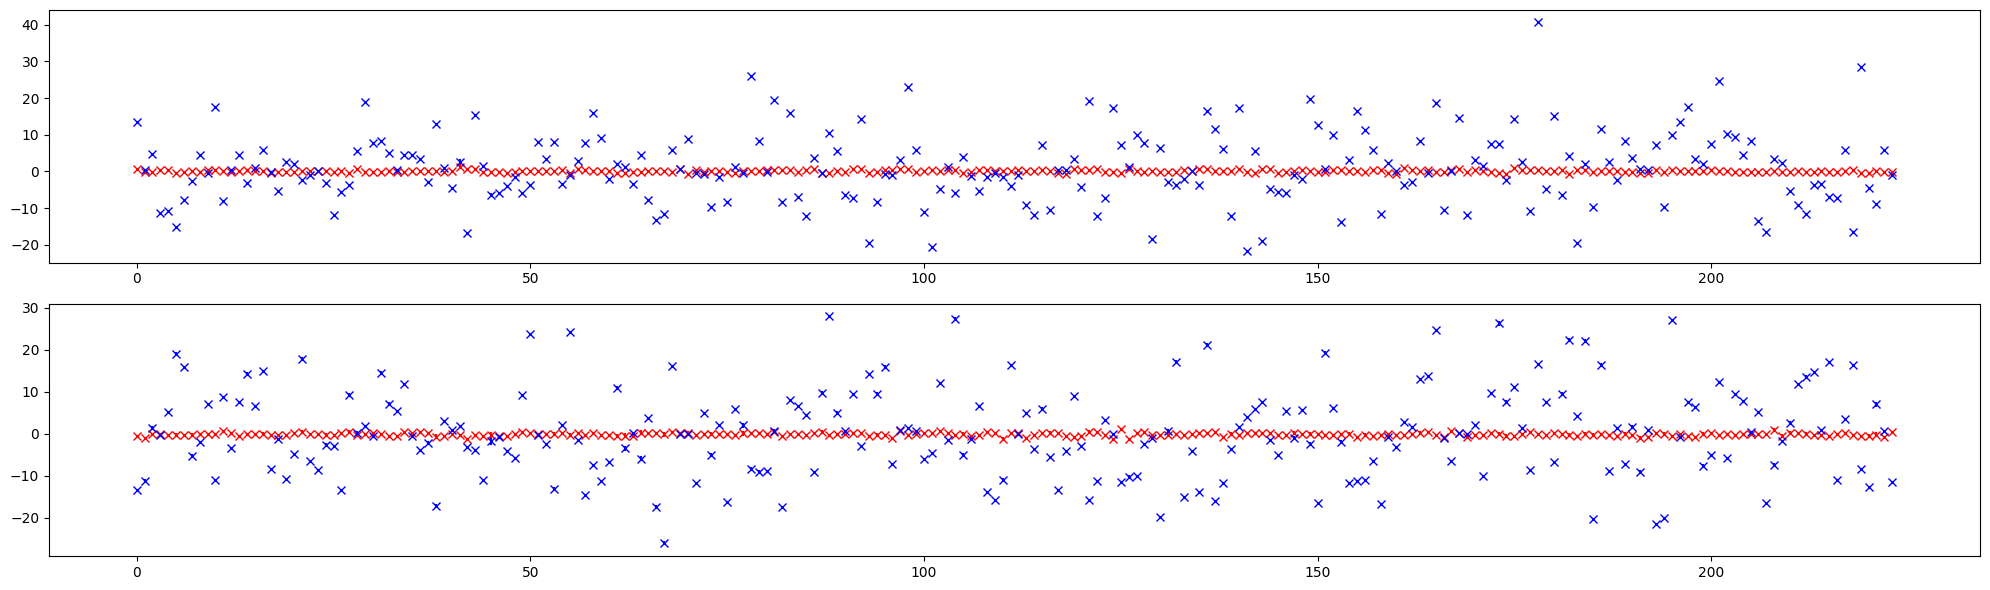

tensor(0.3428, dtype=torch.float64)
tensor(0.4058, dtype=torch.float64)

tensor(9.6876, dtype=torch.float64)
tensor(10.5677, dtype=torch.float64)



In [93]:
# Compare beta function values

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((value_bx - bx)/bx).cpu().numpy(), yerr=100/bx*error_bx.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((value_bx - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*error_bx.cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((value_by - by)/by).cpu().numpy(), yerr=100/by*error_by.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((value_by - by_bpm)/by_bpm).cpu().numpy(), yerr=100/by_bpm*error_by.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((value_bx - bx)/bx)))
print(root_mean_square(100*((value_by - by)/by)))
print()

print(root_mean_square(100*((value_bx - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((value_by - by_bpm)/by_bpm)))
print()

tensor(0.0054, dtype=torch.float64)
tensor(0.1460, dtype=torch.float64)

tensor(0.0038, dtype=torch.float64)
tensor(0.0990, dtype=torch.float64)

tensor(0.0024, dtype=torch.float64)
tensor(0.0676, dtype=torch.float64)

tensor(0.0035, dtype=torch.float64)
tensor(0.0495, dtype=torch.float64)

tensor(0.0124, dtype=torch.float64)
tensor(0.0196, dtype=torch.float64)

tensor(0.0105, dtype=torch.float64)
tensor(0.0183, dtype=torch.float64)

tensor(0.0170, dtype=torch.float64)
tensor(0.0230, dtype=torch.float64)

tensor(0.0060, dtype=torch.float64)
tensor(0.0106, dtype=torch.float64)



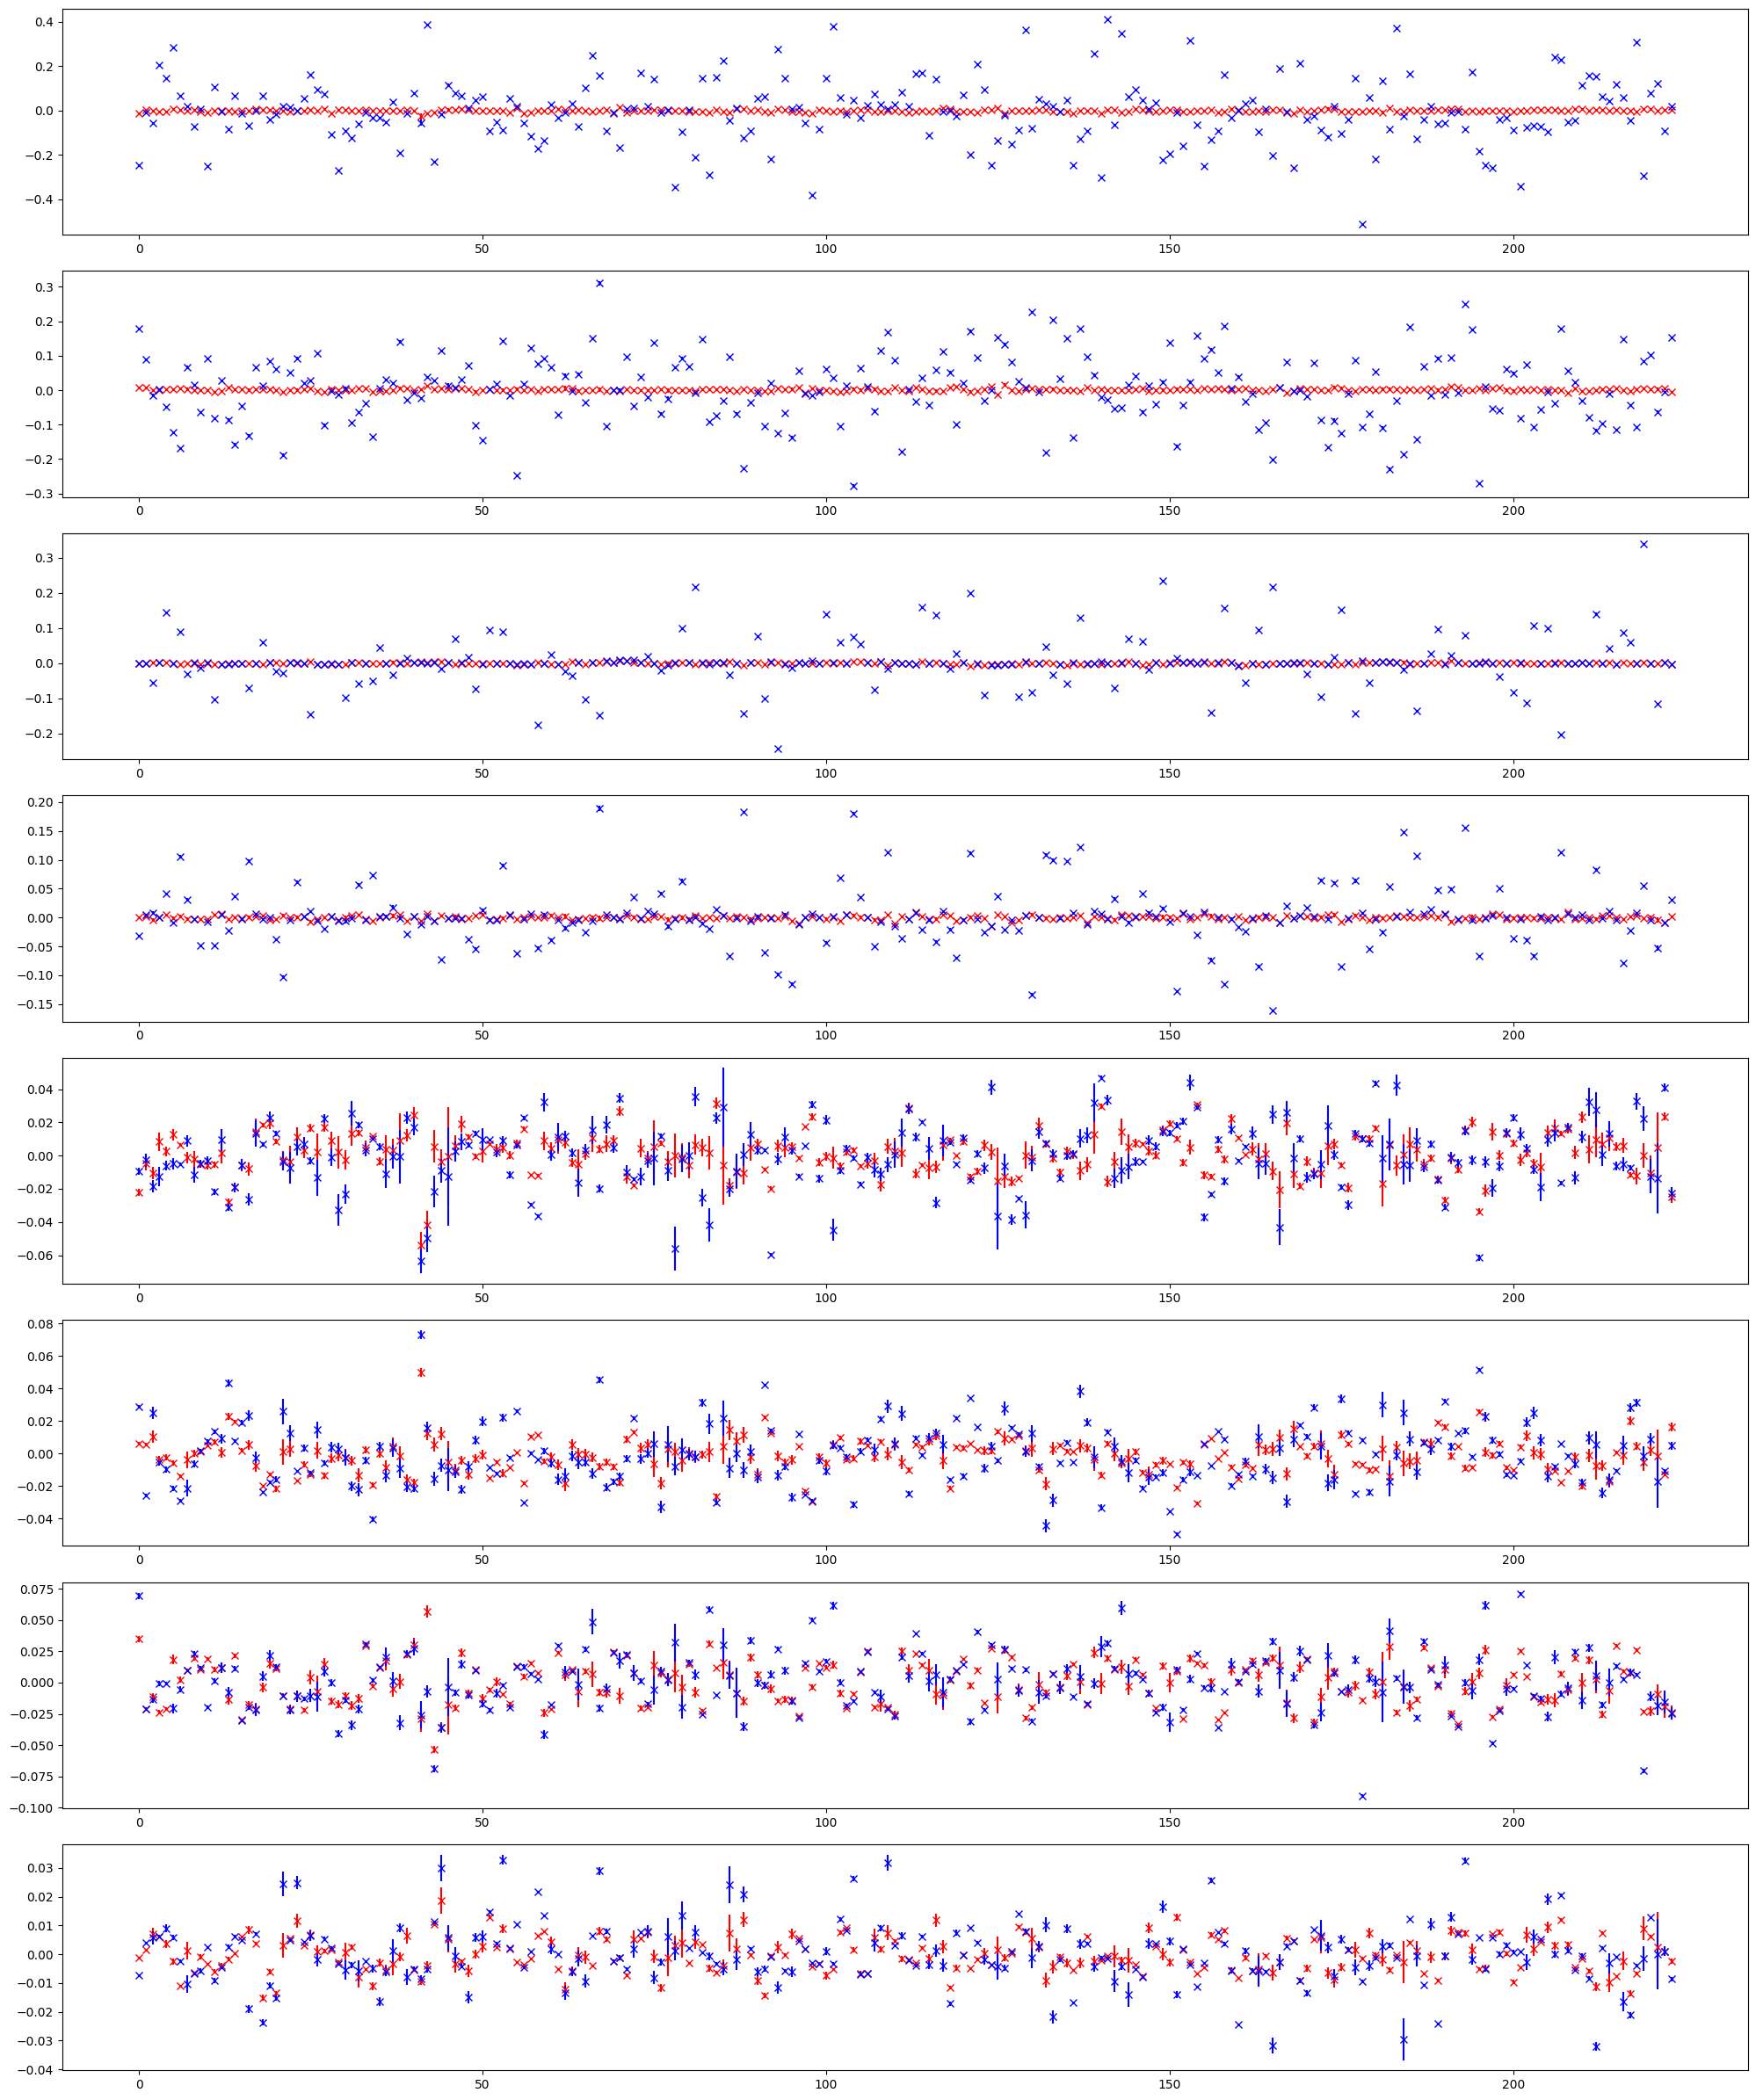

In [94]:
# Compare estimated normalization matrix elements

plt.figure(figsize=(20, 3*8))

ax = plt.subplot(811)
ax.errorbar(range(model.monitor_count), (n11 - value_n11).cpu().numpy(), yerr=error_n11.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n11_bpm - value_n11).cpu().numpy(), yerr=error_n11.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n11 - value_n11))
print(root_mean_square(n11_bpm - value_n11))
print()

ax = plt.subplot(812)
ax.errorbar(range(model.monitor_count), (n33 - value_n33).cpu().numpy(), yerr=error_n33.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n33_bpm - value_n33).cpu().numpy(), yerr=error_n33.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n33 - value_n33))
print(root_mean_square(n33_bpm - value_n33))
print()

ax = plt.subplot(813)
ax.errorbar(range(model.monitor_count), (n21 - value_n21).cpu().numpy(), yerr=error_n21.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n21_bpm - value_n21).cpu().numpy(), yerr=error_n21.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n21 - value_n21))
print(root_mean_square(n21_bpm - value_n21))
print()

ax = plt.subplot(814)
ax.errorbar(range(model.monitor_count), (n43 - value_n43).cpu().numpy(), yerr=error_n43.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n43_bpm - value_n43).cpu().numpy(), yerr=error_n43.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n43 - value_n43))
print(root_mean_square(n43_bpm - value_n43))
print()

ax = plt.subplot(815)
ax.errorbar(range(model.monitor_count), (n13 - value_n13).cpu().numpy(), yerr=error_n13.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n13_bpm - value_n13).cpu().numpy(), yerr=error_n13.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n13 - value_n13))
print(root_mean_square(n13_bpm - value_n13))
print()

ax = plt.subplot(816)
ax.errorbar(range(model.monitor_count), (n31 - value_n31).cpu().numpy(), yerr=error_n31.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n31_bpm - value_n31).cpu().numpy(), yerr=error_n31.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n31 - value_n31))
print(root_mean_square(n31_bpm - value_n31))
print()

ax = plt.subplot(817)
ax.errorbar(range(model.monitor_count), (n14 - value_n14).cpu().numpy(), yerr=error_n14.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n14_bpm - value_n14).cpu().numpy(), yerr=error_n14.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n14 - value_n14))
print(root_mean_square(n14_bpm - value_n14))
print()

ax = plt.subplot(818)
ax.errorbar(range(model.monitor_count), (n41 - value_n41).cpu().numpy(), yerr=error_n41.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n41_bpm - value_n41).cpu().numpy(), yerr=error_n41.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n41 - value_n41))
print(root_mean_square(n41_bpm - value_n41))
print()

plt.tight_layout()
plt.show()

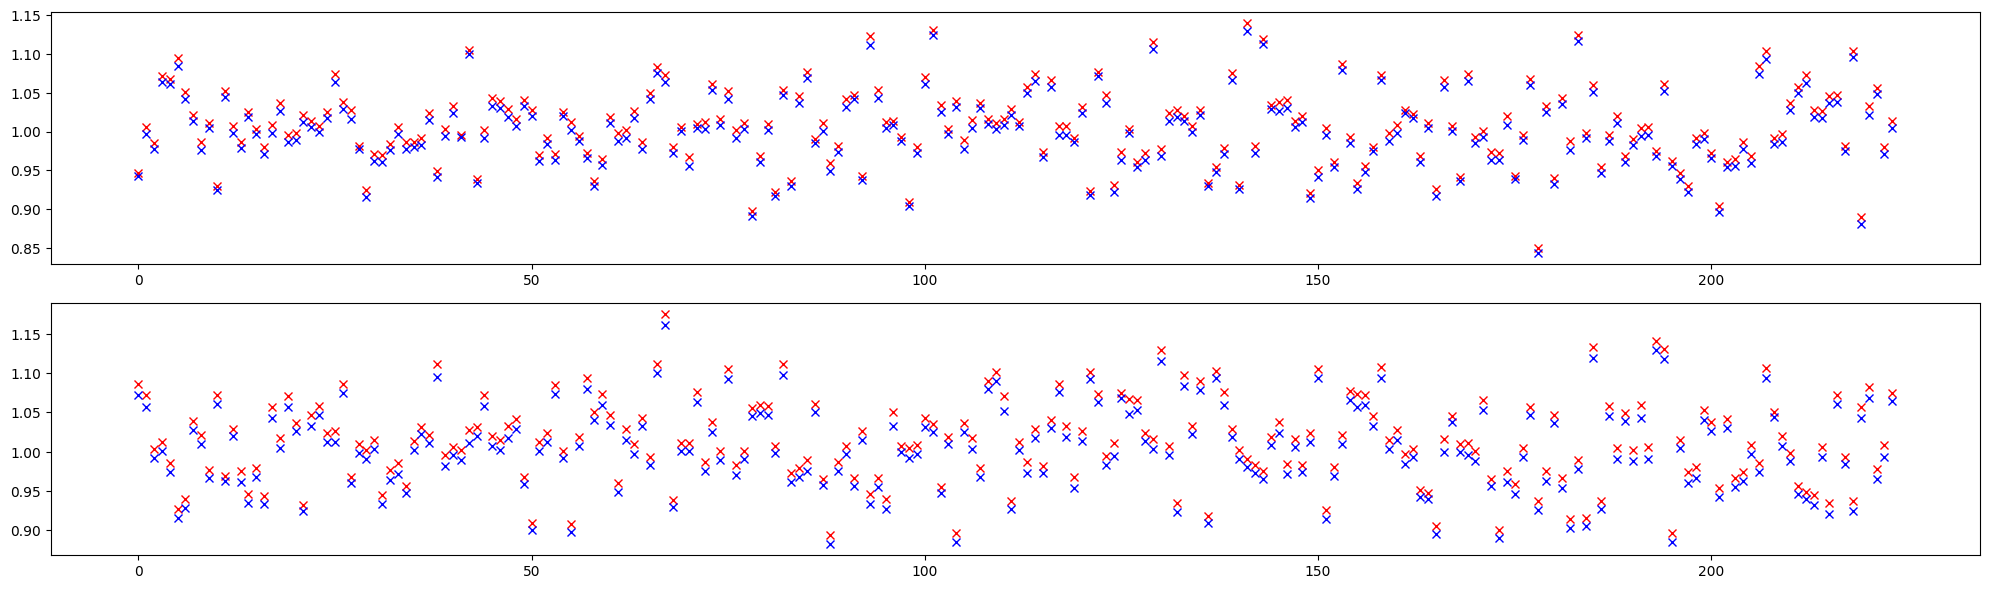

tensor(0.8171, dtype=torch.float64)
tensor(1.1854, dtype=torch.float64)



In [95]:
# Ratio (fitted invariants & twiss from scaled TbT)

twiss = Twiss(model, table_bpm, limit=4)

twiss.phase_virtual()
twiss.get_twiss_from_phase()
mask_x = twiss.filter_twiss(plane='x', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
mask_y = twiss.filter_twiss(plane='y', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
_ = twiss.process_twiss(plane='x', mask=mask_x, weight=True)
_ = twiss.process_twiss(plane='y', mask=mask_y, weight=True)

twiss.get_action(jx=BAG_IX.mean(-1), jy=BAG_IY.mean(-1), sigma_jx=BAG_IX.std(-1), sigma_jy=BAG_IY.std(-1))
twiss.get_twiss_from_amplitude()

# Ratio

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['bx']/value_bx).sqrt().cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), g_xx.cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['by']/value_by).sqrt().cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), g_yy.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

gxx_fit = (twiss.data_amplitude['bx']/value_bx).sqrt()
gyy_fit = (twiss.data_amplitude['by']/value_by).sqrt()

print(root_mean_square(100*(((twiss.data_amplitude['bx']/value_bx).sqrt() - g_xx)/g_xx)))
print(root_mean_square(100*(((twiss.data_amplitude['by']/value_by).sqrt() - g_yy)/g_yy)))
print()